# 정밀가공 분석 실습

## 1단계. 패키지와 데이터 불러오기

**이번 목표는 엑셀 두 파일을 파이썬으로 읽고, 어떤 정보가 들어 있는지 확인하는 것입니다.**

레이저로 작은 구멍을 가공할 때 측정한 반사광 기록을 이용합니다.
`normal.xlsx`는 정상 홀 가공 기록, `anomaly.xlsx`는 이상 홀 가공 기록입니다.
한 행은 한 시점의 측정 기록입니다. 행 수가 곧 구멍 수를 뜻하지는 않습니다.

전체 순서: ① 불러오기 → ② 탐색 → ③ 전처리 → ④ 모델 구축 → ⑤ 학습 → ⑥ 경보 기준 설정 → ⑦ 평가 → ⑧ 결과 해석

이번 노트북에는 **① 불러오기**만 작성했습니다. 그래프 비교와 모델 학습은 다음 단계에서 진행합니다.
공부용·기준 조정용·최종 시험용 자료의 분할 방식은 학습과 전처리 기준을 정하기 전에 설계합니다.

### 실행 방법

설명 아래의 코드 셀을 클릭하고 **Shift + Enter**를 누르세요. 위에서 아래로 하나씩 실행합니다.
저장된 표는 실행해 확인한 결과입니다. 노트북을 새로 열었을 때는 코드를 다시 실행해야 변수도 준비됩니다.
오른쪽 위에서 Python 커널을 선택하라는 표시가 나오면 사용할 Python 환경을 선택하세요.

### 1-1. 표를 읽는 도구 준비하기

`pandas`는 엑셀처럼 생긴 표를 읽고 다루는 파이썬 도구입니다.

| 코드 | 뜻 |
|---|---|
| `import pandas as pd` | pandas를 꺼내고, 앞으로 `pd`라는 짧은 이름으로 부르기 |
| `from pathlib import Path` | 폴더와 파일 위치를 표현하는 도구 꺼내기 |

처음에는 이 두 도구면 충분합니다. 딥러닝 도구는 필요한 단계에서 추가합니다.

In [1]:
import pandas as pd
from pathlib import Path

print("표를 읽을 준비가 되었습니다.")
print("pandas 버전:", pd.__version__)

표를 읽을 준비가 되었습니다.
pandas 버전: 2.3.3


### 1-2. 엑셀 파일이 있는 위치 알려 주기

우리가 만든 폴더의 구조는 다음과 같습니다.

```text
17-laser/
    1.ipynb
    Guidebook_정밀가공 자원최적화 AI 데이터셋.pdf
    data/
        normal.xlsx
        anomaly.xlsx
```

`PROJECT_DIR`은 프로젝트 폴더, `DATA_DIR`은 엑셀 파일이 있는 폴더입니다.
`/ "data"`는 경로 뒤에 `data` 폴더를 붙인다는 뜻입니다. 이 코드에서는 나눗셈이 아닙니다.
`r"..."`는 Windows 경로의 역슬래시를 그대로 읽게 하는 표기입니다.
다른 컴퓨터로 옮겼다면 `PROJECT_DIR`의 경로만 고치세요.

`exists()`의 결과가 **True**면 해당 위치에 파일이 있다는 뜻입니다.
False가 나오면 다음 셀로 넘어가기 전에 폴더 위치와 파일 이름을 확인합니다.

가이드북은 엑셀과 노트북이 같은 폴더에 있다고 가정합니다. 우리는 엑셀이 `data` 폴더에 있으므로 경로를 맞춰 줍니다.

In [2]:
PROJECT_DIR = Path(r"C:\Users\KDS23\Documents\17-laser")
DATA_DIR = PROJECT_DIR / "data"

normal_path = DATA_DIR / "normal.xlsx"
anomaly_path = DATA_DIR / "anomaly.xlsx"

print("데이터 폴더:", DATA_DIR)
print("정상 파일이 있나요?", normal_path.exists())
print("이상 파일이 있나요?", anomaly_path.exists())

데이터 폴더: C:\Users\KDS23\Documents\17-laser\data
정상 파일이 있나요? True
이상 파일이 있나요? True


### 1-3. 정상 파일 읽기

아래 첫 줄은 “이 위치의 엑셀 파일을 읽어서 `normal_dataset`이라는 이름으로 기억해 줘”라는 뜻입니다.

- `pd.read_excel(...)`: 엑셀 파일을 읽기
- `normal_dataset`: 읽은 표에 붙인 이름
- `.head()`: 표의 맨 위 5줄만 보기

이렇게 읽은 표를 **데이터프레임(DataFrame)**이라고 부릅니다. 지금은 ‘파이썬 안에 들어온 엑셀 표’라고 이해하면 됩니다.

In [3]:
normal_dataset = pd.read_excel(normal_path)
normal_dataset.head()

,Time,Intensity,Current
0,2022-02-03 12:31:51.362,0.000006,8.823505e-08
1,2022-02-03 12:31:51.483,0.000005,7.965741e-08
2,2022-02-03 12:31:51.604,0.000004,7.477838e-08
3,2022-02-03 12:31:51.724,0.000004,7.298894e-08
4,2022-02-03 12:31:51.858,0.000003,7.227497e-08


### 출력된 표 읽는 법

| 열 | 의미 |
|---|---|
| `Time` | 측정 날짜와 시각 |
| `Intensity` | 레이저 반사광의 세기 |
| `Current` | 반사광을 포토다이오드 센서로 측정한 전류 값 |

`Current`를 레이저 가공기의 공급 전류로 해석하지 않습니다.
가이드북의 변수 정의 표에는 세기와 전류의 구체적인 단위가 명시되어 있지 않아, 단위는 임의로 붙이지 않습니다.

표 왼쪽의 **0, 1, 2, 3, 4는 파이썬이 붙인 행 번호(index)**입니다. 측정값 열이 하나 더 생긴 것이 아닙니다.

`6.046208e-06`처럼 보이는 숫자는 오류가 아닙니다.
`e-06`은 소수점을 왼쪽으로 6칸 옮긴다는 뜻으로, 약 `0.000006046208`입니다.
작은 측정값을 읽기 편하게 줄여 표시한 것입니다. 숫자가 작다고 0으로 바꾸면 안 됩니다.

### 1-4. 이상 파일 읽기

정상 파일과 같은 방법으로 읽습니다. 이번 표의 이름은 `anomaly_dataset`입니다.
두 표는 이후 분석 목적에 맞춰 나누어 사용하므로, 지금은 따로 보관합니다.

In [4]:
anomaly_dataset = pd.read_excel(anomaly_path)
anomaly_dataset.head()

,Time,Intensity,Current
0,2022-02-04 10:57:33.695,0.000004,7.310214e-08
1,2022-02-04 10:57:33.816,0.000007,1.146507e-07
2,2022-02-04 10:57:33.936,0.000008,1.010314e-07
3,2022-02-04 10:57:34.056,0.000007,1.019369e-07
4,2022-02-04 10:57:34.177,0.000006,8.269153e-08


### 1-5. 제대로 읽었는지 행과 열 개수 확인하기

`.shape`는 표의 크기를 **(행 수, 열 수)**로 알려 줍니다.
예를 들어 `(92280, 3)`이면 가로 기록이 92,280줄이고 정보 항목은 3개라는 뜻입니다.

`len(표)`는 행 수를 셉니다. 아래에서는 두 파일의 기록 수를 더합니다.

In [5]:
print("정상 자료 (행 수, 열 수):", normal_dataset.shape)
print("이상 자료 (행 수, 열 수):", anomaly_dataset.shape)

total_rows = len(normal_dataset) + len(anomaly_dataset)
print("전체 측정 기록 수:", total_rows)
print("열 이름:", list(normal_dataset.columns))

정상 자료 (행 수, 열 수): (92280, 3)
이상 자료 (행 수, 열 수): (11800, 3)
전체 측정 기록 수: 104080
열 이름: ['Time', 'Intensity', 'Current']


## 이번 단계에서 확인한 것

| 파일 | 측정 기록 수 | 열 수 |
|---|---:|---:|
| normal.xlsx | 92,280행 | 3개 |
| anomaly.xlsx | 11,800행 | 3개 |
| 합계 | 104,080행 | 두 파일의 열 구성이 같음 |

가이드북의 312,240개는 **104,080행 × 3열**을 센 값입니다. 독립적인 가공 사례 312,240개라는 뜻은 아닙니다.

**여기까지 설명할 수 있으면 1단계는 완료입니다.**

> “정상과 이상 엑셀 파일을 pandas로 읽었습니다. 한 행에는 한 시점에 측정한 시간, 반사광 세기, 반사광 전류가 들어 있습니다. 두 파일을 합쳐 측정 기록은 104,080줄입니다.”

다음 2단계에서는 측정 날짜와 시간 간격을 확인하고, 정상·이상 기록을 그래프로 비교합니다.
그때도 연속된 측정 기록을 서로 독립된 구멍으로 세지 않습니다.

### 실행 중 자주 나오는 오류

- `ModuleNotFoundError: No module named 'pandas'`: 선택한 커널에 pandas가 없는 경우입니다.
- `Missing optional dependency 'openpyxl'`: 엑셀 읽기 도구가 없는 경우입니다.
- 위 두 경우에는 새 코드 셀에서 `%pip install pandas openpyxl`을 실행하고, 필요하면 커널을 다시 시작한 뒤 위에서부터 실행합니다.
- `FileNotFoundError`: 1-2의 파일 위치를 확인하세요.
- `NameError`: 앞 셀을 실행하지 않았거나 커널을 다시 시작한 경우입니다. 1-1부터 차례대로 실행하세요.

근거: 같은 폴더의 「Guidebook_정밀가공 자원최적화 AI 데이터셋.pdf」, 책에 인쇄된 7·9쪽의 데이터 정의 및 19~21쪽의 패키지·데이터 불러오기. PDF 뷰어 페이지는 각각 8·10쪽 및 20~22쪽입니다.

## 2단계. EDA: 데이터를 관찰하고 검사하기

**EDA(Exploratory Data Analysis)**는 우리말로 **탐색적 데이터 분석**입니다. 쉽게 말하면 AI에게 데이터를 주기 전에 데이터의 상태와 특징을 살펴보는 과정입니다.

이번에는 EDA의 첫 순서로 다음 세 가지를 확인합니다.

1. 각 열이 알맞은 자료형으로 읽혔는가?
2. 비어 있는 값이 있는가?
3. 완전히 같은 기록이나 같은 시간이 반복되는가?

이 단계에서는 원본 값을 삭제하거나 수정하지 않습니다. 먼저 관찰하고, 처리 여부는 결과를 본 다음 결정합니다.

### 2-1. 자료형 확인하기

엑셀 표에서는 날짜와 숫자가 비슷하게 보일 수 있지만, 파이썬은 각 열의 종류를 구분합니다.

- `datetime64[ns]`: 날짜와 시각으로 읽었다는 뜻
- `float64`: 소수점이 있는 숫자로 읽었다는 뜻
- `object`: 글자 또는 여러 종류가 섞였을 가능성이 있다는 뜻

`.dtypes`는 각 열을 어떤 종류로 읽었는지 보여 줍니다.

In [6]:
data_types = pd.DataFrame({
    "정상 파일": normal_dataset.dtypes.astype(str),
    "이상 파일": anomaly_dataset.dtypes.astype(str),
})
data_types.index.name = "열 이름"

data_types

,정상 파일,이상 파일
열 이름,,
Time,datetime64[ns],datetime64[ns]
Intensity,float64,float64
Current,float64,float64


#### 자료형 결과를 읽는 법

두 파일 모두 `Time`이 `datetime64[ns]`, `Intensity`와 `Current`가 `float64`로 나오면 정상입니다.

여기서 말하는 **정상**은 가공 품질이 정상이라는 뜻이 아니라, 분석하기 알맞은 자료형으로 읽혔다는 뜻입니다.

### 2-2. 결측값 확인하기

**결측값**은 셀이 비어 있거나 값이 없음을 뜻합니다. 파이썬에서는 보통 `NaN`, `NaT`, `None` 등으로 표시됩니다.

- `.isna()`: 값이 비어 있는지 한 칸씩 확인
- `.sum()`: 비어 있는 칸의 개수를 열별로 더하기
- `.mean() * 100`: 전체에서 비어 있는 비율을 백분율로 계산

숫자 `0`은 결측값이 아닙니다. 센서가 실제로 0을 측정했을 수도 있기 때문에 임의로 지우지 않습니다.

In [7]:
missing_values = pd.DataFrame({
    "정상 결측 개수": normal_dataset.isna().sum(),
    "정상 결측률(%)": normal_dataset.isna().mean() * 100,
    "이상 결측 개수": anomaly_dataset.isna().sum(),
    "이상 결측률(%)": anomaly_dataset.isna().mean() * 100,
})
missing_values.index.name = "열 이름"

missing_values

,정상 결측 개수,정상 결측률(%),이상 결측 개수,이상 결측률(%)
열 이름,,,,
Time,0,0.0,0,0.0
Intensity,0,0.0,0,0.0
Current,0,0.0,0,0.0


#### 결측값 결과를 읽는 법

모든 결측 개수와 결측률이 `0`이면 비어 있는 값이 없다는 뜻입니다. 결측값이 발견되더라도 바로 행을 지우면 안 됩니다. 시간 위치와 앞뒤 신호를 살펴보고 삭제, 보간, 유지 중 무엇이 적절한지 결정해야 합니다.

### 2-3. 중복값 확인하기

중복은 두 가지로 나누어 확인합니다.

- **완전히 같은 행:** `Time`, `Intensity`, `Current`가 모두 같은 기록
- **같은 측정 시각:** `Time`만 같은 기록

같은 행이 있어도 센서가 실제로 같은 값을 연속 측정했을 수 있습니다. 따라서 중복을 발견해도 원인을 확인하기 전에는 삭제하지 않습니다.

In [8]:
duplicate_summary = pd.DataFrame({
    "검사 항목": ["완전히 같은 행", "같은 측정 시각"],
    "정상 파일 개수": [
        normal_dataset.duplicated().sum(),
        normal_dataset["Time"].duplicated().sum(),
    ],
    "이상 파일 개수": [
        anomaly_dataset.duplicated().sum(),
        anomaly_dataset["Time"].duplicated().sum(),
    ],
})

duplicate_summary

,검사 항목,정상 파일 개수,이상 파일 개수
0,완전히 같은 행,0,0
1,같은 측정 시각,0,0


### 2-4. 첫 번째 EDA 검증표 만들기

지금까지 살펴본 내용을 사람이 눈으로만 확인하면 놓칠 수 있습니다. 그래서 조건을 하나씩 검사하고 `True` 또는 `False`로 표시합니다.

- `True`: 우리가 기대한 조건을 만족함
- `False`: 원인을 더 확인해야 함

`False`가 나온다고 곧바로 불량 데이터라는 뜻은 아닙니다. 점검이 필요한 항목이라는 뜻입니다.

In [9]:
from pandas.api.types import is_datetime64_any_dtype, is_numeric_dtype

expected_columns = ["Time", "Intensity", "Current"]

validation_checks = [
    ("두 파일의 열 이름과 순서가 같음", list(normal_dataset.columns) == expected_columns and list(anomaly_dataset.columns) == expected_columns),
    ("정상 파일의 행과 열 개수가 예상과 같음", normal_dataset.shape == (92280, 3)),
    ("이상 파일의 행과 열 개수가 예상과 같음", anomaly_dataset.shape == (11800, 3)),
    ("두 파일의 Time이 날짜·시간 자료형임", is_datetime64_any_dtype(normal_dataset["Time"]) and is_datetime64_any_dtype(anomaly_dataset["Time"])),
    ("두 파일의 Intensity가 숫자 자료형임", is_numeric_dtype(normal_dataset["Intensity"]) and is_numeric_dtype(anomaly_dataset["Intensity"])),
    ("두 파일의 Current가 숫자 자료형임", is_numeric_dtype(normal_dataset["Current"]) and is_numeric_dtype(anomaly_dataset["Current"])),
    ("두 파일에 결측값이 없음", normal_dataset.isna().sum().sum() == 0 and anomaly_dataset.isna().sum().sum() == 0),
    ("두 파일에 완전히 같은 행이 없음", normal_dataset.duplicated().sum() == 0 and anomaly_dataset.duplicated().sum() == 0),
]

validation_result = pd.DataFrame(validation_checks, columns=["검증 항목", "통과 여부"])
display(validation_result)

if validation_result["통과 여부"].all():
    print("검증 결과: 모든 항목을 통과했습니다.")
else:
    print("검증 결과: False인 항목을 추가로 확인해야 합니다.")

,검증 항목,통과 여부
0,두 파일의 열 이름과 순서가 같음,True
1,정상 파일의 행과 열 개수가 예상과 같음,True
2,이상 파일의 행과 열 개수가 예상과 같음,True
3,두 파일의 Time이 날짜·시간 자료형임,True
4,두 파일의 Intensity가 숫자 자료형임,True
5,두 파일의 Current가 숫자 자료형임,True
6,두 파일에 결측값이 없음,True
7,두 파일에 완전히 같은 행이 없음,True


검증 결과: 모든 항목을 통과했습니다.


## 첫 번째 EDA의 예상 결론

실행 결과가 모두 예상대로라면 다음처럼 설명할 수 있습니다.

> 정상 조건과 이상 조건 데이터는 같은 3개 열로 구성되어 있습니다. 시간 열은 날짜·시간 자료형으로, 두 센서 열은 숫자 자료형으로 올바르게 읽혔습니다. 두 파일 모두 결측값, 완전히 같은 행, 중복 측정 시각이 발견되지 않았으므로 이 항목들에 대한 삭제나 대체 처리는 하지 않았습니다.

다음 EDA에서는 시간순 정렬 여부와 측정 간격을 확인합니다. 기록이 오래 끊긴 지점이 발견되면 그 지점을 넘어서 하나의 시간 묶음(window)을 만들지 않습니다.

변수 조합과 파생변수는 시간 간격, 분포, 변수 관계를 확인한 뒤 만듭니다. 그래야 근거 없이 변수를 늘리는 일을 피할 수 있습니다.

### 2-5. 시간 순서와 측정 간격 확인하기

이번 데이터는 시간에 따라 연속해서 기록된 **시계열 데이터**입니다. 시계열 데이터는 숫자뿐 아니라 기록 순서도 중요합니다.

이번에는 다음 질문에 답합니다.

1. 기록이 과거에서 미래 방향으로 정렬되어 있는가?
2. 보통 몇 초마다 한 번씩 측정했는가?
3. 측정이 평소보다 오래 끊긴 지점이 있는가?

이 검사를 하는 이유는 서로 떨어진 기록을 하나의 연속된 장면으로 잘못 묶지 않기 위해서입니다.

#### 2-5-1. 측정 시작·종료 시각과 정렬 상태

- `.min()`: 가장 이른 시각
- `.max()`: 가장 늦은 시각
- `.is_monotonic_increasing`: 앞 행에서 뒤 행으로 갈수록 시간이 같거나 늦어지는지 확인
- `.nunique()`: 서로 다른 날짜의 개수 확인

서로 다른 날짜 수가 1이면 그 파일은 하루에 수집된 기록이라는 뜻입니다. 이것만으로 한 제품의 가공 구간이라고 판단할 수는 없습니다.

In [10]:
recording_summary = pd.DataFrame({
    "파일": ["정상", "이상"],
    "측정 시작": [normal_dataset["Time"].min(), anomaly_dataset["Time"].min()],
    "측정 종료": [normal_dataset["Time"].max(), anomaly_dataset["Time"].max()],
    "기록 시간(분)": [
        (normal_dataset["Time"].max() - normal_dataset["Time"].min()).total_seconds() / 60,
        (anomaly_dataset["Time"].max() - anomaly_dataset["Time"].min()).total_seconds() / 60,
    ],
    "시간순 정렬": [
        normal_dataset["Time"].is_monotonic_increasing,
        anomaly_dataset["Time"].is_monotonic_increasing,
    ],
    "서로 다른 날짜 수": [
        normal_dataset["Time"].dt.date.nunique(),
        anomaly_dataset["Time"].dt.date.nunique(),
    ],
})

recording_summary

,파일,측정 시작,측정 종료,기록 시간(분),시간순 정렬,서로 다른 날짜 수
0,정상,2022-02-03 12:31:51.362,2022-02-03 15:41:33.384,189.700367,True,1
1,이상,2022-02-04 10:57:33.695,2022-02-04 11:21:29.573,23.931300,True,1


#### 결과를 읽는 법

`시간순 정렬`이 `True`라면 현재 행 순서를 그대로 시간 흐름으로 해석할 수 있습니다. 정상 파일과 이상 파일은 측정 날짜가 서로 다르므로 두 파일의 마지막 행과 첫 행을 이어서 하나의 연속 신호로 취급하면 안 됩니다.

`기록 시간(분)`은 첫 측정부터 마지막 측정까지의 시간입니다. 실제 가공 시간이나 개별 제품 수를 뜻하지는 않습니다.

#### 2-5-2. 행과 행 사이의 시간 간격 계산하기

`.diff()`는 현재 행의 시간에서 바로 앞 행의 시간을 뺍니다. `.dt.total_seconds()`는 그 차이를 초 단위 숫자로 바꿉니다.

예를 들어 시간이 `10:00:00.000`, `10:00:00.120` 순서라면 시간 간격은 `0.120초`입니다.

첫 행은 앞 행이 없으므로 시간 간격이 `NaN`으로 나옵니다. 이것은 원본 데이터의 결측값이 아니라 계산 구조상 자연스럽게 생기는 값입니다.

In [11]:
normal_time_gap_seconds = normal_dataset["Time"].diff().dt.total_seconds()
anomaly_time_gap_seconds = anomaly_dataset["Time"].diff().dt.total_seconds()

time_gap_summary = pd.DataFrame({
    "파일": ["정상", "이상"],
    "대표 간격: 중앙값(초)": [normal_time_gap_seconds.median(), anomaly_time_gap_seconds.median()],
    "평균 간격(초)": [normal_time_gap_seconds.mean(), anomaly_time_gap_seconds.mean()],
    "최소 간격(초)": [normal_time_gap_seconds.min(), anomaly_time_gap_seconds.min()],
    "95% 지점(초)": [normal_time_gap_seconds.quantile(0.95), anomaly_time_gap_seconds.quantile(0.95)],
    "최대 간격(초)": [normal_time_gap_seconds.max(), anomaly_time_gap_seconds.max()],
})

time_gap_summary

,파일,대표 간격: 중앙값(초),평균 간격(초),최소 간격(초),95% 지점(초),최대 간격(초)
0,정상,0.121,0.123344,0.062,0.125,13.312
1,이상,0.121,0.121695,0.083,0.121,13.240


#### 평균보다 중앙값을 먼저 보는 이유

대부분의 간격이 약 `0.12초`여도 중간에 10초 이상 끊긴 지점이 있으면 평균이 커집니다. **중앙값**은 모든 시간 간격을 크기순으로 놓았을 때 가운데 값이어서 평소 측정 간격을 설명하기에 더 안정적입니다.

`95% 지점`은 전체 간격 중 약 95%가 이 값 이하라는 뜻입니다. 최대 간격과 큰 차이가 난다면 일부 구간에서 측정이 길게 끊겼을 가능성이 있습니다.

#### 2-5-3. 평소보다 긴 시간 공백 찾기

이번 탐색에서는 다음 방식으로 긴 공백 기준을 정합니다.

```text
긴 공백 기준 = 1초와 평소 간격 중앙값의 5배 중 더 큰 값
```

중앙값의 5배만 사용하면 기준이 너무 작아질 수 있어 최소 1초를 둡니다. 이 기준은 데이터가 끊긴 후보를 찾기 위한 **분석용 기준**입니다. 개별 가공의 시작과 종료를 확정하는 품질 기준은 아닙니다.

In [12]:
normal_gap_threshold = max(1.0, normal_time_gap_seconds.median() * 5)
anomaly_gap_threshold = max(1.0, anomaly_time_gap_seconds.median() * 5)


def find_long_gaps(dataset, time_gaps, threshold):
    long_gap_rows = dataset.loc[time_gaps > threshold, ["Time"]].copy()
    long_gap_rows["이전 측정 시각"] = dataset["Time"].shift(1).loc[long_gap_rows.index]
    long_gap_rows["시간 공백(초)"] = time_gaps.loc[long_gap_rows.index]
    return long_gap_rows[["이전 측정 시각", "Time", "시간 공백(초)"]].rename(
        columns={"Time": "다음 측정 시각"}
    )


normal_long_gaps = find_long_gaps(normal_dataset, normal_time_gap_seconds, normal_gap_threshold)
anomaly_long_gaps = find_long_gaps(anomaly_dataset, anomaly_time_gap_seconds, anomaly_gap_threshold)

long_gap_summary = pd.DataFrame({
    "파일": ["정상", "이상"],
    "긴 공백 기준(초)": [normal_gap_threshold, anomaly_gap_threshold],
    "긴 공백 개수": [len(normal_long_gaps), len(anomaly_long_gaps)],
    "가장 긴 공백(초)": [normal_time_gap_seconds.max(), anomaly_time_gap_seconds.max()],
})

display(long_gap_summary)
print("정상 파일의 긴 공백 예시")
display(normal_long_gaps.head())
print("이상 파일의 긴 공백 예시")
display(anomaly_long_gaps.head())

,파일,긴 공백 기준(초),긴 공백 개수,가장 긴 공백(초)
0,정상,1.0,18,13.312
1,이상,1.0,1,13.240


정상 파일의 긴 공백 예시


열 이름,이전 측정 시각,다음 측정 시각,시간 공백(초)
4566,2022-02-03 12:41:01.901,2022-02-03 12:41:15.213,13.312
9543,2022-02-03 12:51:15.270,2022-02-03 12:51:23.722,8.452
14520,2022-02-03 13:01:23.816,2022-02-03 13:01:32.836,9.020
19453,2022-02-03 13:11:32.849,2022-02-03 13:11:41.461,8.612
24363,2022-02-03 13:21:41.516,2022-02-03 13:21:50.201,8.685


이상 파일의 긴 공백 예시


,이전 측정 시각,다음 측정 시각,시간 공백(초)
6292,2022-02-04 11:10:12.333,2022-02-04 11:10:25.573,13.24


#### 긴 공백의 의미

긴 공백이 발견되었다는 사실만으로 센서 고장이나 불량 가공이라고 말할 수는 없습니다. 작업 대기, 장비 정지, 파일 기록 지연 등 여러 원인이 가능하지만 현재 자료에는 원인을 알려 주는 열이 없습니다.

분석에서는 긴 공백을 **연속 신호가 끊긴 지점**으로 취급합니다. 나중에 40개 기록을 한 묶음으로 만들 때 이 공백을 가로질러 앞뒤 데이터를 묶지 않습니다.

#### 2-5-4. 시간 검사 결과 검증하기

이번 검증표는 시간 분석의 계산이 제대로 이루어졌는지 확인합니다. 긴 공백이 존재하는 것은 실패가 아니므로 검증 실패 조건에 넣지 않습니다. 긴 공백은 이후 윈도우를 나누는 경계 정보로 사용합니다.

In [13]:
time_validation_checks = [
    ("정상 파일이 시간순으로 정렬됨", normal_dataset["Time"].is_monotonic_increasing),
    ("이상 파일이 시간순으로 정렬됨", anomaly_dataset["Time"].is_monotonic_increasing),
    ("정상 파일의 실제 시간 간격 수가 행 수보다 1개 적음", normal_time_gap_seconds.notna().sum() == len(normal_dataset) - 1),
    ("이상 파일의 실제 시간 간격 수가 행 수보다 1개 적음", anomaly_time_gap_seconds.notna().sum() == len(anomaly_dataset) - 1),
    ("정상 파일의 모든 실제 시간 간격이 0보다 큼", (normal_time_gap_seconds.dropna() > 0).all()),
    ("이상 파일의 모든 실제 시간 간격이 0보다 큼", (anomaly_time_gap_seconds.dropna() > 0).all()),
    ("긴 공백 목록의 정상 개수가 요약표와 일치함", len(normal_long_gaps) == int(long_gap_summary.loc[0, "긴 공백 개수"])),
    ("긴 공백 목록의 이상 개수가 요약표와 일치함", len(anomaly_long_gaps) == int(long_gap_summary.loc[1, "긴 공백 개수"])),
]

time_validation_result = pd.DataFrame(time_validation_checks, columns=["검증 항목", "통과 여부"])
display(time_validation_result)

if time_validation_result["통과 여부"].all():
    print("시간 검증 결과: 모든 항목을 통과했습니다.")
else:
    print("시간 검증 결과: False인 항목을 추가로 확인해야 합니다.")

,검증 항목,통과 여부
0,정상 파일이 시간순으로 정렬됨,True
1,이상 파일이 시간순으로 정렬됨,True
2,정상 파일의 실제 시간 간격 수가 행 수보다 1개 적음,True
3,이상 파일의 실제 시간 간격 수가 행 수보다 1개 적음,True
4,정상 파일의 모든 실제 시간 간격이 0보다 큼,True
5,이상 파일의 모든 실제 시간 간격이 0보다 큼,True
6,긴 공백 목록의 정상 개수가 요약표와 일치함,True
7,긴 공백 목록의 이상 개수가 요약표와 일치함,True


시간 검증 결과: 모든 항목을 통과했습니다.


### 시간 EDA에서 확인한 내용을 설명하는 문장

실행 결과를 확인한 뒤 다음과 같이 설명할 수 있습니다.

> 두 파일은 모두 측정 시간순으로 정렬되어 있고 중복 시각이 없습니다. 평소 측정 간격은 중앙값 기준 약 0.12초이지만 일부 구간에는 1초를 넘는 공백이 존재합니다. 이 공백을 개별 가공의 경계라고 단정할 수는 없으므로, 이후 시계열 윈도우를 만들 때 신호가 끊긴 경계로만 사용합니다.

다음 EDA에서는 `Intensity`와 `Current`의 평균, 중앙값, 표준편차, 최솟값, 최댓값을 비교하여 정상 조건과 이상 조건의 숫자 분포가 어떻게 다른지 확인합니다.

### 2-6. 센서값의 숫자 특징 비교하기

이제 `Intensity`와 `Current`의 크기와 퍼짐 정도를 정상 조건과 이상 조건으로 나누어 비교합니다.

이번 단계에서는 다음 질문에 답합니다.

1. 보통 어느 정도의 값이 측정되는가?
2. 값이 얼마나 넓게 퍼져 있는가?
3. 정상 조건과 이상 조건의 중심이 다른가?
4. 최댓값처럼 크게 튀는 값이 있는가?

아직 그래프를 보지 않았기 때문에 통계표만으로 원인을 단정하지 않습니다.

#### 2-6-1. 통계 용어 먼저 이해하기

| 통계값 | 쉬운 뜻 |
|---|---|
| 평균 | 값을 모두 더해서 개수로 나눈 값 |
| 중앙값 | 값을 작은 순서로 놓았을 때 가운데 값 |
| 표준편차 | 값이 평균 주변에서 얼마나 흔들리는지 나타낸 값 |
| 최솟값·최댓값 | 가장 작은 값과 가장 큰 값 |
| 1사분위수(Q1) | 전체 값의 약 25%가 이 값 이하 |
| 3사분위수(Q3) | 전체 값의 약 75%가 이 값 이하 |
| 사분위범위(IQR) | 가운데 50%가 퍼져 있는 폭, `Q3 - Q1` |

센서값이 매우 작기 때문에 `8.155840e-06`처럼 과학적 표기법으로 표시합니다. 이것은 `0.000008155840`과 같은 값입니다.

In [14]:
sensor_columns = ["Intensity", "Current"]


def make_sensor_statistics(dataset, condition_name):
    statistics = dataset[sensor_columns].describe(percentiles=[0.25, 0.5, 0.75]).T
    statistics = statistics.rename(columns={
        "count": "개수",
        "mean": "평균",
        "std": "표준편차",
        "min": "최솟값",
        "25%": "Q1",
        "50%": "중앙값",
        "75%": "Q3",
        "max": "최댓값",
    })
    statistics["IQR"] = statistics["Q3"] - statistics["Q1"]
    statistics.insert(0, "조건", condition_name)
    statistics.index.name = "센서 변수"
    return statistics.reset_index()


normal_statistics = make_sensor_statistics(normal_dataset, "정상")
anomaly_statistics = make_sensor_statistics(anomaly_dataset, "이상")
sensor_statistics = pd.concat([normal_statistics, anomaly_statistics], ignore_index=True)

with pd.option_context("display.float_format", "{:.6e}".format):
    display(sensor_statistics)

,센서 변수,조건,개수,평균,표준편차,최솟값,Q1,중앙값,Q3,최댓값,IQR
0,Intensity,정상,9.228000e+04,8.155838e-06,2.052306e-06,2.782219e-06,6.946327e-06,7.892635e-06,9.121928e-06,2.250187e-05,2.175601e-06
1,Current,정상,9.228000e+04,1.077486e-07,1.528537e-08,6.770911e-08,9.875811e-08,1.057979e-07,1.150034e-07,2.187926e-07,1.624525e-08
2,Intensity,이상,1.180000e+04,6.113185e-06,2.068030e-06,2.721478e-06,4.996292e-06,5.729335e-06,6.687234e-06,4.330353e-05,1.690943e-06
3,Current,이상,1.180000e+04,9.254894e-08,1.536687e-08,6.737993e-08,8.417759e-08,8.969072e-08,9.680188e-08,3.414614e-07,1.262429e-08


#### 평균과 중앙값을 함께 보는 이유

평균은 모든 값을 사용하므로 매우 큰 값이나 작은 값의 영향을 받습니다. 중앙값은 가운데 위치만 보기 때문에 크게 튀는 값의 영향을 덜 받습니다.

- 평균과 중앙값이 비슷하면 값이 비교적 균형 있게 모였을 가능성이 있습니다.
- 평균이 중앙값보다 많이 크면 일부 큰 값이 평균을 끌어올렸을 가능성이 있습니다.

이것은 가능성을 살펴보는 기준입니다. 실제 분포 모양은 다음 그래프 단계에서 확인합니다.

#### 2-6-2. 정상과 이상의 중심값을 한 표에서 비교하기

아래 표에서는 이상 조건의 평균이 정상 조건 평균보다 몇 퍼센트 높거나 낮은지 계산합니다.

```text
평균 변화율(%) = (이상 평균 - 정상 평균) ÷ 정상 평균 × 100
```

결과가 음수이면 이상 조건의 평균이 더 낮고, 양수이면 더 높다는 뜻입니다.

In [15]:
comparison_rows = []

for sensor in sensor_columns:
    normal_values = normal_dataset[sensor]
    anomaly_values = anomaly_dataset[sensor]
    comparison_rows.append({
        "센서 변수": sensor,
        "정상 평균": normal_values.mean(),
        "이상 평균": anomaly_values.mean(),
        "평균 차이(이상-정상)": anomaly_values.mean() - normal_values.mean(),
        "평균 변화율(%)": (anomaly_values.mean() / normal_values.mean() - 1) * 100,
        "정상 중앙값": normal_values.median(),
        "이상 중앙값": anomaly_values.median(),
        "정상 표준편차": normal_values.std(),
        "이상 표준편차": anomaly_values.std(),
    })

sensor_comparison = pd.DataFrame(comparison_rows)

with pd.option_context("display.float_format", "{:.6e}".format):
    display(sensor_comparison)

,센서 변수,정상 평균,이상 평균,평균 차이(이상-정상),평균 변화율(%),정상 중앙값,이상 중앙값,정상 표준편차,이상 표준편차
0,Intensity,8.155838e-06,6.113185e-06,-2.042654e-06,-2.504529e+01,7.892635e-06,5.729335e-06,2.052306e-06,2.068030e-06
1,Current,1.077486e-07,9.254894e-08,-1.519971e-08,-1.410664e+01,1.057979e-07,8.969072e-08,1.528537e-08,1.536687e-08


#### 비교표를 말로 읽어 보기

아래 코드는 변화율의 부호를 보고 결과를 쉬운 문장으로 바꿉니다. 여기서 말하는 높고 낮음은 두 파일 전체의 평균 비교일 뿐입니다. 개별 행을 정상 또는 이상으로 판정하는 기준이 아닙니다.

In [16]:
for _, row in sensor_comparison.iterrows():
    direction = "높습니다" if row["평균 변화율(%)"] > 0 else "낮습니다"
    print(
        f'{row["센서 변수"]}: 이상 조건의 평균이 '
        f'정상 조건보다 {abs(row["평균 변화율(%)"]):.2f}% {direction}.'
    )

Intensity: 이상 조건의 평균이 정상 조건보다 25.05% 낮습니다.
Current: 이상 조건의 평균이 정상 조건보다 14.11% 낮습니다.


#### 2-6-3. 통계 계산 검증하기

통계표의 값이 원본 행 수와 맞는지, 최솟값부터 최댓값까지 순서가 올바른지 검사합니다.

```text
최솟값 ≤ Q1 ≤ 중앙값 ≤ Q3 ≤ 최댓값
```

이 순서가 깨지면 통계 계산이나 자료형을 다시 확인해야 합니다.

In [17]:
import numpy as np


def quartile_order_is_valid(statistics):
    ordered_columns = ["최솟값", "Q1", "중앙값", "Q3", "최댓값"]
    values = statistics[ordered_columns].to_numpy()
    return bool((np.diff(values, axis=1) >= 0).all())


statistics_validation_checks = [
    ("정상 통계표의 개수가 정상 원본 행 수와 같음", (normal_statistics["개수"] == len(normal_dataset)).all()),
    ("이상 통계표의 개수가 이상 원본 행 수와 같음", (anomaly_statistics["개수"] == len(anomaly_dataset)).all()),
    ("정상 통계표의 분위수 순서가 올바름", quartile_order_is_valid(normal_statistics)),
    ("이상 통계표의 분위수 순서가 올바름", quartile_order_is_valid(anomaly_statistics)),
    ("모든 표준편차가 0 이상임", (sensor_statistics["표준편차"] >= 0).all()),
    ("통계표의 모든 숫자가 유한한 값임", np.isfinite(sensor_statistics.select_dtypes(include="number").to_numpy()).all()),
    ("비교표의 정상 평균이 원본 평균과 일치함", all(np.isclose(sensor_comparison.loc[sensor_comparison["센서 변수"] == sensor, "정상 평균"].iloc[0], normal_dataset[sensor].mean()) for sensor in sensor_columns)),
    ("비교표의 이상 평균이 원본 평균과 일치함", all(np.isclose(sensor_comparison.loc[sensor_comparison["센서 변수"] == sensor, "이상 평균"].iloc[0], anomaly_dataset[sensor].mean()) for sensor in sensor_columns)),
]

statistics_validation_result = pd.DataFrame(
    statistics_validation_checks,
    columns=["검증 항목", "통과 여부"],
)
display(statistics_validation_result)

if statistics_validation_result["통과 여부"].all():
    print("통계 검증 결과: 모든 항목을 통과했습니다.")
else:
    print("통계 검증 결과: False인 항목을 추가로 확인해야 합니다.")

,검증 항목,통과 여부
0,정상 통계표의 개수가 정상 원본 행 수와 같음,True
1,이상 통계표의 개수가 이상 원본 행 수와 같음,True
2,정상 통계표의 분위수 순서가 올바름,True
3,이상 통계표의 분위수 순서가 올바름,True
4,모든 표준편차가 0 이상임,True
5,통계표의 모든 숫자가 유한한 값임,True
6,비교표의 정상 평균이 원본 평균과 일치함,True
7,비교표의 이상 평균이 원본 평균과 일치함,True


통계 검증 결과: 모든 항목을 통과했습니다.


### 숫자 통계에서 말할 수 있는 것과 없는 것

이 표로는 정상 조건과 이상 조건에서 센서값의 중심과 퍼짐이 다르다는 사실을 확인할 수 있습니다. 그러나 평균이 다르다는 이유만으로 특정 숫자 하나를 불량 판정 기준으로 정하면 안 됩니다.

두 분포가 많이 겹칠 수도 있고, 시간에 따른 변화 모양이 더 중요한 정보일 수도 있기 때문입니다. 다음 단계에서는 히스토그램, 상자그림, 시간 그래프로 실제 분포와 신호 모양을 확인합니다.

### 2-7. 분포 그래프로 정상과 이상 비교하기

앞에서는 평균과 중앙값을 숫자로 비교했습니다. 이제 값들이 실제로 어디에 많이 모이고, 얼마나 겹치며, 어느 쪽으로 길게 퍼지는지 그래프로 확인합니다.

이번에는 두 종류의 그래프를 사용합니다.

- **히스토그램:** 값이 어느 구간에 많이 모여 있는지 확인
- **상자그림:** 중앙값과 가운데 50%의 범위를 간단히 비교

정상 데이터가 약 9만 행이고 이상 데이터가 약 1만 행이므로 단순 개수를 비교하면 정상 막대가 더 크게 보입니다. 히스토그램의 세로축을 비율 밀도로 맞춰 두 분포의 모양을 공정하게 비교합니다.

#### 2-7-1. 그래프용 표 만들기

그래프를 그리기 편하도록 정상과 이상 데이터를 세로로 이어 붙이고 `조건` 열을 추가합니다. 이 표는 화면 표시용 복사본이며 원본 엑셀과 원본 데이터프레임은 바꾸지 않습니다.

센서값이 매우 작아서 축의 숫자를 읽기 어렵기 때문에 화면에서만 다음처럼 확대합니다.

```text
Intensity 표시값 = 원래 값 × 1,000,000
Current 표시값   = 원래 값 × 1,000,000,000
```

이 확대값은 단위를 새로 정한 것이 아니며 모델 입력값도 아닙니다.

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import font_manager


sns.set_theme(style="whitegrid")

# Windows에서 사용할 수 있는 한글 글꼴을 순서대로 확인합니다.
font_candidates = [
    Path("C:/Windows/Fonts/NotoSansKR-VF.ttf"),
    Path("C:/Windows/Fonts/malgun.ttf"),
]
for font_path in font_candidates:
    if font_path.exists():
        font_manager.fontManager.addfont(font_path)
        plt.rcParams["font.family"] = font_manager.FontProperties(fname=font_path).get_name()
        break
plt.rcParams["axes.unicode_minus"] = False

normal_plot_data = normal_dataset[["Intensity", "Current"]].copy()
normal_plot_data["조건"] = "정상"

anomaly_plot_data = anomaly_dataset[["Intensity", "Current"]].copy()
anomaly_plot_data["조건"] = "이상"

distribution_plot_data = pd.concat(
    [normal_plot_data, anomaly_plot_data],
    ignore_index=True,
)

distribution_plot_data["Intensity 표시값"] = distribution_plot_data["Intensity"] * 1_000_000
distribution_plot_data["Current 표시값"] = distribution_plot_data["Current"] * 1_000_000_000

print("그래프용 전체 행 수:", len(distribution_plot_data))
print(distribution_plot_data["조건"].value_counts())

그래프용 전체 행 수: 104080
조건
정상    92280
이상    11800
Name: count, dtype: int64


#### 2-7-2. 히스토그램으로 분포 모양 보기

그래프 양쪽 끝의 매우 드문 값 때문에 가운데 모양이 눌리지 않도록 전체 자료의 **0.5% 지점부터 99.5% 지점까지**를 표시합니다. 양쪽 끝 1%를 삭제하는 것이 아니라 이 그래프 화면에서만 제외합니다.

두 조건에는 같은 가로축 범위와 같은 막대 구간을 사용합니다. 그래야 그래프의 위치와 폭을 직접 비교할 수 있습니다.

findfont: Failed to find font weight normal for Noto Sans KR, now using 100.


findfont: Failed to find font weight normal for Noto Sans KR, now using 100.


findfont: Failed to find font weight normal for Noto Sans KR, now using 100.


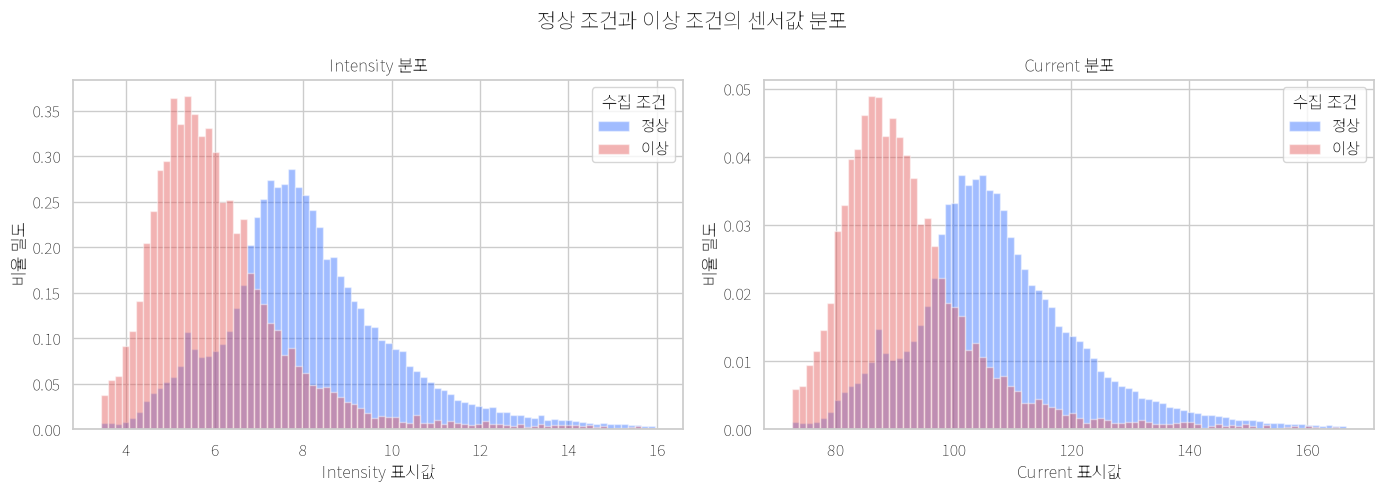

In [19]:
condition_colors = {"정상": "#2F6BFF", "이상": "#E45858"}
display_columns = {
    "Intensity": "Intensity 표시값",
    "Current": "Current 표시값",
}
distribution_plot_limits = {}

histogram_figure, histogram_axes = plt.subplots(1, 2, figsize=(14, 5))

for axis, (sensor_name, display_column) in zip(histogram_axes, display_columns.items()):
    lower_limit = distribution_plot_data[display_column].quantile(0.005)
    upper_limit = distribution_plot_data[display_column].quantile(0.995)
    distribution_plot_limits[sensor_name] = (lower_limit, upper_limit)
    common_bins = np.linspace(lower_limit, upper_limit, 81)

    for condition_name in ["정상", "이상"]:
        condition_values = distribution_plot_data.loc[
            (distribution_plot_data["조건"] == condition_name)
            & distribution_plot_data[display_column].between(lower_limit, upper_limit),
            display_column,
        ]
        axis.hist(
            condition_values,
            bins=common_bins,
            density=True,
            alpha=0.45,
            color=condition_colors[condition_name],
            label=condition_name,
        )

    axis.set_title(f"{sensor_name} 분포")
    axis.set_xlabel(f"{sensor_name} 표시값")
    axis.set_ylabel("비율 밀도")
    axis.legend(title="수집 조건")

histogram_figure.suptitle("정상 조건과 이상 조건의 센서값 분포", fontsize=15)
histogram_figure.tight_layout()
plt.show()

#### 히스토그램을 읽는 순서

1. 봉우리가 어디에 있는지 봅니다. 봉우리 위치가 다르면 자주 측정되는 값의 위치가 다르다는 뜻입니다.
2. 분포의 폭을 봅니다. 폭이 넓으면 값의 흔들림이 크다는 뜻입니다.
3. 파란색과 빨간색이 얼마나 겹치는지 봅니다. 많이 겹치면 센서값 하나만으로 완벽하게 구분하기 어렵습니다.
4. 한쪽으로 꼬리가 길게 이어지는지 봅니다. 일부 큰 값이나 작은 값이 있다는 뜻일 수 있습니다.

세로축은 행의 개수가 아니라 비율 밀도입니다. 두 파일의 행 수가 달라도 분포 모양을 비교할 수 있습니다.

#### 2-7-3. 상자그림으로 중심과 퍼짐 비교하기

상자그림의 가운데 선은 중앙값이고, 상자의 아래와 위는 Q1과 Q3입니다. 상자 높이가 가운데 50%의 범위인 IQR입니다.

이번 상자그림은 중심 부분을 읽기 쉽게 하려고 바깥 점 표시를 숨깁니다. 원본 데이터를 제거하거나 통계 계산에서 제외하는 것은 아닙니다.

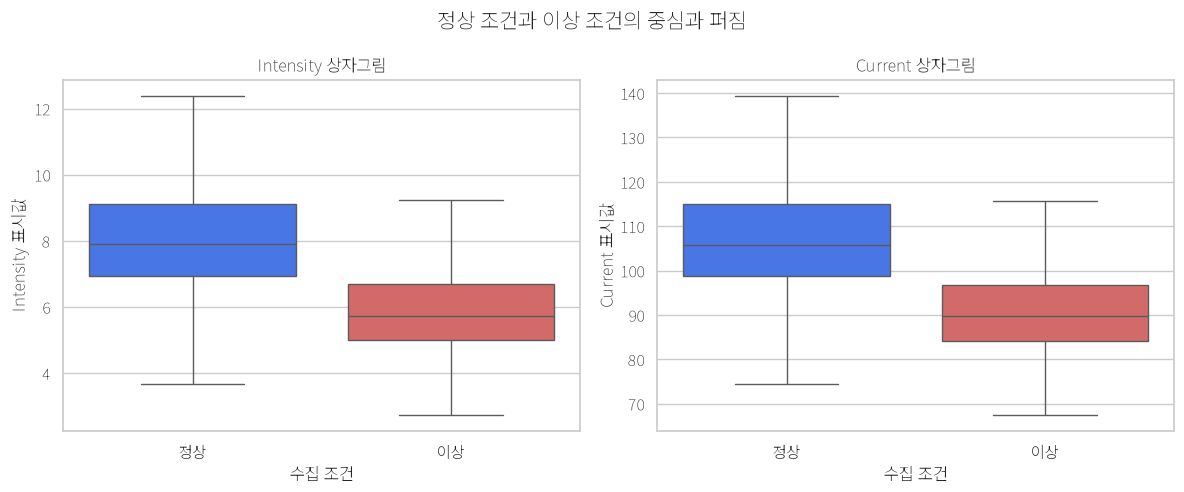

In [20]:
boxplot_figure, boxplot_axes = plt.subplots(1, 2, figsize=(12, 5))

for axis, (sensor_name, display_column) in zip(boxplot_axes, display_columns.items()):
    sns.boxplot(
        data=distribution_plot_data,
        x="조건",
        y=display_column,
        hue="조건",
        order=["정상", "이상"],
        hue_order=["정상", "이상"],
        palette=condition_colors,
        showfliers=False,
        legend=False,
        ax=axis,
    )
    axis.set_title(f"{sensor_name} 상자그림")
    axis.set_xlabel("수집 조건")
    axis.set_ylabel(f"{sensor_name} 표시값")

boxplot_figure.suptitle("정상 조건과 이상 조건의 중심과 퍼짐", fontsize=15)
boxplot_figure.tight_layout()
plt.show()

#### 2-7-4. 그래프 입력값 검증하기

그래프가 그려졌다는 사실만으로 계산이 맞다고 볼 수는 없습니다. 다음 사항을 확인합니다.

- 그래프용 행 수가 원본 두 파일의 합계와 같은가?
- 확대 표시값을 다시 나누면 원래 값으로 돌아오는가?
- 그래프용 값에 결측값이나 무한대가 없는가?
- 정상과 이상이 같은 가로축 범위로 비교되는가?
- 두 그래프에 `Intensity`와 `Current` 축이 각각 하나씩 있는가?

In [21]:
distribution_validation_checks = [
    ("그래프용 전체 행 수가 원본 합계와 같음", len(distribution_plot_data) == len(normal_dataset) + len(anomaly_dataset)),
    ("그래프용 정상 행 수가 정상 원본과 같음", (distribution_plot_data["조건"] == "정상").sum() == len(normal_dataset)),
    ("그래프용 이상 행 수가 이상 원본과 같음", (distribution_plot_data["조건"] == "이상").sum() == len(anomaly_dataset)),
    ("Intensity 확대 표시값을 원래 값으로 되돌릴 수 있음", np.allclose(distribution_plot_data["Intensity 표시값"] / 1_000_000, distribution_plot_data["Intensity"])),
    ("Current 확대 표시값을 원래 값으로 되돌릴 수 있음", np.allclose(distribution_plot_data["Current 표시값"] / 1_000_000_000, distribution_plot_data["Current"])),
    ("그래프용 숫자에 결측값이 없음", not distribution_plot_data[["Intensity 표시값", "Current 표시값"]].isna().any().any()),
    ("그래프용 숫자가 모두 유한함", np.isfinite(distribution_plot_data[["Intensity 표시값", "Current 표시값"]].to_numpy()).all()),
    ("두 센서의 표시 구간 하한이 상한보다 작음", all(lower < upper for lower, upper in distribution_plot_limits.values())),
    ("히스토그램 축이 센서 변수 2개와 일치함", len(histogram_axes) == len(display_columns)),
    ("상자그림 축이 센서 변수 2개와 일치함", len(boxplot_axes) == len(display_columns)),
]

distribution_validation_result = pd.DataFrame(
    distribution_validation_checks,
    columns=["검증 항목", "통과 여부"],
)
display(distribution_validation_result)

if distribution_validation_result["통과 여부"].all():
    print("분포 그래프 검증 결과: 모든 항목을 통과했습니다.")
else:
    print("분포 그래프 검증 결과: False인 항목을 추가로 확인해야 합니다.")

,검증 항목,통과 여부
0,그래프용 전체 행 수가 원본 합계와 같음,True
1,그래프용 정상 행 수가 정상 원본과 같음,True
2,그래프용 이상 행 수가 이상 원본과 같음,True
3,Intensity 확대 표시값을 원래 값으로 되돌릴 수 있음,True
4,Current 확대 표시값을 원래 값으로 되돌릴 수 있음,True
5,그래프용 숫자에 결측값이 없음,True
6,그래프용 숫자가 모두 유한함,True
7,두 센서의 표시 구간 하한이 상한보다 작음,True
8,히스토그램 축이 센서 변수 2개와 일치함,True
9,상자그림 축이 센서 변수 2개와 일치함,True


분포 그래프 검증 결과: 모든 항목을 통과했습니다.


### 분포 그래프 단계의 해석 범위

두 센서 모두 정상 조건과 이상 조건의 중심 위치 차이를 보여 주지만, 두 분포가 겹치는 구간도 확인해야 합니다. 따라서 단일 센서값 하나에 임의의 기준선을 그어 정상과 이상을 확정하지 않습니다.

다음 단계에서는 시간에 따른 `Intensity`와 `Current`의 움직임을 그려서 평균적인 위치뿐 아니라 반복 패턴, 흔들림, 급격한 변화가 있는지 확인합니다.

### 2-8. 시간에 따른 센서 신호 확인하기

분포 그래프는 센서값이 어디에 많이 모여 있는지 보여 주지만, 값이 **어떤 순서로 움직였는지**는 보여 주지 않습니다. 이번에는 시간에 따라 `Intensity`와 `Current`가 어떻게 변하는지 확인합니다.

확인할 내용은 다음과 같습니다.

1. 전체 측정 시간 동안 신호가 일정한가, 구간별로 달라지는가?
2. 정상 조건과 이상 조건에서 반복 모양과 흔들림이 다른가?
3. 40행짜리 약 5초 윈도우에는 어떤 움직임이 들어가는가?

정상 파일과 이상 파일은 날짜와 기록 시간이 다르므로 하나의 선으로 이어 붙이지 않습니다.

#### 2-8-1. 시간 그래프용 데이터 만들기

각 파일의 첫 측정 시각을 0분으로 두고 경과 시간을 계산합니다. 이렇게 하면 날짜 대신 **측정 시작 후 몇 분이 지났는지**를 가로축으로 사용할 수 있습니다.

앞에서 찾은 1초 초과 공백이 나오면 `구간 번호`를 하나 증가시킵니다. 그래프는 구간별로 따로 선을 그리기 때문에 공백 전후의 값을 하나의 연속된 선으로 잘못 연결하지 않습니다.

In [22]:
def make_time_plot_data(dataset, time_gaps, gap_threshold):
    time_plot_data = dataset[["Time", "Intensity", "Current"]].copy()
    time_plot_data["경과 시간(분)"] = (
        time_plot_data["Time"] - time_plot_data["Time"].iloc[0]
    ).dt.total_seconds() / 60
    time_plot_data["Intensity 표시값"] = time_plot_data["Intensity"] * 1_000_000
    time_plot_data["Current 표시값"] = time_plot_data["Current"] * 1_000_000_000
    time_plot_data["구간 번호"] = (time_gaps.fillna(0) > gap_threshold).cumsum()
    return time_plot_data


normal_time_plot_data = make_time_plot_data(
    normal_dataset,
    normal_time_gap_seconds,
    normal_gap_threshold,
)
anomaly_time_plot_data = make_time_plot_data(
    anomaly_dataset,
    anomaly_time_gap_seconds,
    anomaly_gap_threshold,
)

time_segment_summary = pd.DataFrame({
    "조건": ["정상", "이상"],
    "전체 행 수": [len(normal_time_plot_data), len(anomaly_time_plot_data)],
    "연속 구간 수": [
        normal_time_plot_data["구간 번호"].nunique(),
        anomaly_time_plot_data["구간 번호"].nunique(),
    ],
    "1초 초과 공백 수": [len(normal_long_gaps), len(anomaly_long_gaps)],
})

time_segment_summary

,조건,전체 행 수,연속 구간 수,1초 초과 공백 수
0,정상,92280,19,18
1,이상,11800,2,1


#### 연속 구간 수를 읽는 방법

긴 공백이 하나 생기면 연속된 기록은 앞부분과 뒷부분 두 구간으로 나뉩니다.

```text
긴 공백 0개 → 연속 구간 1개
긴 공백 1개 → 연속 구간 2개
긴 공백 18개 → 연속 구간 19개
```

이 구간은 데이터가 시간상 끊긴 부분을 표시한 것이며 제품이나 가공된 구멍의 개수를 뜻하지 않습니다.

#### 2-8-2. 전체 측정 흐름 보기

정상 조건은 약 190분, 이상 조건은 약 24분으로 기록 시간이 크게 다릅니다. 그래서 각 조건을 별도의 행에 그리고, 같은 센서끼리는 동일한 세로축을 사용합니다.

그래프의 선이 중간에 끊긴 부분은 1초를 넘는 시간 공백입니다. 실제 값이 그 사이에서 직선으로 움직였다는 오해를 막기 위해 선을 연결하지 않습니다.

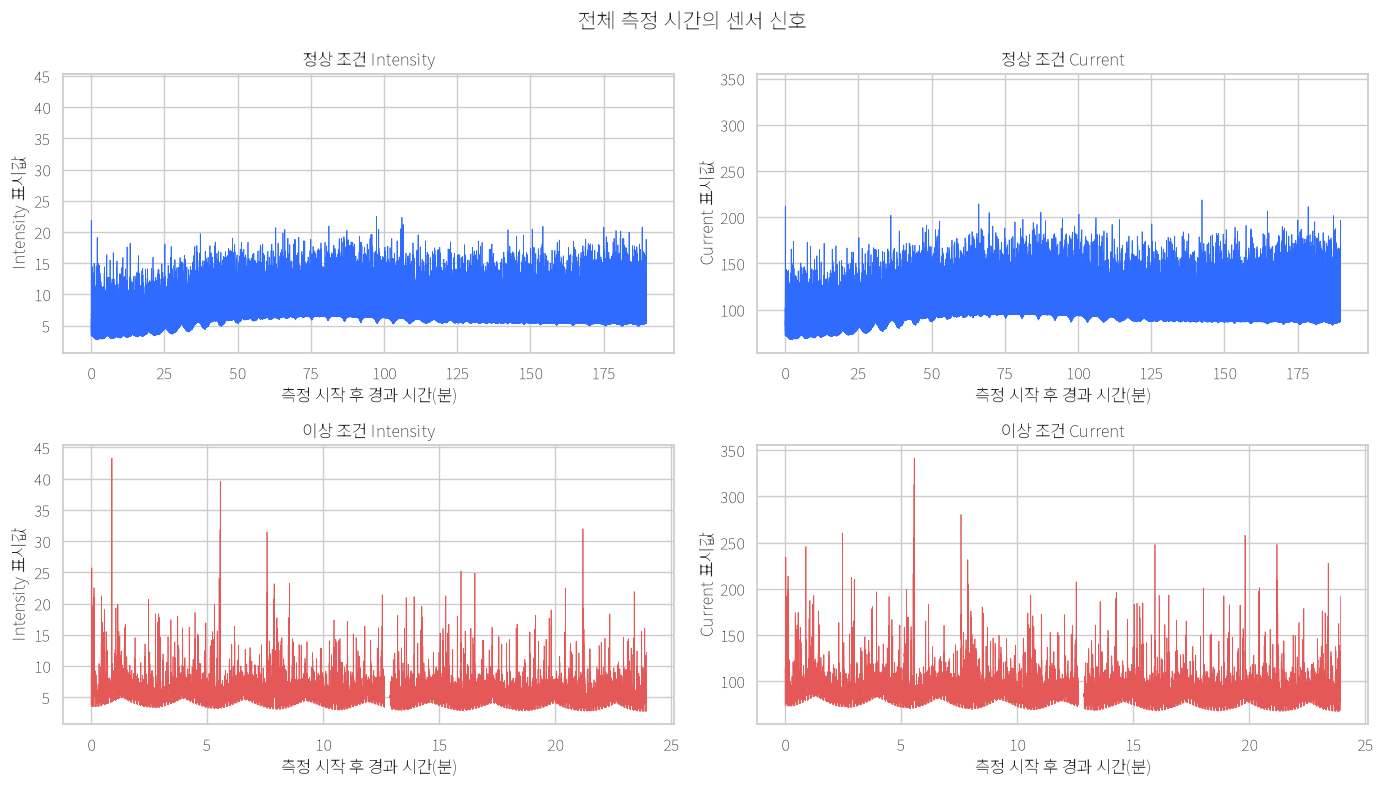

In [23]:
time_overview_figure, time_overview_axes = plt.subplots(
    2,
    2,
    figsize=(14, 8),
    sharey="col",
)

time_plot_settings = [
    (normal_time_plot_data, "정상", condition_colors["정상"]),
    (anomaly_time_plot_data, "이상", condition_colors["이상"]),
]

for row_number, (plot_data, condition_name, line_color) in enumerate(time_plot_settings):
    for segment_number, segment_data in plot_data.groupby("구간 번호"):
        time_overview_axes[row_number, 0].plot(
            segment_data["경과 시간(분)"],
            segment_data["Intensity 표시값"],
            color=line_color,
            linewidth=0.55,
            rasterized=True,
        )
        time_overview_axes[row_number, 1].plot(
            segment_data["경과 시간(분)"],
            segment_data["Current 표시값"],
            color=line_color,
            linewidth=0.55,
            rasterized=True,
        )

    time_overview_axes[row_number, 0].set_title(f"{condition_name} 조건 Intensity")
    time_overview_axes[row_number, 1].set_title(f"{condition_name} 조건 Current")
    time_overview_axes[row_number, 0].set_ylabel("Intensity 표시값")
    time_overview_axes[row_number, 1].set_ylabel("Current 표시값")
    time_overview_axes[row_number, 0].set_xlabel("측정 시작 후 경과 시간(분)")
    time_overview_axes[row_number, 1].set_xlabel("측정 시작 후 경과 시간(분)")

time_overview_figure.suptitle("전체 측정 시간의 센서 신호", fontsize=15)
time_overview_figure.tight_layout()
plt.show()

#### 전체 시간 그래프에서 확인할 것

- 신호의 중심 위치가 시간에 따라 이동하는지 확인합니다.
- 일정한 모양이 반복되는지 확인합니다.
- 짧고 큰 봉우리가 자주 나타나는지 확인합니다.
- 특정 시간대에서만 신호 모양이 달라지는지 확인합니다.

선이 복잡하게 겹쳐 보이면 데이터가 잘못된 것이 아니라 전체 기록이 매우 촘촘하기 때문입니다. 세부 움직임은 짧은 윈도우 그래프로 확대해서 확인합니다.

#### 2-8-3. 40행짜리 첫 윈도우 비교하기

가이드북과 같은 크기인 40행을 정상 파일과 이상 파일에서 각각 가져옵니다. 두 윈도우 모두 첫 번째 행을 0초로 바꿔 같은 시간축에서 비교합니다.

40행에는 행 사이의 간격이 39개 있으므로 첫 행부터 마지막 행까지의 실제 시간은 약 4.7초입니다. 흔히 40회 측정 구간을 약 5초라고 간단히 표현합니다.

첫 윈도우는 윈도우의 구조를 이해하기 위한 예시이며 파일 전체를 대표한다고 단정하지 않습니다.

In [24]:
window_size = 40


def make_first_window(dataset, condition_name):
    window = dataset.iloc[:window_size][["Time", "Intensity", "Current"]].copy()
    window["경과 시간(초)"] = (
        window["Time"] - window["Time"].iloc[0]
    ).dt.total_seconds()
    window["Intensity 표시값"] = window["Intensity"] * 1_000_000
    window["Current 표시값"] = window["Current"] * 1_000_000_000
    window["조건"] = condition_name
    return window


normal_first_window = make_first_window(normal_dataset, "정상")
anomaly_first_window = make_first_window(anomaly_dataset, "이상")

window_duration_summary = pd.DataFrame({
    "조건": ["정상", "이상"],
    "윈도우 행 수": [len(normal_first_window), len(anomaly_first_window)],
    "첫 행부터 마지막 행까지의 시간(초)": [
        normal_first_window["경과 시간(초)"].iloc[-1],
        anomaly_first_window["경과 시간(초)"].iloc[-1],
    ],
})

window_duration_summary

,조건,윈도우 행 수,첫 행부터 마지막 행까지의 시간(초)
0,정상,40,4.703
1,이상,40,4.703


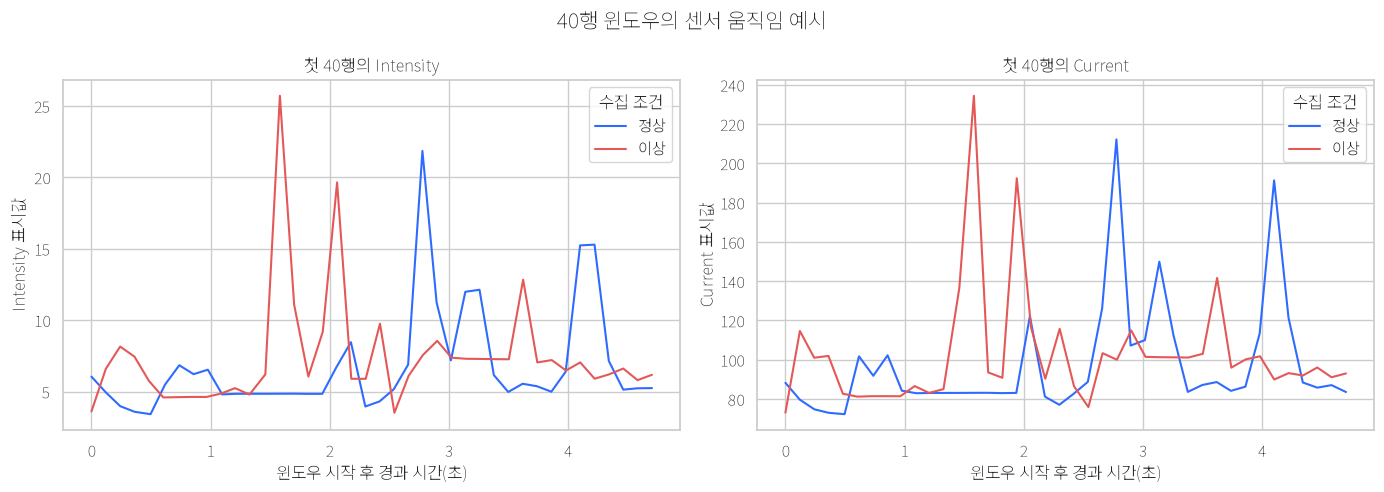

In [25]:
first_window_figure, first_window_axes = plt.subplots(1, 2, figsize=(14, 5))

for window_data, condition_name in [
    (normal_first_window, "정상"),
    (anomaly_first_window, "이상"),
]:
    first_window_axes[0].plot(
        window_data["경과 시간(초)"],
        window_data["Intensity 표시값"],
        color=condition_colors[condition_name],
        linewidth=1.5,
        label=condition_name,
    )
    first_window_axes[1].plot(
        window_data["경과 시간(초)"],
        window_data["Current 표시값"],
        color=condition_colors[condition_name],
        linewidth=1.5,
        label=condition_name,
    )

first_window_axes[0].set_title("첫 40행의 Intensity")
first_window_axes[1].set_title("첫 40행의 Current")
first_window_axes[0].set_ylabel("Intensity 표시값")
first_window_axes[1].set_ylabel("Current 표시값")

for axis in first_window_axes:
    axis.set_xlabel("윈도우 시작 후 경과 시간(초)")
    axis.legend(title="수집 조건")

first_window_figure.suptitle("40행 윈도우의 센서 움직임 예시", fontsize=15)
first_window_figure.tight_layout()
plt.show()

#### 2-8-4. 시간 그래프 계산 검증하기

시간 그래프가 원본의 순서를 보존하는지, 공백 개수와 구간 개수가 맞는지, 40행 윈도우가 실제로 40행인지 검사합니다.

In [26]:
time_series_validation_checks = [
    ("정상 시간 그래프의 행 수가 원본과 같음", len(normal_time_plot_data) == len(normal_dataset)),
    ("이상 시간 그래프의 행 수가 원본과 같음", len(anomaly_time_plot_data) == len(anomaly_dataset)),
    ("정상 경과 시간이 0에서 시작하고 증가함", normal_time_plot_data["경과 시간(분)"].iloc[0] == 0 and normal_time_plot_data["경과 시간(분)"].is_monotonic_increasing),
    ("이상 경과 시간이 0에서 시작하고 증가함", anomaly_time_plot_data["경과 시간(분)"].iloc[0] == 0 and anomaly_time_plot_data["경과 시간(분)"].is_monotonic_increasing),
    ("정상 연속 구간 수가 긴 공백 수보다 1개 많음", normal_time_plot_data["구간 번호"].nunique() == len(normal_long_gaps) + 1),
    ("이상 연속 구간 수가 긴 공백 수보다 1개 많음", anomaly_time_plot_data["구간 번호"].nunique() == len(anomaly_long_gaps) + 1),
    ("정상 첫 윈도우가 40행임", len(normal_first_window) == window_size),
    ("이상 첫 윈도우가 40행임", len(anomaly_first_window) == window_size),
    ("두 첫 윈도우 안에 1초 초과 공백이 없음", normal_first_window["Time"].diff().dt.total_seconds().max() <= normal_gap_threshold and anomaly_first_window["Time"].diff().dt.total_seconds().max() <= anomaly_gap_threshold),
    ("전체 시간 그래프가 4개 축으로 구성됨", time_overview_axes.size == 4),
    ("첫 윈도우 그래프가 2개 축으로 구성됨", len(first_window_axes) == 2),
]

time_series_validation_result = pd.DataFrame(
    time_series_validation_checks,
    columns=["검증 항목", "통과 여부"],
)
display(time_series_validation_result)

if time_series_validation_result["통과 여부"].all():
    print("시간 그래프 검증 결과: 모든 항목을 통과했습니다.")
else:
    print("시간 그래프 검증 결과: False인 항목을 추가로 확인해야 합니다.")

,검증 항목,통과 여부
0,정상 시간 그래프의 행 수가 원본과 같음,True
1,이상 시간 그래프의 행 수가 원본과 같음,True
2,정상 경과 시간이 0에서 시작하고 증가함,True
3,이상 경과 시간이 0에서 시작하고 증가함,True
4,정상 연속 구간 수가 긴 공백 수보다 1개 많음,True
5,이상 연속 구간 수가 긴 공백 수보다 1개 많음,True
6,정상 첫 윈도우가 40행임,True
7,이상 첫 윈도우가 40행임,True
8,두 첫 윈도우 안에 1초 초과 공백이 없음,True
9,전체 시간 그래프가 4개 축으로 구성됨,True


시간 그래프 검증 결과: 모든 항목을 통과했습니다.


### 시간 그래프 단계에서 말할 수 있는 것

전체 그래프는 센서 신호가 시간에 따라 일정하지 않고 반복적으로 변한다는 점을 보여 줍니다. 짧은 윈도우 그래프는 AI가 한 행의 크기뿐 아니라 약 5초 동안의 상승, 하강, 흔들림을 함께 볼 수 있다는 점을 보여 줍니다.

첫 윈도우 하나만으로 정상과 이상을 일반화할 수는 없습니다. 이후 모든 연속 구간을 동일한 규칙으로 윈도우화하고, 학습 구간과 평가 구간을 분리한 뒤 비교해야 합니다.

다음 EDA에서는 `Intensity`와 `Current`가 서로 얼마나 함께 움직이는지 산점도와 상관계수로 확인합니다.

### 2-9. Intensity와 Current의 관계 확인하기

두 센서는 모두 반사광과 관련된 신호입니다. 이번에는 `Intensity`가 커질 때 `Current`도 함께 커지는지 확인합니다.

시계열 데이터이므로 단순 상관계수 하나만 믿지 않습니다. 다음 두 가지 관계를 나누어 봅니다.

1. **원래 값의 관계:** 같은 시점의 `Intensity`와 `Current`가 비슷한 위치에서 움직이는가?
2. **변화량의 관계:** 앞 시점보다 `Intensity`가 증가할 때 `Current`도 함께 증가하는가?

정상과 이상은 날짜와 평균 위치가 다르므로 합쳐서 상관계수를 계산하지 않고 조건별로 따로 계산합니다.

#### 2-9-1. 상관계수 쉽게 이해하기

상관계수는 두 숫자가 함께 움직이는 정도를 `-1`부터 `1` 사이로 나타냅니다.

| 값 | 쉬운 의미 |
|---:|---|
| `1`에 가까움 | 한 변수가 커질 때 다른 변수도 함께 커지는 경향 |
| `0`에 가까움 | 일정한 방향의 관계가 약함 |
| `-1`에 가까움 | 한 변수가 커질 때 다른 변수는 작아지는 경향 |

- **피어슨 상관계수:** 점들이 직선에 가까운 관계인지 확인
- **스피어만 상관계수:** 정확한 직선이 아니어도 한쪽이 커질수록 다른 쪽도 대체로 커지는지 확인

상관관계가 높아도 한 변수가 다른 변수의 원인이라는 뜻은 아닙니다.

#### 2-9-2. 긴 공백을 넘지 않고 변화량 계산하기

변화량은 `현재 값 - 바로 앞 값`입니다.

```text
Intensity 변화량 = 현재 Intensity - 앞 행의 Intensity
Current 변화량   = 현재 Current - 앞 행의 Current
```

긴 공백 뒤의 첫 행은 공백 전 마지막 행과 비교하지 않습니다. 앞에서 만든 `구간 번호`별로 변화량을 계산하여 서로 끊긴 측정을 연결하는 오류를 막습니다.

In [27]:
def make_relation_data(time_plot_data):
    relation_data = time_plot_data[
        ["Intensity", "Current", "구간 번호"]
    ].copy()
    relation_data["Intensity 변화량"] = relation_data.groupby("구간 번호")["Intensity"].diff()
    relation_data["Current 변화량"] = relation_data.groupby("구간 번호")["Current"].diff()
    return relation_data


normal_relation_data = make_relation_data(normal_time_plot_data)
anomaly_relation_data = make_relation_data(anomaly_time_plot_data)


def make_correlation_row(relation_data, condition_name):
    valid_changes = relation_data[["Intensity 변화량", "Current 변화량"]].dropna()
    return {
        "조건": condition_name,
        "원값 피어슨 상관": relation_data["Intensity"].corr(relation_data["Current"], method="pearson"),
        "원값 스피어만 상관": relation_data["Intensity"].corr(relation_data["Current"], method="spearman"),
        "변화량 피어슨 상관": valid_changes["Intensity 변화량"].corr(valid_changes["Current 변화량"], method="pearson"),
        "원값 행 수": len(relation_data),
        "변화량 행 수": len(valid_changes),
    }


sensor_correlation_summary = pd.DataFrame([
    make_correlation_row(normal_relation_data, "정상"),
    make_correlation_row(anomaly_relation_data, "이상"),
])

with pd.option_context("display.float_format", "{:.4f}".format):
    display(sensor_correlation_summary)

,조건,원값 피어슨 상관,원값 스피어만 상관,변화량 피어슨 상관,원값 행 수,변화량 행 수
0,정상,0.8353,0.8548,0.5646,92280,92261
1,이상,0.7177,0.7915,0.4212,11800,11798


#### 원값 상관과 변화량 상관을 함께 보는 이유

두 센서가 전체적으로 비슷한 높낮이를 가지면 원값 상관은 높게 나올 수 있습니다. 하지만 이것만으로 순간적인 움직임까지 같다고 볼 수는 없습니다.

변화량 상관은 다음 질문을 확인합니다.

> 바로 앞 측정값과 비교했을 때 두 센서가 같은 방향으로 얼마나 함께 움직이는가?

원값 상관보다 변화량 상관이 낮아지면, 전체적인 위치는 비슷하지만 매 순간의 움직임은 완전히 같지 않다는 뜻입니다.

#### 2-9-3. 산점도로 관계 모양 확인하기

산점도에서 점 하나는 같은 시점의 `Intensity`와 `Current` 한 쌍입니다.

전체 점을 모두 그리면 약 10만 개가 겹쳐 형태를 보기 어렵기 때문에 각 조건에서 시간순으로 일정한 간격을 두고 최대 5,000개를 표시합니다. 상관계수는 축소한 점이 아니라 전체 데이터를 사용합니다.

위쪽 두 그래프는 원래 값, 아래쪽 두 그래프는 구간 안에서 계산한 변화량입니다.

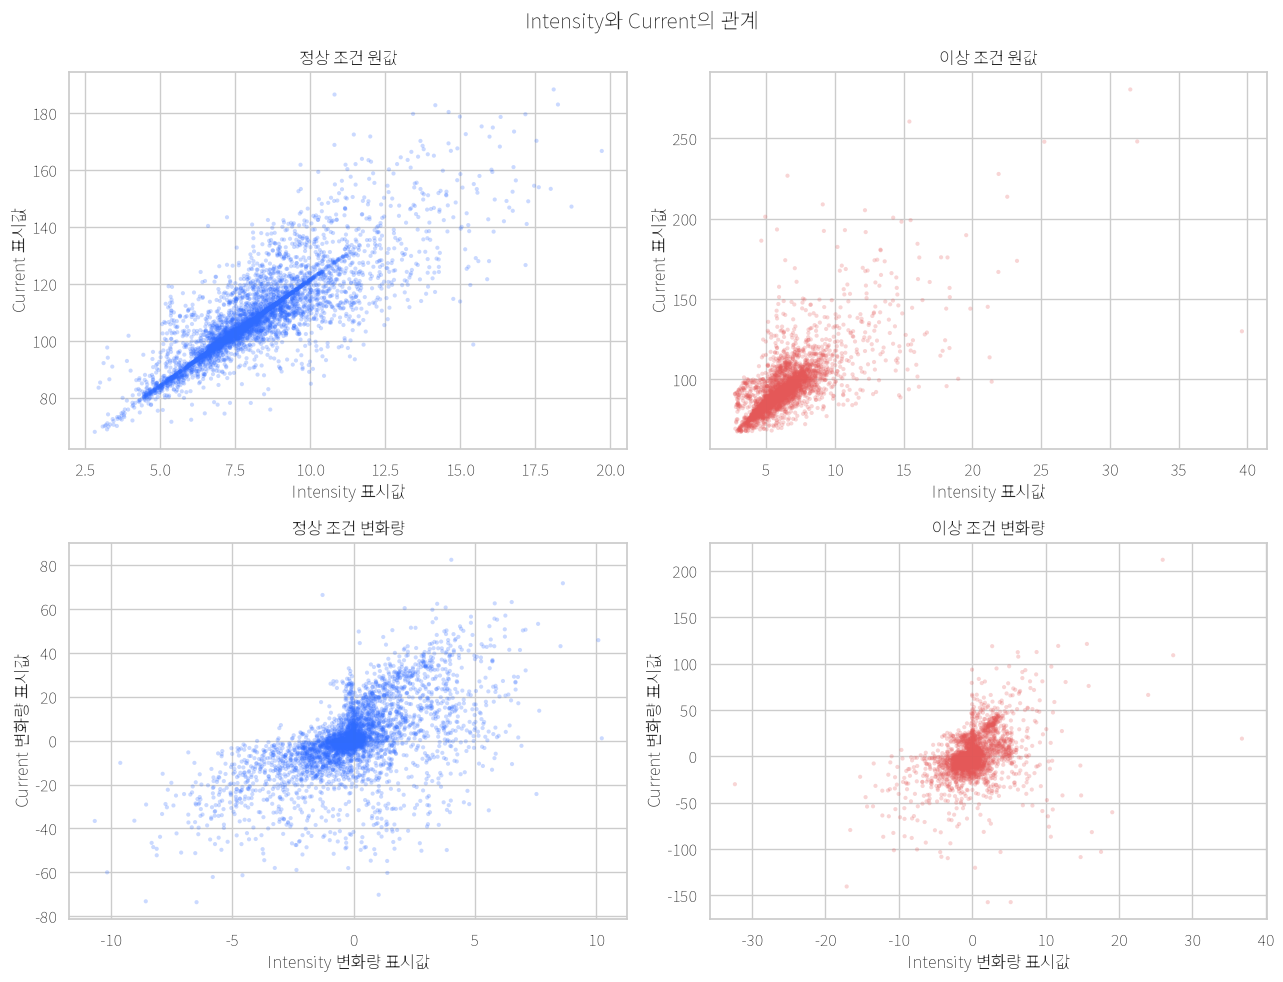

In [28]:
def evenly_spaced_sample(dataframe, maximum_rows=5000):
    if len(dataframe) <= maximum_rows:
        return dataframe.copy()
    positions = np.linspace(0, len(dataframe) - 1, maximum_rows, dtype=int)
    return dataframe.iloc[positions].copy()


normal_level_sample = evenly_spaced_sample(normal_relation_data)
anomaly_level_sample = evenly_spaced_sample(anomaly_relation_data)
normal_change_sample = evenly_spaced_sample(
    normal_relation_data.dropna(subset=["Intensity 변화량", "Current 변화량"])
)
anomaly_change_sample = evenly_spaced_sample(
    anomaly_relation_data.dropna(subset=["Intensity 변화량", "Current 변화량"])
)

sensor_relation_figure, sensor_relation_axes = plt.subplots(2, 2, figsize=(13, 10))

relation_plot_settings = [
    (sensor_relation_axes[0, 0], normal_level_sample, "Intensity", "Current", "정상 조건 원값", "정상"),
    (sensor_relation_axes[0, 1], anomaly_level_sample, "Intensity", "Current", "이상 조건 원값", "이상"),
    (sensor_relation_axes[1, 0], normal_change_sample, "Intensity 변화량", "Current 변화량", "정상 조건 변화량", "정상"),
    (sensor_relation_axes[1, 1], anomaly_change_sample, "Intensity 변화량", "Current 변화량", "이상 조건 변화량", "이상"),
]

for axis, plot_data, x_column, y_column, title, condition_name in relation_plot_settings:
    axis.scatter(
        plot_data[x_column] * 1_000_000,
        plot_data[y_column] * 1_000_000_000,
        s=9,
        alpha=0.25,
        color=condition_colors[condition_name],
        edgecolors="none",
        rasterized=True,
    )
    axis.set_title(title)
    axis.set_xlabel(f"{x_column} 표시값")
    axis.set_ylabel(f"{y_column} 표시값")

sensor_relation_figure.suptitle("Intensity와 Current의 관계", fontsize=15)
sensor_relation_figure.tight_layout()
plt.show()

#### 산점도를 읽는 방법

- 점들이 왼쪽 아래에서 오른쪽 위 방향으로 모이면 두 변수가 함께 커지는 경향이 있습니다.
- 점들이 넓게 흩어지면 같은 `Intensity`에서도 여러 `Current` 값이 나타난다는 뜻입니다.
- 정상과 이상의 점 모양이 다르면 두 센서 사이의 관계도 조건에 따라 달라질 가능성이 있습니다.

점이 많이 겹치는 부분은 더 진하게 보입니다. 이 그래프만으로 정상·이상 판정선을 정하지 않습니다.

#### 2-9-4. 센서 관계 계산 검증하기

변화량 행 수는 전체 행 수에서 연속 구간 수를 뺀 값이어야 합니다. 각 구간의 첫 행은 비교할 앞 행이 없어 변화량이 하나씩 비기 때문입니다. 상관계수가 허용 범위인 `-1`부터 `1` 사이인지도 확인합니다.

In [29]:
correlation_columns = [
    "원값 피어슨 상관",
    "원값 스피어만 상관",
    "변화량 피어슨 상관",
]

relation_validation_checks = [
    ("정상 원값 관계표 행 수가 정상 원본과 같음", len(normal_relation_data) == len(normal_dataset)),
    ("이상 원값 관계표 행 수가 이상 원본과 같음", len(anomaly_relation_data) == len(anomaly_dataset)),
    ("정상 변화량 행 수가 전체 행 수에서 구간 수를 뺀 값과 같음", normal_relation_data[["Intensity 변화량", "Current 변화량"]].dropna().shape[0] == len(normal_dataset) - normal_time_plot_data["구간 번호"].nunique()),
    ("이상 변화량 행 수가 전체 행 수에서 구간 수를 뺀 값과 같음", anomaly_relation_data[["Intensity 변화량", "Current 변화량"]].dropna().shape[0] == len(anomaly_dataset) - anomaly_time_plot_data["구간 번호"].nunique()),
    ("모든 상관계수가 -1부터 1 사이임", sensor_correlation_summary[correlation_columns].apply(lambda column: column.between(-1, 1).all()).all()),
    ("정상 산점도 표본이 5,000행 이하임", len(normal_level_sample) <= 5000 and len(normal_change_sample) <= 5000),
    ("이상 산점도 표본이 5,000행 이하임", len(anomaly_level_sample) <= 5000 and len(anomaly_change_sample) <= 5000),
    ("산점도에 실제로 사용한 숫자가 모두 유한함", all(
        np.isfinite(sample[columns].to_numpy()).all()
        for sample, columns in [
            (normal_level_sample, ["Intensity", "Current"]),
            (anomaly_level_sample, ["Intensity", "Current"]),
            (normal_change_sample, ["Intensity 변화량", "Current 변화량"]),
            (anomaly_change_sample, ["Intensity 변화량", "Current 변화량"]),
        ]
    )),
    ("관계 그래프가 4개 축으로 구성됨", sensor_relation_axes.size == 4),
]

relation_validation_result = pd.DataFrame(
    relation_validation_checks,
    columns=["검증 항목", "통과 여부"],
)
display(relation_validation_result)

if relation_validation_result["통과 여부"].all():
    print("센서 관계 검증 결과: 모든 항목을 통과했습니다.")
else:
    print("센서 관계 검증 결과: False인 항목을 추가로 확인해야 합니다.")

,검증 항목,통과 여부
0,정상 원값 관계표 행 수가 정상 원본과 같음,True
1,이상 원값 관계표 행 수가 이상 원본과 같음,True
2,정상 변화량 행 수가 전체 행 수에서 구간 수를 뺀 값과 같음,True
3,이상 변화량 행 수가 전체 행 수에서 구간 수를 뺀 값과 같음,True
4,모든 상관계수가 -1부터 1 사이임,True
5,"정상 산점도 표본이 5,000행 이하임",True
6,"이상 산점도 표본이 5,000행 이하임",True
7,산점도에 실제로 사용한 숫자가 모두 유한함,True
8,관계 그래프가 4개 축으로 구성됨,True


센서 관계 검증 결과: 모든 항목을 통과했습니다.


### 센서 관계 단계의 해석 범위

`Intensity`와 `Current`는 정상과 이상 조건 모두에서 양의 관계를 보입니다. 원값 상관이 높더라도 변화량 상관은 더 낮을 수 있으므로 두 변수가 완전히 같은 정보를 가진다고 단정하지 않습니다.

또한 연속된 행들은 서로 관련되어 있으므로 일반 표 데이터처럼 10만 개의 독립 사례라고 해석하거나 단순한 유의확률만으로 결론 내리지 않습니다.

다음 EDA에서는 큰 값이 센서 오류인지, 실제 공정 신호 후보인지 판단하기 위해 이상치의 위치와 반복 여부를 확인합니다. 이때도 이상치를 바로 삭제하지 않고 시간 그래프와 함께 검토합니다.

### 2-10. 1초 초과 공백 처리 원칙 정하기

앞에서 확인한 보통의 측정 간격은 약 `0.12초`입니다. 그런데 1초가 넘게 비어 있다면 평소 간격보다 훨씬 긴 시간 동안 측정이 이어지지 않은 것입니다. 가장 긴 약 13초의 공백을 억지로 채우면 실제로 측정하지 않은 100개 이상의 값을 만들어 낼 수도 있습니다.

따라서 이 분석에서는 다음 원칙을 사용합니다.

1. **공백 앞뒤의 실제 행은 삭제하지 않습니다.** 두 행 모두 실제로 측정된 값이기 때문입니다.
2. **긴 공백 사이를 평균값 등으로 채우지 않습니다.** 없는 측정값을 사실처럼 만들지 않기 위해서입니다.
3. **1초 초과 공백 다음 행부터 새 연속 구간으로 봅니다.** 시간 그래프와 변화량, 윈도우가 공백을 건너뛰지 않게 합니다.
4. **40행 윈도우는 같은 연속 구간 안에서만 만듭니다.** 구간 끝의 40행 미만 나머지는 원본과 EDA에는 남기되, 40행짜리 모델 입력을 만들 때만 제외합니다.
5. **공백 자체를 지금 바로 이상 징후로 사용하지 않습니다.** 설비 정지일 수도 있고 단순 저장 중단일 수도 있어 외부 작업 기록 없이는 원인을 확정할 수 없기 때문입니다.

`1초`는 정답으로 증명된 숫자가 아니라 현재 데이터에 맞춘 안전한 탐색 기준입니다. 아래에서 0.5초, 1초, 2초를 사용했을 때 구간 수가 얼마나 달라지는지도 확인합니다.

#### 2-10-1. 공백으로 나눈 연속 구간의 크기 확인하기

아래 표는 각 연속 구간에 행이 몇 개 있는지와, 그 안에서 **겹치지 않는 40행 묶음**을 몇 개 만들 수 있는지를 계산합니다. 아직 모델 입력을 만드는 단계는 아니며, 공백 처리 규칙 때문에 데이터가 얼마나 남는지 미리 확인하는 계산입니다.

나중에 윈도우를 서로 겹치게 만들면 실제 윈도우 수는 달라질 수 있습니다.

In [30]:
gap_policy_window_size = 40


def make_segment_size_table(time_plot_data, condition_name):
    table = (
        time_plot_data.groupby("구간 번호", sort=True)
        .size()
        .rename("행 수")
        .reset_index()
    )
    table.insert(0, "조건", condition_name)
    table["가능한 비중첩 40행 묶음 수"] = table["행 수"] // gap_policy_window_size
    table["40행으로 묶고 남는 행 수"] = table["행 수"] % gap_policy_window_size
    return table


segment_size_table = pd.concat(
    [
        make_segment_size_table(normal_time_plot_data, "정상"),
        make_segment_size_table(anomaly_time_plot_data, "이상"),
    ],
    ignore_index=True,
)

segment_policy_summary = (
    segment_size_table.groupby("조건", sort=False)
    .agg(
        연속_구간_수=("구간 번호", "nunique"),
        전체_행_수=("행 수", "sum"),
        가능한_비중첩_40행_묶음_수=("가능한 비중첩 40행 묶음 수", "sum"),
        묶고_남는_행_수=("40행으로 묶고 남는 행 수", "sum"),
        가장_짧은_구간_행_수=("행 수", "min"),
        가장_긴_구간_행_수=("행 수", "max"),
    )
    .reset_index()
)

display(segment_policy_summary)
print("행 수가 적은 연속 구간부터 확인")
display(segment_size_table.sort_values(["행 수", "조건"]).head(10))

,조건,연속_구간_수,전체_행_수,가능한_비중첩_40행_묶음_수,묶고_남는_행_수,가장_짧은_구간_행_수,가장_긴_구간_행_수
0,정상,19,92280,2299,320,3891,4977
1,이상,2,11800,294,40,5508,6292


행 수가 적은 연속 구간부터 확인


,조건,구간 번호,행 수,가능한 비중첩 40행 묶음 수,40행으로 묶고 남는 행 수
18,정상,18,3891,97,11
0,정상,0,4566,114,6
9,정상,9,4890,122,10
15,정상,15,4908,122,28
4,정상,4,4910,122,30
10,정상,10,4913,122,33
14,정상,14,4917,122,37
12,정상,12,4918,122,38
13,정상,13,4920,123,0
8,정상,8,4922,123,2


#### 2-10-2. 1초라는 기준이 너무 민감하지 않은지 확인하기

기준을 조금 바꿨는데 구간 수가 크게 달라지면 분석 결과도 그 기준에 크게 의존할 수 있습니다. 그래서 0.5초, 1초, 2초를 각각 경계로 사용했을 때 생기는 구간 수를 비교합니다.

이 표는 기준의 안정성을 확인하기 위한 것이며, 모델에 날짜나 공백 횟수를 입력한다는 뜻은 아닙니다.

In [31]:
gap_threshold_candidates = [0.5, 1.0, 2.0]
gap_sensitivity_rows = []

for condition_name, time_gaps in [
    ("정상", normal_time_gap_seconds),
    ("이상", anomaly_time_gap_seconds),
]:
    for threshold_seconds in gap_threshold_candidates:
        gap_count = int((time_gaps > threshold_seconds).sum())
        gap_sensitivity_rows.append(
            {
                "조건": condition_name,
                "공백 기준(초)": threshold_seconds,
                "기준 초과 공백 수": gap_count,
                "만들어지는 연속 구간 수": gap_count + 1,
            }
        )

gap_sensitivity_summary = pd.DataFrame(gap_sensitivity_rows)
display(gap_sensitivity_summary)

,조건,공백 기준(초),기준 초과 공백 수,만들어지는 연속 구간 수
0,정상,0.5,18,19
1,정상,1.0,18,19
2,정상,2.0,18,19
3,이상,0.5,1,2
4,이상,1.0,1,2
5,이상,2.0,1,2


#### 2-10-3. 공백 처리 계산 검증하기

행을 잃어버리지 않았는지, 공백 수와 구간 수가 맞는지, 각 구간이 `40행 묶음 × 묶음 수 + 나머지 행`으로 정확히 다시 만들어지는지 확인합니다.

In [32]:
gap_policy_validation_checks = [
    ("정상 구간의 행 수 합이 정상 원본과 같음", segment_size_table.loc[segment_size_table["조건"] == "정상", "행 수"].sum() == len(normal_dataset)),
    ("이상 구간의 행 수 합이 이상 원본과 같음", segment_size_table.loc[segment_size_table["조건"] == "이상", "행 수"].sum() == len(anomaly_dataset)),
    ("정상 구간 수가 1초 초과 공백 수보다 1개 많음", normal_time_plot_data["구간 번호"].nunique() == len(normal_long_gaps) + 1),
    ("이상 구간 수가 1초 초과 공백 수보다 1개 많음", anomaly_time_plot_data["구간 번호"].nunique() == len(anomaly_long_gaps) + 1),
    ("모든 구간의 행 수가 40행 묶음과 나머지로 정확히 복원됨", (
        segment_size_table["가능한 비중첩 40행 묶음 수"] * gap_policy_window_size
        + segment_size_table["40행으로 묶고 남는 행 수"]
        == segment_size_table["행 수"]
    ).all()),
    ("모든 나머지 행 수가 0 이상 40 미만임", segment_size_table["40행으로 묶고 남는 행 수"].between(0, gap_policy_window_size - 1).all()),
    ("정상과 이상 모두 실제 사용 기준이 1초임", normal_gap_threshold == 1.0 and anomaly_gap_threshold == 1.0),
]

gap_policy_validation_result = pd.DataFrame(
    gap_policy_validation_checks,
    columns=["검증 항목", "통과 여부"],
)
display(gap_policy_validation_result)

if gap_policy_validation_result["통과 여부"].all():
    print("공백 처리 원칙 검증 결과: 모든 항목을 통과했습니다.")
else:
    print("공백 처리 원칙 검증 결과: False인 항목을 추가로 확인해야 합니다.")

,검증 항목,통과 여부
0,정상 구간의 행 수 합이 정상 원본과 같음,True
1,이상 구간의 행 수 합이 이상 원본과 같음,True
2,정상 구간 수가 1초 초과 공백 수보다 1개 많음,True
3,이상 구간 수가 1초 초과 공백 수보다 1개 많음,True
4,모든 구간의 행 수가 40행 묶음과 나머지로 정확히 복원됨,True
5,모든 나머지 행 수가 0 이상 40 미만임,True
6,정상과 이상 모두 실제 사용 기준이 1초임,True


공백 처리 원칙 검증 결과: 모든 항목을 통과했습니다.


### 2-11. 크게 튀는 센서값 확인하기

이번에는 각 조건 안에서 다른 값들과 비교해 유난히 작거나 큰 값을 찾습니다. 여기서는 **IQR 규칙**을 사용합니다.

데이터를 작은 값부터 큰 값까지 줄 세웠을 때 가운데 50%가 들어 있는 폭을 IQR이라고 합니다. 이 가운데 범위에서 멀리 떨어진 값을 `통계적 이상치 후보`로 표시합니다.

이 이름이 헷갈리기 쉽지만 세 가지는 서로 다릅니다.

- **이상 조건 데이터:** 제공자가 `anomaly.xlsx`에 넣어 준 측정 조건
- **통계적 이상치 후보:** 같은 조건 안에서도 유난히 튀는 개별 센서값
- **실제 불량 제품:** 제품 검사 결과가 있어야 판단할 수 있으며, 현재 행만으로는 확정할 수 없음

따라서 후보값을 바로 삭제하지 않습니다. 시간상 한 번만 튀는지, 여러 행 동안 이어지는지를 함께 확인합니다.

#### 2-11-1. 조건별 IQR 경계와 후보 비율 계산하기

정상과 이상 조건은 전체적인 센서값 위치가 다르므로, 두 파일을 섞지 않고 **각 조건 안에서 따로** 경계를 계산합니다. 이 계산은 드문 값을 찾기 위한 탐색 도구이며 공정의 공식 허용 기준은 아닙니다.

In [33]:
sensor_columns = ["Intensity", "Current"]


def calculate_iqr_outlier_summary(time_plot_data, condition_name):
    rows = []
    for sensor_name in sensor_columns:
        q1 = time_plot_data[sensor_name].quantile(0.25)
        q3 = time_plot_data[sensor_name].quantile(0.75)
        iqr = q3 - q1
        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr
        low_count = int((time_plot_data[sensor_name] < lower_bound).sum())
        high_count = int((time_plot_data[sensor_name] > upper_bound).sum())
        candidate_count = low_count + high_count
        rows.append(
            {
                "조건": condition_name,
                "센서": sensor_name,
                "Q1": q1,
                "Q3": q3,
                "IQR": iqr,
                "아래 경계": lower_bound,
                "위 경계": upper_bound,
                "낮은 후보 수": low_count,
                "높은 후보 수": high_count,
                "전체 후보 수": candidate_count,
                "후보 비율(%)": candidate_count / len(time_plot_data) * 100,
            }
        )
    return pd.DataFrame(rows)


iqr_outlier_summary = pd.concat(
    [
        calculate_iqr_outlier_summary(normal_time_plot_data, "정상"),
        calculate_iqr_outlier_summary(anomaly_time_plot_data, "이상"),
    ],
    ignore_index=True,
)

with pd.option_context("display.float_format", "{:.6g}".format):
    display(iqr_outlier_summary)

,조건,센서,Q1,Q3,IQR,아래 경계,위 경계,낮은 후보 수,높은 후보 수,전체 후보 수,후보 비율(%)
0,정상,Intensity,6.94633e-06,9.12193e-06,2.1756e-06,3.68293e-06,1.23853e-05,453,3606,4059,4.39857
1,정상,Current,9.87581e-08,1.15003e-07,1.62452e-08,7.43902e-08,1.39371e-07,451,3567,4018,4.35414
2,이상,Intensity,4.99629e-06,6.68723e-06,1.69094e-06,2.45988e-06,9.22365e-06,0,587,587,4.97458
3,이상,Current,8.41776e-08,9.68019e-08,1.26243e-08,6.52412e-08,1.15738e-07,0,612,612,5.18644


#### 2-11-2. 후보가 한 번만 튀는지 연속되는지 확인하기

- **1행짜리 후보:** 순간적인 센서 잡음일 수도 있고 실제로 매우 짧은 공정 변화일 수도 있습니다.
- **여러 행 연속 후보:** 일정 시간 이어진 공정 변화일 가능성을 더 살펴볼 수 있습니다.

하지만 연속되었다는 사실만으로도 고장이나 불량을 확정할 수는 없습니다. 레이저 동작 기록, 가공 조건, 제품 검사 결과와 맞춰 봐야 원인을 알 수 있습니다.

In [34]:
def add_iqr_candidate_flags(time_plot_data, condition_name):
    flagged_data = time_plot_data.copy()
    condition_thresholds = iqr_outlier_summary.loc[
        iqr_outlier_summary["조건"] == condition_name
    ].set_index("센서")

    for sensor_name in sensor_columns:
        lower_bound = condition_thresholds.loc[sensor_name, "아래 경계"]
        upper_bound = condition_thresholds.loc[sensor_name, "위 경계"]
        flagged_data[f"{sensor_name} IQR 후보"] = (
            (flagged_data[sensor_name] < lower_bound)
            | (flagged_data[sensor_name] > upper_bound)
        )
    return flagged_data


normal_outlier_data = add_iqr_candidate_flags(normal_time_plot_data, "정상")
anomaly_outlier_data = add_iqr_candidate_flags(anomaly_time_plot_data, "이상")


def find_candidate_runs(flagged_data, condition_name, sensor_name):
    flag_column = f"{sensor_name} IQR 후보"
    run_rows = []

    for segment_number, segment_data in flagged_data.groupby("구간 번호", sort=True):
        flags = segment_data[flag_column].astype(bool)
        run_groups = flags.ne(flags.shift(fill_value=False)).cumsum()
        candidate_data = segment_data.loc[flags].copy()
        if candidate_data.empty:
            continue

        candidate_data["후보 묶음"] = run_groups.loc[flags]
        for run_number, run_data in candidate_data.groupby("후보 묶음", sort=True):
            run_rows.append(
                {
                    "조건": condition_name,
                    "센서": sensor_name,
                    "구간 번호": int(segment_number),
                    "후보 묶음": int(run_number),
                    "시작 시각": run_data["Time"].iloc[0],
                    "종료 시각": run_data["Time"].iloc[-1],
                    "연속 행 수": len(run_data),
                    "지속 시간(초)": (
                        run_data["Time"].iloc[-1] - run_data["Time"].iloc[0]
                    ).total_seconds(),
                }
            )
    return run_rows


candidate_run_rows = []
for condition_name, flagged_data in [
    ("정상", normal_outlier_data),
    ("이상", anomaly_outlier_data),
]:
    for sensor_name in sensor_columns:
        candidate_run_rows.extend(
            find_candidate_runs(flagged_data, condition_name, sensor_name)
        )

candidate_runs = pd.DataFrame(candidate_run_rows)

candidate_run_summary = (
    candidate_runs.groupby(["조건", "센서"], sort=False)
    .agg(
        후보_묶음_수=("후보 묶음", "size"),
        한_행짜리_묶음_수=("연속 행 수", lambda values: int((values == 1).sum())),
        두_행_이상_묶음_수=("연속 행 수", lambda values: int((values >= 2).sum())),
        후보_행_수=("연속 행 수", "sum"),
        가장_긴_연속_행_수=("연속 행 수", "max"),
        가장_긴_지속_시간_초=("지속 시간(초)", "max"),
    )
    .reset_index()
)

display(candidate_run_summary)
print("지속 시간이 긴 후보 묶음부터 확인")
display(candidate_runs.sort_values(["지속 시간(초)", "연속 행 수"], ascending=False).head(10))

,조건,센서,후보_묶음_수,한_행짜리_묶음_수,두_행_이상_묶음_수,후보_행_수,가장_긴_연속_행_수,가장_긴_지속_시간_초
0,정상,Intensity,3194,2480,714,4059,12,1.327
1,정상,Current,3194,2520,674,4018,12,1.387
2,이상,Intensity,483,400,83,587,8,0.844
3,이상,Current,504,419,85,612,7,0.724


지속 시간이 긴 후보 묶음부터 확인


,조건,센서,구간 번호,후보 묶음,시작 시각,종료 시각,연속 행 수,지속 시간(초)
4691,정상,Current,8,447,2022-02-03 14:01:37.297,2022-02-03 14:01:38.684,12,1.387
402,정상,Intensity,3,21,2022-02-03 13:02:28.638,2022-02-03 13:02:29.965,12,1.327
2954,정상,Intensity,17,251,2022-02-03 15:30:06.048,2022-02-03 15:30:07.374,12,1.326
6143,정상,Current,17,265,2022-02-03 15:30:06.048,2022-02-03 15:30:07.374,12,1.326
1498,정상,Intensity,8,447,2022-02-03 14:01:37.417,2022-02-03 14:01:38.684,11,1.267
3602,정상,Current,3,23,2022-02-03 13:02:28.638,2022-02-03 13:02:29.845,11,1.207
507,정상,Intensity,4,45,2022-02-03 13:13:23.922,2022-02-03 13:13:25.128,11,1.206
1745,정상,Intensity,10,7,2022-02-03 14:12:51.817,2022-02-03 14:12:53.023,11,1.206
1852,정상,Intensity,10,221,2022-02-03 14:18:40.892,2022-02-03 14:18:42.098,11,1.206
2588,정상,Intensity,15,207,2022-02-03 15:10:05.630,2022-02-03 15:10:06.836,11,1.206


#### 2-11-3. 후보의 시간상 위치를 그래프로 확인하기

회색 선은 실제 센서값 전체이고, 보라색 점은 IQR 규칙으로 찾은 후보입니다. 선은 1초 초과 공백을 건너 연결하지 않습니다.

점이 한곳에 길게 모이는지, 전체 시간에 흩어져 있는지를 봅니다. 그래프가 보여 주는 것은 `위치와 반복 모양`이며 원인 자체는 아닙니다.

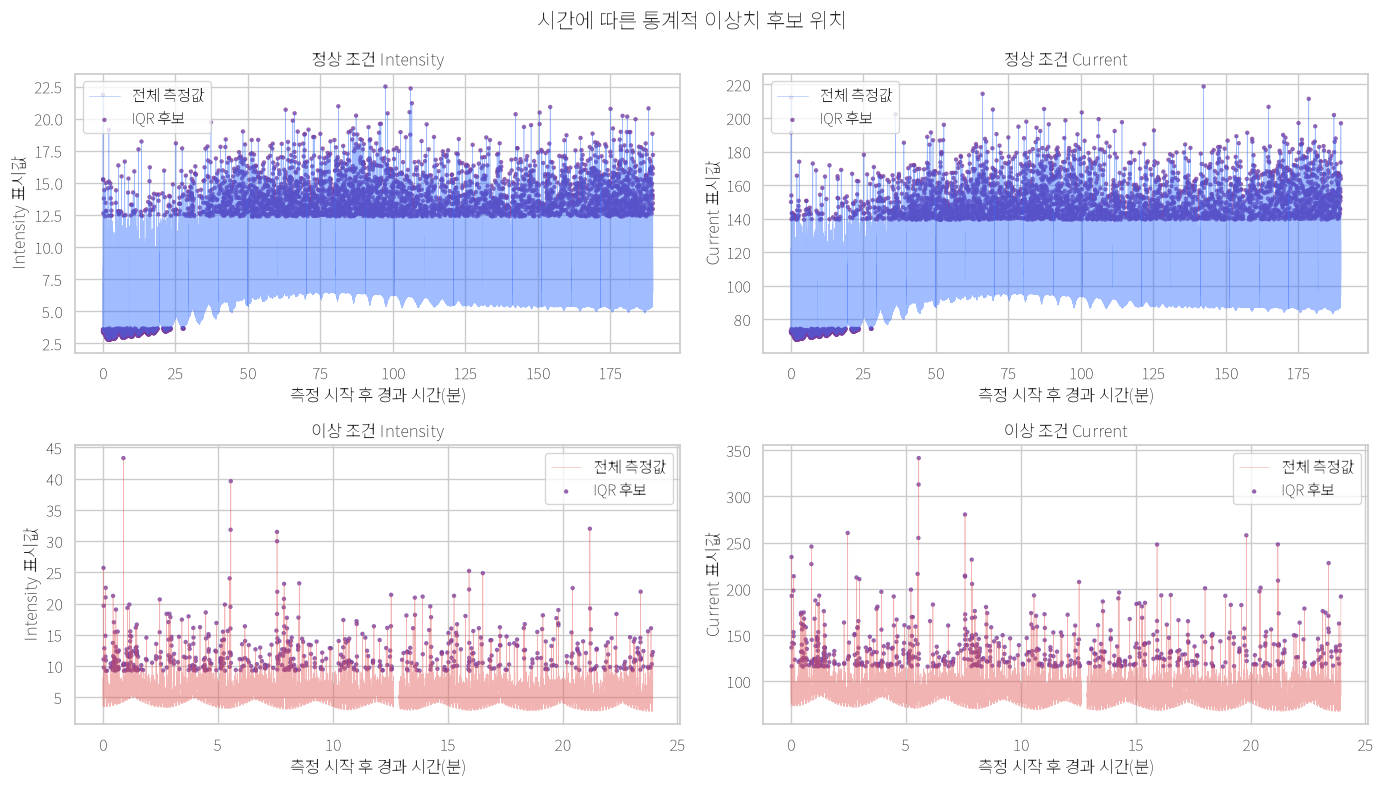

In [35]:
outlier_time_figure, outlier_time_axes = plt.subplots(2, 2, figsize=(14, 8))
candidate_color = "#7A3E9D"

outlier_plot_settings = [
    (normal_outlier_data, "정상", "Intensity", "Intensity 표시값", outlier_time_axes[0, 0]),
    (normal_outlier_data, "정상", "Current", "Current 표시값", outlier_time_axes[0, 1]),
    (anomaly_outlier_data, "이상", "Intensity", "Intensity 표시값", outlier_time_axes[1, 0]),
    (anomaly_outlier_data, "이상", "Current", "Current 표시값", outlier_time_axes[1, 1]),
]

for plot_data, condition_name, sensor_name, display_column, axis in outlier_plot_settings:
    first_segment = True
    for segment_number, segment_data in plot_data.groupby("구간 번호", sort=True):
        axis.plot(
            segment_data["경과 시간(분)"],
            segment_data[display_column],
            color=condition_colors[condition_name],
            alpha=0.45,
            linewidth=0.45,
            label="전체 측정값" if first_segment else None,
            rasterized=True,
        )
        first_segment = False

    candidate_mask = plot_data[f"{sensor_name} IQR 후보"]
    axis.scatter(
        plot_data.loc[candidate_mask, "경과 시간(분)"],
        plot_data.loc[candidate_mask, display_column],
        s=10,
        color=candidate_color,
        alpha=0.8,
        label="IQR 후보",
        edgecolors="none",
        rasterized=True,
    )
    axis.set_title(f"{condition_name} 조건 {sensor_name}")
    axis.set_xlabel("측정 시작 후 경과 시간(분)")
    axis.set_ylabel(f"{sensor_name} 표시값")
    axis.legend()

outlier_time_figure.suptitle("시간에 따른 통계적 이상치 후보 위치", fontsize=15)
outlier_time_figure.tight_layout()
plt.show()

#### 2-11-4. 이상치 후보 계산 검증하기

후보를 표시하는 과정에서 원본 행이 줄지 않았는지, 표의 후보 수와 실제 표시된 후보 수가 같은지, 연속 묶음의 행 수 합도 같은지 확인합니다.

In [36]:
flagged_data_lookup = {
    "정상": normal_outlier_data,
    "이상": anomaly_outlier_data,
}

candidate_count_matches = []
run_count_matches = []
for _, summary_row in iqr_outlier_summary.iterrows():
    condition_name = summary_row["조건"]
    sensor_name = summary_row["센서"]
    flagged_count = int(
        flagged_data_lookup[condition_name][f"{sensor_name} IQR 후보"].sum()
    )
    run_row_count = int(
        candidate_run_summary.loc[
            (candidate_run_summary["조건"] == condition_name)
            & (candidate_run_summary["센서"] == sensor_name),
            "후보_행_수",
        ].iloc[0]
    )
    candidate_count_matches.append(flagged_count == int(summary_row["전체 후보 수"]))
    run_count_matches.append(run_row_count == int(summary_row["전체 후보 수"]))

outlier_validation_checks = [
    ("모든 IQR과 경계가 유한한 숫자임", np.isfinite(iqr_outlier_summary[["IQR", "아래 경계", "위 경계"]].to_numpy()).all()),
    ("모든 아래 경계가 위 경계보다 작음", (iqr_outlier_summary["아래 경계"] < iqr_outlier_summary["위 경계"]).all()),
    ("모든 후보 비율이 0% 이상 100% 이하임", iqr_outlier_summary["후보 비율(%)"].between(0, 100).all()),
    ("정상 후보 표시표의 행 수가 정상 원본과 같음", len(normal_outlier_data) == len(normal_dataset)),
    ("이상 후보 표시표의 행 수가 이상 원본과 같음", len(anomaly_outlier_data) == len(anomaly_dataset)),
    ("IQR 요약표 후보 수와 실제 표시 수가 모두 같음", all(candidate_count_matches)),
    ("연속 묶음의 행 수 합과 IQR 후보 수가 모두 같음", all(run_count_matches)),
    ("후보 위치 그래프가 4개 축으로 구성됨", outlier_time_axes.size == 4),
]

outlier_validation_result = pd.DataFrame(
    outlier_validation_checks,
    columns=["검증 항목", "통과 여부"],
)
display(outlier_validation_result)

if outlier_validation_result["통과 여부"].all():
    print("통계적 이상치 후보 검증 결과: 모든 항목을 통과했습니다.")
else:
    print("통계적 이상치 후보 검증 결과: False인 항목을 추가로 확인해야 합니다.")

,검증 항목,통과 여부
0,모든 IQR과 경계가 유한한 숫자임,True
1,모든 아래 경계가 위 경계보다 작음,True
2,모든 후보 비율이 0% 이상 100% 이하임,True
3,정상 후보 표시표의 행 수가 정상 원본과 같음,True
4,이상 후보 표시표의 행 수가 이상 원본과 같음,True
5,IQR 요약표 후보 수와 실제 표시 수가 모두 같음,True
6,연속 묶음의 행 수 합과 IQR 후보 수가 모두 같음,True
7,후보 위치 그래프가 4개 축으로 구성됨,True


통계적 이상치 후보 검증 결과: 모든 항목을 통과했습니다.


### 이번 단계에서 내릴 수 있는 결론과 아직 모르는 것

- 1초 초과 공백은 값을 만들어 채우지 않고 **새 연속 구간의 시작점**으로 처리합니다.
- 통계적으로 튀는 값도 실제 측정값이므로 이번 EDA에서는 **삭제하지 않고 보존**합니다.
- IQR 후보가 정상 파일에도 있을 수 있고 이상 파일에도 없을 수 있습니다. 파일의 조건 이름과 개별 행의 튀는 정도는 다른 개념입니다.
- 한 번만 튄 후보와 여러 행 이어진 후보를 나누어 두었지만, 현재 데이터만으로 센서 잡음인지 실제 공정 변화인지 확정할 수 없습니다.
- 모델 단계에서는 공백을 넘지 않는 윈도우를 만들고, 스케일링은 정상 학습 구간으로만 맞춰 정보 누출을 막아야 합니다.

다음 단계에서는 EDA에서 확인한 사실을 정리하고, 모델에 넣기 전에 사용할 변수와 파생변수 후보를 하나씩 만들고 검증합니다.

## 3. 전처리 단계

### EDA 완료 확인

지금까지 다음 내용을 확인했습니다.

- 파일, 행, 열의 구조
- 결측치, 중복 행, 중복 시각
- 측정 간격과 1초 초과 공백
- 정상·이상 조건의 기술통계와 분포
- 시간에 따른 센서 변화
- `Intensity`와 `Current`의 관계
- 통계적으로 크게 튀는 값의 위치와 지속시간

이제부터는 관찰하는 EDA를 넘어 모델에 넣을 데이터를 만드는 전처리를 시작합니다. 순서는 `데이터 역할 분리 → 스케일 기준 학습 → 파생변수 검토 → 윈도우 생성`입니다.

가장 먼저 데이터를 나누는 이유는 간단합니다. 스케일링이나 윈도우를 먼저 만들면 미래 데이터의 정보 또는 거의 같은 윈도우가 학습 데이터에 섞일 수 있기 때문입니다.

### 3-1. 학습·검증·평가 데이터 먼저 나누기

이번 프로젝트의 첫 모델은 **정상적인 센서 흐름을 배우는 LSTM 오토인코더**를 기준으로 합니다.

| 데이터 역할 | 쉬운 의미 | 모델에서 하는 일 |
|---|---|---|
| 학습 | 교과서 | 정상적인 움직임을 배움 |
| 검증 | 모의고사 | 학습 설정과 이상 점수 기준을 정할 때 사용 |
| 정상 평가 | 정상 문제 | 정상인데 이상이라고 잘못 판단하는지 확인 |
| 이상 평가 | 이상 문제 | 이상 조건을 실제로 다르게 판단하는지 확인 |

오토인코더 학습에는 정상 데이터만 사용합니다. 이상 데이터까지 학습하면 모델이 이상 움직임도 정상적으로 복원하는 법을 배울 수 있기 때문입니다. 나중에 정상·이상 정답을 직접 맞히는 분류 모델을 만든다면 두 조건을 모두 학습에 사용할 수 있지만, 그것은 별도의 실험입니다.

#### 3-1-1. 정상 연속 구간을 시간순으로 나누기

정상 데이터의 19개 연속 구간을 시간순으로 정렬하여 앞쪽 13개는 학습, 다음 3개는 검증, 마지막 3개는 정상 평가에 사용합니다. 비율은 행 수 기준으로 정확히 70·15·15가 아닐 수 있지만, 연속 구간을 쪼개지 않는 것이 더 중요합니다.

이렇게 하면 하나의 연속 구간이나 그 구간에서 만든 윈도우가 서로 다른 역할에 섞이지 않습니다.

In [37]:
normal_segment_ids = sorted(normal_time_plot_data["구간 번호"].unique())
normal_segment_count = len(normal_segment_ids)

train_segment_count = int(np.floor(normal_segment_count * 0.70))
remaining_segment_count = normal_segment_count - train_segment_count
validation_segment_count = remaining_segment_count // 2

train_segment_ids = normal_segment_ids[:train_segment_count]
validation_segment_ids = normal_segment_ids[
    train_segment_count:train_segment_count + validation_segment_count
]
normal_test_segment_ids = normal_segment_ids[
    train_segment_count + validation_segment_count:
]

segment_role_map = {
    **{segment_id: "학습" for segment_id in train_segment_ids},
    **{segment_id: "검증" for segment_id in validation_segment_ids},
    **{segment_id: "정상 평가" for segment_id in normal_test_segment_ids},
}

normal_split_data = normal_time_plot_data.copy()
normal_split_data["조건"] = "정상"
normal_split_data["데이터 역할"] = normal_split_data["구간 번호"].map(segment_role_map)

anomaly_evaluation_data = anomaly_time_plot_data.copy()
anomaly_evaluation_data["조건"] = "이상"
anomaly_evaluation_data["데이터 역할"] = "이상 평가"

segment_assignment = pd.DataFrame(
    {
        "데이터 역할": ["학습", "검증", "정상 평가"],
        "연속 구간 번호": [
            train_segment_ids,
            validation_segment_ids,
            normal_test_segment_ids,
        ],
        "연속 구간 수": [
            len(train_segment_ids),
            len(validation_segment_ids),
            len(normal_test_segment_ids),
        ],
    }
)
display(segment_assignment)

,데이터 역할,연속 구간 번호,연속 구간 수
0,학습,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]",13
1,검증,"[13, 14, 15]",3
2,정상 평가,"[16, 17, 18]",3


#### 3-1-2. 각 데이터 역할의 크기와 센서 범위 확인하기

분리한 뒤에는 각 부분의 행 수, 시간 범위, 센서값의 평균과 표준편차를 확인합니다. 학습 데이터가 정상 데이터의 한 부분만 지나치게 대표하는지 살펴보기 위한 첫 점검입니다.

시간과 조건 이름은 데이터의 출처와 역할을 확인하는 데만 사용하며 모델 입력 변수로 넣지 않습니다.

In [38]:
split_role_data = pd.concat(
    [normal_split_data, anomaly_evaluation_data],
    ignore_index=True,
)

split_role_order = ["학습", "검증", "정상 평가", "이상 평가"]
split_role_summary = (
    split_role_data.groupby(["조건", "데이터 역할"], sort=False)
    .agg(
        행_수=("Time", "size"),
        연속_구간_수=("구간 번호", "nunique"),
        시작_시각=("Time", "min"),
        종료_시각=("Time", "max"),
        Intensity_평균=("Intensity", "mean"),
        Intensity_표준편차=("Intensity", "std"),
        Current_평균=("Current", "mean"),
        Current_표준편차=("Current", "std"),
    )
    .reset_index()
)
split_role_summary["원래 조건 안에서의 행 비율(%)"] = (
    split_role_summary["행_수"]
    / split_role_summary.groupby("조건")["행_수"].transform("sum")
    * 100
)
split_role_summary["데이터 역할"] = pd.Categorical(
    split_role_summary["데이터 역할"],
    categories=split_role_order,
    ordered=True,
)
split_role_summary = split_role_summary.sort_values("데이터 역할").reset_index(drop=True)

with pd.option_context("display.float_format", "{:.6g}".format):
    display(split_role_summary)

,조건,데이터 역할,행_수,연속_구간_수,시작_시각,종료_시각,Intensity_평균,Intensity_표준편차,Current_평균,Current_표준편차,원래 조건 안에서의 행 비율(%)
0,정상,학습,63715,13,2022-02-03 12:31:51.362,2022-02-03 14:42:51.350,8.12019e-06,2.10742e-06,1.07484e-07,1.56829e-08,69.0453
1,정상,검증,14745,3,2022-02-03 14:43:00.392,2022-02-03 15:13:17.742,8.24224e-06,1.81787e-06,1.0839e-07,1.35148e-08,15.9785
2,정상,정상 평가,13820,3,2022-02-03 15:13:26.953,2022-02-03 15:41:33.384,8.22801e-06,2.02598e-06,1.08287e-07,1.51747e-08,14.9762
3,이상,이상 평가,11800,2,2022-02-04 10:57:33.695,2022-02-04 11:21:29.573,6.11318e-06,2.06803e-06,9.25489e-08,1.53669e-08,100


#### 3-1-3. 시간순 분리 결과를 그래프로 확인하기

아래 그래프의 색은 모델에서의 역할을 뜻합니다. 한 연속 구간이 중간에서 다른 색으로 바뀌면 안 됩니다. 세로로 비어 보이는 부분은 앞서 확인한 1초 초과 공백입니다.

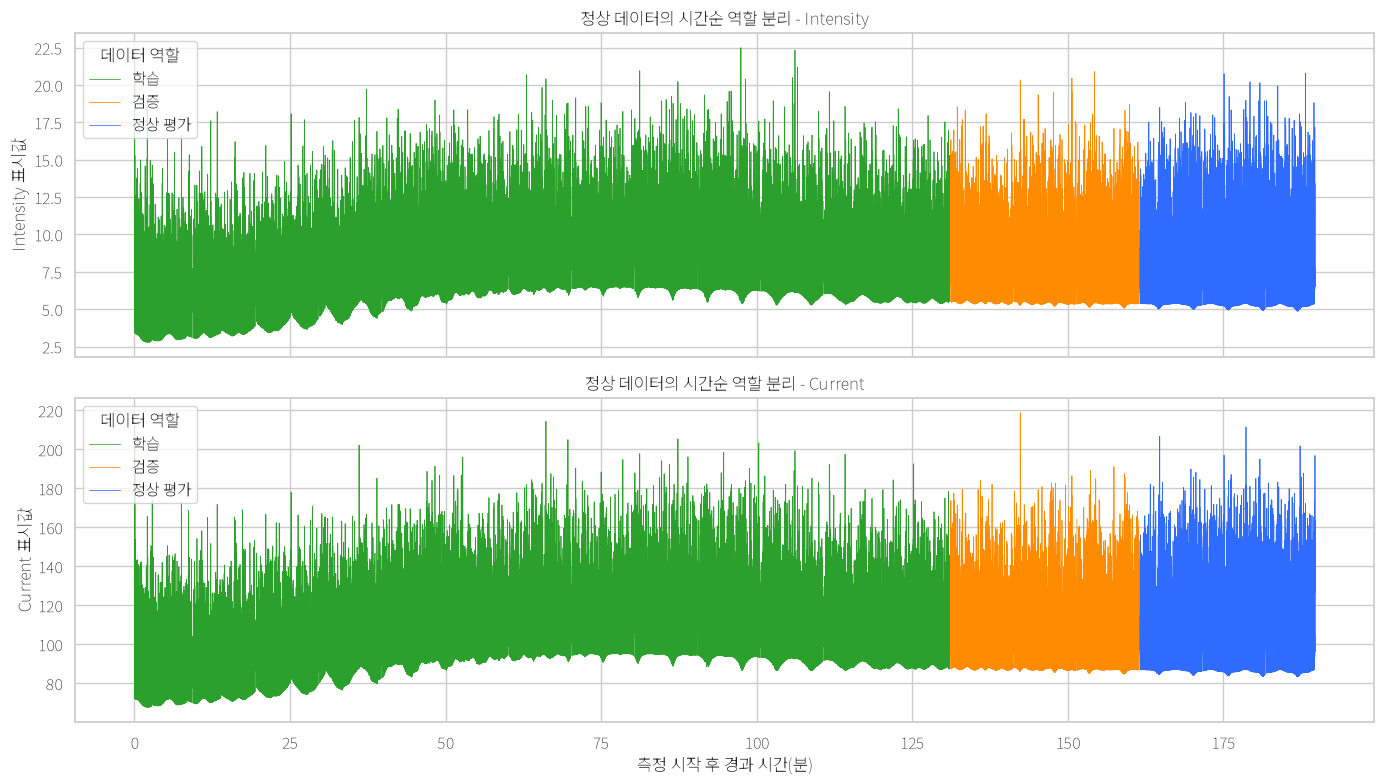

In [39]:
role_colors = {
    "학습": "#2CA02C",
    "검증": "#FF8C00",
    "정상 평가": "#2F6BFF",
}

normal_split_figure, normal_split_axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

for role_name in ["학습", "검증", "정상 평가"]:
    role_data = normal_split_data.loc[
        normal_split_data["데이터 역할"] == role_name
    ]
    first_segment = True
    for segment_number, segment_data in role_data.groupby("구간 번호", sort=True):
        normal_split_axes[0].plot(
            segment_data["경과 시간(분)"],
            segment_data["Intensity 표시값"],
            color=role_colors[role_name],
            linewidth=0.55,
            label=role_name if first_segment else None,
            rasterized=True,
        )
        normal_split_axes[1].plot(
            segment_data["경과 시간(분)"],
            segment_data["Current 표시값"],
            color=role_colors[role_name],
            linewidth=0.55,
            label=role_name if first_segment else None,
            rasterized=True,
        )
        first_segment = False

normal_split_axes[0].set_title("정상 데이터의 시간순 역할 분리 - Intensity")
normal_split_axes[1].set_title("정상 데이터의 시간순 역할 분리 - Current")
normal_split_axes[0].set_ylabel("Intensity 표시값")
normal_split_axes[1].set_ylabel("Current 표시값")
normal_split_axes[1].set_xlabel("측정 시작 후 경과 시간(분)")

for axis in normal_split_axes:
    axis.legend(title="데이터 역할")

normal_split_figure.tight_layout()
plt.show()

#### 3-1-4. 데이터 누출과 행 손실 검증하기

다음 항목을 확인합니다.

- 정상 데이터의 모든 행이 정확히 한 역할에 들어갔는가?
- 하나의 연속 구간이 두 역할에 걸쳐 있지 않은가?
- 학습, 검증, 정상 평가가 실제 시간순인가?
- 이상 데이터가 학습이나 검증에 들어가지 않았는가?
- 현재 모델 입력 후보는 두 센서뿐이며 시간과 조건 이름이 제외되었는가?

In [40]:
base_feature_columns = ["Intensity", "Current"]

normal_role_counts_per_segment = (
    normal_split_data.groupby("구간 번호")["데이터 역할"].nunique()
)

train_data = normal_split_data.loc[normal_split_data["데이터 역할"] == "학습"].copy()
validation_data = normal_split_data.loc[normal_split_data["데이터 역할"] == "검증"].copy()
normal_test_data = normal_split_data.loc[normal_split_data["데이터 역할"] == "정상 평가"].copy()
anomaly_test_data = anomaly_evaluation_data.copy()

split_validation_checks = [
    ("정상 데이터의 모든 행이 하나의 역할을 가짐", normal_split_data["데이터 역할"].notna().all()),
    ("분리한 정상 행 수의 합이 정상 원본과 같음", len(train_data) + len(validation_data) + len(normal_test_data) == len(normal_dataset)),
    ("각 정상 연속 구간이 정확히 한 역할에만 들어감", (normal_role_counts_per_segment == 1).all()),
    ("정상 연속 구간 수가 13개 학습, 3개 검증, 3개 평가로 나뉨", len(train_segment_ids) == 13 and len(validation_segment_ids) == 3 and len(normal_test_segment_ids) == 3),
    ("학습 종료 시각이 검증 시작 시각보다 앞섬", train_data["Time"].max() < validation_data["Time"].min()),
    ("검증 종료 시각이 정상 평가 시작 시각보다 앞섬", validation_data["Time"].max() < normal_test_data["Time"].min()),
    ("이상 데이터 전체가 이상 평가 역할임", anomaly_test_data["데이터 역할"].eq("이상 평가").all() and len(anomaly_test_data) == len(anomaly_dataset)),
    ("기본 모델 입력 후보가 두 센서이고 시간과 조건 이름을 포함하지 않음", base_feature_columns == ["Intensity", "Current"] and "Time" not in base_feature_columns and "조건" not in base_feature_columns),
    ("시간순 분리 그래프가 두 개 축으로 구성됨", len(normal_split_axes) == 2),
]

split_validation_result = pd.DataFrame(
    split_validation_checks,
    columns=["검증 항목", "통과 여부"],
)
display(split_validation_result)

if split_validation_result["통과 여부"].all():
    print("데이터 역할 분리 검증 결과: 모든 항목을 통과했습니다.")
else:
    print("데이터 역할 분리 검증 결과: False인 항목을 추가로 확인해야 합니다.")

,검증 항목,통과 여부
0,정상 데이터의 모든 행이 하나의 역할을 가짐,True
1,분리한 정상 행 수의 합이 정상 원본과 같음,True
2,각 정상 연속 구간이 정확히 한 역할에만 들어감,True
3,"정상 연속 구간 수가 13개 학습, 3개 검증, 3개 평가로 나뉨",True
4,학습 종료 시각이 검증 시작 시각보다 앞섬,True
5,검증 종료 시각이 정상 평가 시작 시각보다 앞섬,True
6,이상 데이터 전체가 이상 평가 역할임,True
7,기본 모델 입력 후보가 두 센서이고 시간과 조건 이름을 포함하지 않음,True
8,시간순 분리 그래프가 두 개 축으로 구성됨,True


데이터 역할 분리 검증 결과: 모든 항목을 통과했습니다.


### 이번 단계의 결론

- EDA는 완료했고 모델용 전처리를 시작했습니다.
- 정상 연속 구간 19개를 시간순으로 `학습 13개`, `검증 3개`, `정상 평가 3개`로 분리했습니다.
- 이상 조건의 2개 연속 구간은 오토인코더를 학습시키지 않고 최종 이상 평가에 사용합니다.
- 아직 스케일링과 윈도우 생성은 하지 않았습니다. 데이터를 먼저 분리했기 때문에 이후 계산에서 미래 정보가 학습 과정에 섞이는 위험을 줄였습니다.
- 다음 단계에서는 학습용 정상 데이터만 사용해 스케일 기준을 정하고, 검증·평가 데이터에는 같은 기준을 적용합니다.

### 3-2. 센서값의 크기 맞추기

`Intensity`와 `Current`는 값의 단위와 크기가 다릅니다. 모델은 숫자가 큰 변수를 더 중요하다고 오해할 수 있으므로 두 센서가 비슷한 기준에서 학습되도록 숫자의 크기를 맞춥니다. 이 과정을 **스케일링**이라고 합니다.

스케일링은 센서 신호의 오르내리는 모양을 없애는 작업이 아닙니다. 자의 눈금을 바꾸는 것과 같습니다.

가이드북은 `Intensity` 한 변수에 `StandardScaler`를 사용했습니다. 여기서는 앞의 상관분석에서 두 센서가 완전히 같은 정보를 갖지 않는다는 점을 확인했으므로 `Intensity`와 `Current`를 각각 표준화합니다. 또한 크게 튀는 값이 있어 `RobustScaler`와 결과도 비교합니다.

#### 3-2-1. 학습 데이터에서만 기준을 계산하는 이유

`StandardScaler`는 학습 데이터의 평균과 표준편차를 구한 뒤 다음과 같이 값을 바꿉니다.

```text
표준화된 값 = (원래 값 - 학습 데이터 평균) ÷ 학습 데이터 표준편차
```

검증·평가 데이터의 평균이나 표준편차를 미리 사용하면 시험문제 정보를 보고 공부하는 것과 같습니다. 따라서 `fit`은 학습용 정상 데이터에만 한 번 수행하고, 나머지 데이터에는 같은 기준으로 `transform`만 수행합니다.

In [41]:
from sklearn.preprocessing import RobustScaler, StandardScaler


raw_role_data = {
    "학습": train_data,
    "검증": validation_data,
    "정상 평가": normal_test_data,
    "이상 평가": anomaly_test_data,
}

standard_scaler = StandardScaler()
standard_scaler.fit(train_data[base_feature_columns])


def apply_scaler(dataframe, scaler, suffix="표준화값"):
    scaled_values = scaler.transform(dataframe[base_feature_columns])
    scaled_data = dataframe.copy()
    for column_number, sensor_name in enumerate(base_feature_columns):
        scaled_data[f"{sensor_name} {suffix}"] = scaled_values[:, column_number]
    return scaled_data


standard_scaled_role_data = {
    role_name: apply_scaler(role_data, standard_scaler, "표준화값")
    for role_name, role_data in raw_role_data.items()
}

train_scaled_data = standard_scaled_role_data["학습"]
validation_scaled_data = standard_scaled_role_data["검증"]
normal_test_scaled_data = standard_scaled_role_data["정상 평가"]
anomaly_test_scaled_data = standard_scaled_role_data["이상 평가"]

standard_scaler_reference = pd.DataFrame(
    {
        "센서": base_feature_columns,
        "학습 데이터 평균": standard_scaler.mean_,
        "학습 데이터 표준편차": standard_scaler.scale_,
    }
)

with pd.option_context("display.float_format", "{:.8g}".format):
    display(standard_scaler_reference)

,센서,학습 데이터 평균,학습 데이터 표준편차
0,Intensity,8.1201897e-06,2.1074016e-06
1,Current,1.0748364e-07,1.5682786e-08


#### 3-2-2. 표준화 후 각 데이터의 위치 확인하기

학습 데이터로 기준을 만들었으므로 학습 데이터의 표준화 평균은 거의 0, 표준편차는 거의 1이 됩니다. 검증·평가 데이터는 억지로 0과 1에 맞추지 않습니다. 학습 데이터와 실제로 얼마나 다른지를 그대로 남겨야 하기 때문입니다.

표준화값 `0`은 학습 정상 평균과 비슷하다는 뜻이고, `1`은 학습 정상 평균보다 표준편차 한 칸만큼 크다는 뜻입니다.

In [42]:
standard_scaled_columns = [
    f"{sensor_name} 표준화값" for sensor_name in base_feature_columns
]

standard_scale_summary_rows = []
for role_name, scaled_data in standard_scaled_role_data.items():
    for sensor_name, scaled_column in zip(base_feature_columns, standard_scaled_columns):
        values = scaled_data[scaled_column]
        standard_scale_summary_rows.append(
            {
                "데이터 역할": role_name,
                "센서": sensor_name,
                "행 수": len(values),
                "평균": values.mean(),
                "표준편차(ddof=0)": values.std(ddof=0),
                "중앙값": values.median(),
                "최솟값": values.min(),
                "최댓값": values.max(),
                "절댓값 3 초과 비율(%)": (values.abs() > 3).mean() * 100,
            }
        )

standard_scale_summary = pd.DataFrame(standard_scale_summary_rows)
standard_scale_summary["데이터 역할"] = pd.Categorical(
    standard_scale_summary["데이터 역할"],
    categories=split_role_order,
    ordered=True,
)
standard_scale_summary = standard_scale_summary.sort_values(
    ["데이터 역할", "센서"]
).reset_index(drop=True)

with pd.option_context("display.float_format", "{:.4f}".format):
    display(standard_scale_summary)

,데이터 역할,센서,행 수,평균,표준편차(ddof=0),중앙값,최솟값,최댓값,절댓값 3 초과 비율(%)
0,학습,Current,63715,0.0000,1.0000,-0.0733,-2.5362,6.8192,1.0955
1,학습,Intensity,63715,-0.0000,1.0000,-0.0734,-2.5330,6.8244,1.1238
2,검증,Current,14745,0.0578,0.8617,-0.1637,-1.4501,7.0975,1.2411
3,검증,Intensity,14745,0.0579,0.8626,-0.1649,-1.4554,6.0663,1.1868
4,정상 평가,Current,13820,0.0512,0.9676,-0.2272,-1.5423,6.6294,2.1346
5,정상 평가,Intensity,13820,0.0512,0.9613,-0.2240,-1.5463,6.0156,2.0912
6,이상 평가,Current,11800,-0.9523,0.9798,-1.1346,-2.5572,14.9194,0.9661
7,이상 평가,Intensity,11800,-0.9524,0.9813,-1.1345,-2.5618,16.6951,0.9661


#### 3-2-3. 튀는 값에 덜 흔들리는 방법과 비교하기

`RobustScaler`는 평균과 표준편차 대신 중앙값과 가운데 50%의 폭인 IQR을 사용합니다.

```text
강건 스케일값 = (원래 값 - 학습 데이터 중앙값) ÷ 학습 데이터 IQR
```

튀는 값이 평균과 표준편차를 크게 움직이는 문제를 줄일 수 있지만, 바깥쪽 값이 변환 후 더 크게 보일 수도 있습니다. 두 스케일러를 같은 학습 데이터에 맞춰 비교한 뒤 첫 모델은 가이드북과 동일한 `StandardScaler`를 기준으로 사용하고, 모델 성능 비교 단계에서 `RobustScaler`도 후보로 남깁니다.

In [43]:
robust_scaler = RobustScaler()
robust_scaler.fit(train_data[base_feature_columns])

robust_scaled_role_data = {
    role_name: apply_scaler(role_data, robust_scaler, "강건 스케일값")
    for role_name, role_data in raw_role_data.items()
}


def make_scaler_comparison_rows(scaler_name, scaled_lookup, column_suffix):
    rows = []
    for role_name, scaled_data in scaled_lookup.items():
        for sensor_name in base_feature_columns:
            values = scaled_data[f"{sensor_name} {column_suffix}"]
            q1 = values.quantile(0.25)
            q3 = values.quantile(0.75)
            rows.append(
                {
                    "스케일러": scaler_name,
                    "데이터 역할": role_name,
                    "센서": sensor_name,
                    "중앙값": values.median(),
                    "가운데 50% 폭(IQR)": q3 - q1,
                    "최솟값": values.min(),
                    "최댓값": values.max(),
                }
            )
    return rows


scaler_comparison = pd.DataFrame(
    make_scaler_comparison_rows(
        "StandardScaler", standard_scaled_role_data, "표준화값"
    )
    + make_scaler_comparison_rows(
        "RobustScaler", robust_scaled_role_data, "강건 스케일값"
    )
)
scaler_comparison["데이터 역할"] = pd.Categorical(
    scaler_comparison["데이터 역할"],
    categories=split_role_order,
    ordered=True,
)
scaler_comparison = scaler_comparison.sort_values(
    ["데이터 역할", "센서", "스케일러"]
).reset_index(drop=True)

with pd.option_context("display.float_format", "{:.4f}".format):
    display(scaler_comparison)

,스케일러,데이터 역할,센서,중앙값,가운데 50% 폭(IQR),최솟값,최댓값
0,RobustScaler,학습,Current,0.0000,1.0000,-2.2344,6.2529
1,StandardScaler,학습,Current,-0.0733,1.1023,-2.5362,6.8192
2,RobustScaler,학습,Intensity,0.0000,1.0000,-2.2280,6.2483
3,StandardScaler,학습,Intensity,-0.0734,1.1039,-2.5330,6.8244
4,RobustScaler,검증,Current,-0.0820,0.8339,-1.2491,6.5054
5,StandardScaler,검증,Current,-0.1637,0.9193,-1.4501,7.0975
6,RobustScaler,검증,Intensity,-0.0829,0.8261,-1.2518,5.5616
7,StandardScaler,검증,Intensity,-0.1649,0.9120,-1.4554,6.0663
8,RobustScaler,정상 평가,Current,-0.1397,0.8525,-1.3328,6.0807
9,StandardScaler,정상 평가,Current,-0.2272,0.9397,-1.5423,6.6294


#### 3-2-4. 스케일링 전후의 신호 모양 확인하기

학습 데이터의 첫 200행을 이용해 원래 값과 표준화값을 비교합니다. 세로축 숫자는 바뀌지만 봉우리와 하강 위치는 그대로여야 합니다.

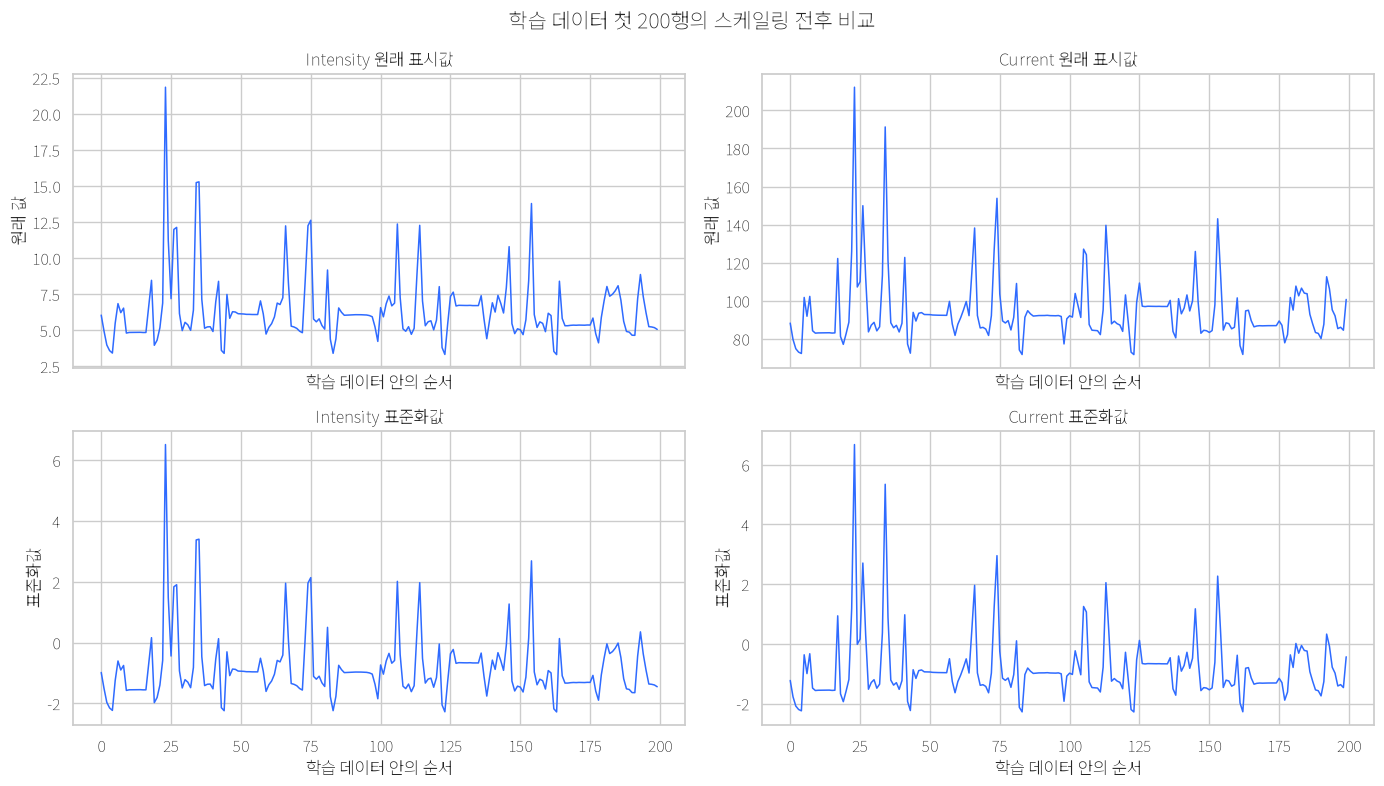

In [44]:
scaling_example_rows = 200
scaling_example_raw = train_data.iloc[:scaling_example_rows]
scaling_example_standard = train_scaled_data.iloc[:scaling_example_rows]

scaling_figure, scaling_axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True)

scaling_plot_settings = [
    (scaling_axes[0, 0], scaling_example_raw["Intensity"] * 1_000_000, "Intensity 원래 표시값", "원래 값"),
    (scaling_axes[0, 1], scaling_example_raw["Current"] * 1_000_000_000, "Current 원래 표시값", "원래 값"),
    (scaling_axes[1, 0], scaling_example_standard["Intensity 표준화값"], "Intensity 표준화값", "표준화값"),
    (scaling_axes[1, 1], scaling_example_standard["Current 표준화값"], "Current 표준화값", "표준화값"),
]

for axis, values, title, y_label in scaling_plot_settings:
    axis.plot(
        np.arange(len(values)),
        values.to_numpy(),
        color="#2F6BFF",
        linewidth=1.1,
    )
    axis.set_title(title)
    axis.set_ylabel(y_label)
    axis.set_xlabel("학습 데이터 안의 순서")

scaling_figure.suptitle("학습 데이터 첫 200행의 스케일링 전후 비교", fontsize=15)
scaling_figure.tight_layout()
plt.show()

#### 3-2-5. 스케일링 계산 검증하기

학습 데이터만으로 평균과 표준편차를 계산했는지, 변환 과정에서 행이나 시간 순서가 바뀌지 않았는지, 표준화값을 다시 원래 단위로 복원할 수 있는지 확인합니다.

In [45]:
inverse_example = standard_scaler.inverse_transform(
    train_scaled_data[standard_scaled_columns].iloc[:1000]
)

all_standard_values_finite = all(
    np.isfinite(scaled_data[standard_scaled_columns].to_numpy()).all()
    for scaled_data in standard_scaled_role_data.values()
)

scaling_validation_checks = [
    ("StandardScaler 평균 기준이 학습 원본 평균과 같음", np.allclose(standard_scaler.mean_, train_data[base_feature_columns].mean().to_numpy())),
    ("StandardScaler 표준편차 기준이 학습 원본의 모집단 표준편차와 같음", np.allclose(standard_scaler.scale_, train_data[base_feature_columns].std(ddof=0).to_numpy())),
    ("표준화된 학습 데이터의 두 센서 평균이 거의 0임", np.allclose(train_scaled_data[standard_scaled_columns].mean().to_numpy(), 0, atol=1e-10)),
    ("표준화된 학습 데이터의 두 센서 표준편차가 거의 1임", np.allclose(train_scaled_data[standard_scaled_columns].std(ddof=0).to_numpy(), 1, atol=1e-10)),
    ("네 데이터 역할 모두 스케일링 전후 행 수가 같음", all(len(raw_role_data[role_name]) == len(standard_scaled_role_data[role_name]) for role_name in raw_role_data)),
    ("네 데이터 역할의 모든 표준화값이 유한함", all_standard_values_finite),
    ("스케일링 전후 시간 순서와 구간 번호가 그대로임", all(raw_role_data[role_name][["Time", "구간 번호"]].reset_index(drop=True).equals(standard_scaled_role_data[role_name][["Time", "구간 번호"]].reset_index(drop=True)) for role_name in raw_role_data)),
    ("표준화값을 원래 단위로 되돌리면 원본과 같음", np.allclose(inverse_example, train_data[base_feature_columns].iloc[:1000].to_numpy())),
    ("스케일링 전후 비교 그래프가 4개 축으로 구성됨", scaling_axes.size == 4),
]

scaling_validation_result = pd.DataFrame(
    scaling_validation_checks,
    columns=["검증 항목", "통과 여부"],
)
display(scaling_validation_result)

if scaling_validation_result["통과 여부"].all():
    print("스케일링 검증 결과: 모든 항목을 통과했습니다.")
else:
    print("스케일링 검증 결과: False인 항목을 추가로 확인해야 합니다.")

,검증 항목,통과 여부
0,StandardScaler 평균 기준이 학습 원본 평균과 같음,True
1,StandardScaler 표준편차 기준이 학습 원본의 모집단 표준편차와 같음,True
2,표준화된 학습 데이터의 두 센서 평균이 거의 0임,True
3,표준화된 학습 데이터의 두 센서 표준편차가 거의 1임,True
4,네 데이터 역할 모두 스케일링 전후 행 수가 같음,True
5,네 데이터 역할의 모든 표준화값이 유한함,True
6,스케일링 전후 시간 순서와 구간 번호가 그대로임,True
7,표준화값을 원래 단위로 되돌리면 원본과 같음,True
8,스케일링 전후 비교 그래프가 4개 축으로 구성됨,True


스케일링 검증 결과: 모든 항목을 통과했습니다.


### 스케일링 단계의 결론

- 첫 오토인코더는 가이드북과 비교할 수 있도록 `StandardScaler`를 기본값으로 사용합니다.
- `Intensity`와 `Current`는 각각 자신의 학습 평균과 표준편차로 변환했습니다.
- 검증·정상 평가·이상 평가 데이터에는 학습 데이터에서 구한 동일한 기준만 적용했습니다.
- 원본 센서 열은 덮어쓰지 않고 `표준화값` 열을 새로 만들어 전후 값을 비교할 수 있게 했습니다.
- `RobustScaler` 결과도 저장해 두었으며, 모델 비교 단계에서 튀는 값에 대한 민감도 차이를 확인할 수 있습니다.

다음 단계에서는 원본 두 센서 외에 변화량, 두 센서의 관계, 짧은 구간의 통계처럼 의미가 분명한 파생변수 후보를 만들고 정상·이상 구분에 도움이 되는지 검증합니다.

### 3-3. 시간 흐름을 설명하는 파생변수 후보 만들기

현재 기본 변수는 같은 시점의 `Intensity 표준화값`과 `Current 표준화값` 두 개입니다. 이 값들은 센서의 현재 높이를 알려 주지만, 얼마나 빠르게 변하는지 또는 최근에 얼마나 흔들렸는지를 직접 나타내지는 않습니다.

파생변수는 원래 센서값을 이용해 새로 계산한 설명용 숫자입니다. 원본을 대체하지 않고 후보 열로 추가합니다. 후보가 많다고 무조건 좋은 것은 아니므로 계산 뒤에 의미와 중복 정도를 확인합니다.

#### 3-3-1. 이번에 확인할 파생변수

| 파생변수 | 계산 방법 | 쉬운 의미 |
|---|---|---|
| 1행 변화량 | 현재 표준화값 - 바로 앞 표준화값 | 한 번 측정하는 동안 얼마나 변했는가 |
| 초당 변화량 | 1행 변화량 ÷ 실제 시간 간격 | 1초 기준으로 얼마나 빠르게 변했는가 |
| 두 센서 공통 수준 | 두 센서 표준화값의 평균 | 두 센서가 함께 높거나 낮은 정도 |
| 두 센서 표준화 차이 | Intensity 표준화값 - Current 표준화값 | 두 센서가 서로 벌어진 정도 |
| 최근 8행 변동성 | 현재까지 최근 8행의 표준편차 | 약 1초 동안 얼마나 흔들렸는가 |

모든 시간 계산은 같은 연속 구간 안에서만 수행합니다. 새 구간의 첫 행은 비교할 앞 행이 없으므로 변화량과 변화속도를 `0`으로 표시합니다. 최근 8행 변동성도 첫 행은 비교 대상이 하나뿐이므로 `0`입니다.

In [46]:
local_variability_rows = 8


def add_time_derived_features(scaled_data):
    feature_data = scaled_data.copy()
    intensity_scaled = "Intensity 표준화값"
    current_scaled = "Current 표준화값"

    time_step_seconds = feature_data.groupby("구간 번호")["Time"].diff().dt.total_seconds()
    intensity_change = feature_data.groupby("구간 번호")[intensity_scaled].diff()
    current_change = feature_data.groupby("구간 번호")[current_scaled].diff()

    feature_data["측정 간격(초)"] = time_step_seconds.fillna(0)
    feature_data["Intensity 1행 변화량"] = intensity_change.fillna(0)
    feature_data["Current 1행 변화량"] = current_change.fillna(0)
    feature_data["Intensity 초당 변화량"] = (
        intensity_change / time_step_seconds
    ).fillna(0)
    feature_data["Current 초당 변화량"] = (
        current_change / time_step_seconds
    ).fillna(0)
    feature_data["두 센서 공통 수준"] = (
        feature_data[intensity_scaled] + feature_data[current_scaled]
    ) / 2
    feature_data["두 센서 표준화 차이"] = (
        feature_data[intensity_scaled] - feature_data[current_scaled]
    )

    for sensor_name, scaled_column in [
        ("Intensity", intensity_scaled),
        ("Current", current_scaled),
    ]:
        feature_data[f"{sensor_name} 최근 8행 변동성"] = (
            feature_data.groupby("구간 번호")[scaled_column]
            .transform(
                lambda values: values.rolling(
                    local_variability_rows,
                    min_periods=2,
                ).std(ddof=0)
            )
            .fillna(0)
        )

    return feature_data


derived_role_data = {
    role_name: add_time_derived_features(scaled_data)
    for role_name, scaled_data in standard_scaled_role_data.items()
}

train_feature_data = derived_role_data["학습"]
validation_feature_data = derived_role_data["검증"]
normal_test_feature_data = derived_role_data["정상 평가"]
anomaly_test_feature_data = derived_role_data["이상 평가"]

derived_feature_columns = [
    "Intensity 1행 변화량",
    "Current 1행 변화량",
    "Intensity 초당 변화량",
    "Current 초당 변화량",
    "두 센서 공통 수준",
    "두 센서 표준화 차이",
    "Intensity 최근 8행 변동성",
    "Current 최근 8행 변동성",
]

display(train_feature_data[["Time", "구간 번호"] + standard_scaled_columns + derived_feature_columns].head(10))

열 이름,Time,구간 번호,Intensity 표준화값,Current 표준화값,Intensity 1행 변화량,Current 1행 변화량,Intensity 초당 변화량,Current 초당 변화량,두 센서 공통 수준,두 센서 표준화 차이,Intensity 최근 8행 변동성,Current 최근 8행 변동성
0,2022-02-03 12:31:51.362,0,-0.984141,-1.227370,0.000000,0.000000,0.000000,0.000000,-1.105756,0.243229,0.000000,0.000000
1,2022-02-03 12:31:51.483,0,-1.508492,-1.774317,-0.524350,-0.546946,-4.333475,-4.520218,-1.641404,0.265825,0.262175,0.273473
2,2022-02-03 12:31:51.604,0,-1.967034,-2.085424,-0.458542,-0.311107,-3.789607,-2.571133,-2.026229,0.118390,0.401564,0.354682
3,2022-02-03 12:31:51.724,0,-2.152439,-2.199526,-0.185404,-0.114102,-1.545037,-0.950854,-2.175983,0.047088,0.451750,0.376755
4,2022-02-03 12:31:51.858,0,-2.232560,-2.245052,-0.080121,-0.045526,-0.597919,-0.339743,-2.238806,0.012492,0.465832,0.377143
5,2022-02-03 12:31:51.979,0,-1.251452,-0.367600,0.981108,1.877452,8.108330,15.516132,-0.809526,-0.883852,0.466932,0.668865
6,2022-02-03 12:31:52.099,0,-0.606168,-0.997600,0.645284,-0.630000,5.377370,-5.250004,-0.801884,0.391433,0.573397,0.659975
7,2022-02-03 12:31:52.219,0,-0.902819,-0.332215,-0.296652,0.665386,-2.472098,5.544882,-0.617517,-0.570605,0.574942,0.738318
8,2022-02-03 12:31:52.339,0,-0.753826,-1.482789,0.148993,-1.150574,1.241612,-9.588117,-1.118307,0.728963,0.602678,0.735523
9,2022-02-03 12:31:52.459,0,-1.574727,-1.563997,-0.820901,-0.081209,-6.840842,-0.676738,-1.569362,-0.010730,0.604264,0.726650


#### 3-3-2. 역할별 파생변수 범위 확인하기

평균만 보면 큰 값 몇 개에 끌릴 수 있으므로 중앙값, 가운데 50%의 폭, 절댓값 상위 1% 경계도 함께 봅니다. 이 표는 파생변수의 단위가 지나치게 크거나 계산이 불안정하지 않은지 확인하기 위한 것입니다.

In [47]:
derived_summary_rows = []
for role_name, feature_data in derived_role_data.items():
    for feature_name in derived_feature_columns:
        values = feature_data[feature_name]
        q1 = values.quantile(0.25)
        q3 = values.quantile(0.75)
        derived_summary_rows.append(
            {
                "데이터 역할": role_name,
                "파생변수": feature_name,
                "평균": values.mean(),
                "표준편차": values.std(ddof=0),
                "중앙값": values.median(),
                "가운데 50% 폭(IQR)": q3 - q1,
                "절댓값 99% 경계": values.abs().quantile(0.99),
                "최솟값": values.min(),
                "최댓값": values.max(),
            }
        )

derived_feature_summary = pd.DataFrame(derived_summary_rows)
derived_feature_summary["데이터 역할"] = pd.Categorical(
    derived_feature_summary["데이터 역할"],
    categories=split_role_order,
    ordered=True,
)
derived_feature_summary = derived_feature_summary.sort_values(
    ["데이터 역할", "파생변수"]
).reset_index(drop=True)

with pd.option_context("display.float_format", "{:.4f}".format):
    display(derived_feature_summary)

,데이터 역할,파생변수,평균,표준편차,중앙값,가운데 50% 폭(IQR),절댓값 99% 경계,최솟값,최댓값
0,학습,Current 1행 변화량,-0.0000,0.9131,-0.0018,0.4967,3.0133,-6.6940,6.1557
1,학습,Current 초당 변화량,-0.0024,7.5604,-0.0149,4.0930,25.0778,-56.2519,51.2975
2,학습,Current 최근 8행 변동성,0.6582,0.3729,0.6715,0.4749,1.6244,0.0000,2.7316
3,학습,Intensity 1행 변화량,-0.0000,0.9136,-0.0019,0.5002,3.0186,-6.4339,7.3166
4,학습,Intensity 초당 변화량,-0.0038,7.5634,-0.0159,4.1228,25.1193,-53.1724,60.9714
5,학습,Intensity 최근 8행 변동성,0.6580,0.3736,0.6724,0.4783,1.6211,0.0000,2.6474
6,학습,두 센서 공통 수준,0.0000,0.9618,-0.0631,1.0780,2.8908,-2.5343,6.5966
7,학습,두 센서 표준화 차이,-0.0000,0.5477,0.0012,0.2521,1.9080,-4.8236,5.2276
8,검증,Current 1행 변화량,-0.0004,0.9398,-0.0018,0.4949,3.1151,-6.1926,6.3557
9,검증,Current 초당 변화량,-0.0103,7.7962,-0.0141,4.0635,25.9234,-51.1784,52.9645


#### 3-3-3. 서로 같은 정보를 반복하는 후보 찾기

상관계수의 절댓값이 0.95 이상이면 두 후보가 거의 같은 방향으로 움직일 가능성이 큽니다. 이런 변수들을 모두 넣으면 모델이 같은 정보를 여러 번 보게 될 수 있으므로 후보를 줄일 때 참고합니다.

상관이 높다는 이유만으로 자동 삭제하지는 않습니다. 계산식과 공정 의미를 함께 확인합니다.

In [48]:
all_feature_candidate_columns = standard_scaled_columns + derived_feature_columns
train_feature_correlation = train_feature_data[all_feature_candidate_columns].corr()

high_correlation_pairs = []
for left_position, left_feature in enumerate(all_feature_candidate_columns):
    for right_position in range(left_position + 1, len(all_feature_candidate_columns)):
        right_feature = all_feature_candidate_columns[right_position]
        correlation_value = train_feature_correlation.loc[left_feature, right_feature]
        if abs(correlation_value) >= 0.95:
            high_correlation_pairs.append(
                {
                    "변수 1": left_feature,
                    "변수 2": right_feature,
                    "상관계수": correlation_value,
                }
            )

high_correlation_summary = pd.DataFrame(
    high_correlation_pairs,
    columns=["변수 1", "변수 2", "상관계수"],
).sort_values("상관계수", key=lambda values: values.abs(), ascending=False)

with pd.option_context("display.float_format", "{:.4f}".format):
    display(high_correlation_summary)

,변수 1,변수 2,상관계수
3,Current 1행 변화량,Current 초당 변화량,0.9966
2,Intensity 1행 변화량,Intensity 초당 변화량,0.9964
0,Intensity 표준화값,두 센서 공통 수준,0.9618
1,Current 표준화값,두 센서 공통 수준,0.9618


#### 후보를 기본 입력과 진단용으로 나누기

- `두 센서 공통 수준`과 `두 센서 표준화 차이`는 두 원래 표준화값을 더하거나 뺀 값이므로 새로운 원천 정보는 아닙니다. 두 센서 관계를 설명하는 진단용으로 남깁니다.
- `초당 변화량`은 측정 간격이 거의 일정하면 1행 변화량과 매우 비슷한 정보를 가질 수 있습니다. 높은 상관이 확인되면 둘 중 하나만 모델 후보로 사용합니다.
- 최근 8행 변동성은 현재와 과거 값만 이용해 약 1초의 흔들림을 요약합니다.

첫 모델은 원래 표준화 센서 두 개를 사용하는 **기본 입력**으로 시작합니다. 파생변수 모델은 변화량과 최근 변동성을 추가하여 같은 검증 데이터에서 실제 도움이 되는지 비교합니다.

In [49]:
baseline_sequence_feature_columns = [
    "Intensity 표준화값",
    "Current 표준화값",
]

enhanced_sequence_feature_columns = baseline_sequence_feature_columns + [
    "Intensity 1행 변화량",
    "Current 1행 변화량",
    "Intensity 최근 8행 변동성",
    "Current 최근 8행 변동성",
]

diagnostic_only_feature_columns = [
    "Intensity 초당 변화량",
    "Current 초당 변화량",
    "두 센서 공통 수준",
    "두 센서 표준화 차이",
]

feature_plan = pd.DataFrame(
    {
        "구분": ["기본 모델 입력", "파생변수 비교 모델 입력", "진단용 후보"],
        "변수": [
            baseline_sequence_feature_columns,
            enhanced_sequence_feature_columns,
            diagnostic_only_feature_columns,
        ],
        "사용 목적": [
            "가이드북보다 센서 하나를 추가한 가장 단순한 기준 모델",
            "변화와 최근 흔들림이 검증 성능을 높이는지 확인",
            "센서 관계와 중복 정도를 설명하되 첫 모델에는 넣지 않음",
        ],
    }
)
display(feature_plan)

,구분,변수,사용 목적
0,기본 모델 입력,"[Intensity 표준화값, Current 표준화값]",가이드북보다 센서 하나를 추가한 가장 단순한 기준 모델
1,파생변수 비교 모델 입력,"[Intensity 표준화값, Current 표준화값, Intensity 1행 변화...",변화와 최근 흔들림이 검증 성능을 높이는지 확인
2,진단용 후보,"[Intensity 초당 변화량, Current 초당 변화량, 두 센서 공통 수준,...",센서 관계와 중복 정도를 설명하되 첫 모델에는 넣지 않음


#### 3-3-4. 파생변수가 실제 시간 흐름을 보존하는지 확인하기

학습 데이터 첫 400행에서 원래 표준화 센서값, 한 행 변화량, 최근 8행 변동성을 차례로 그립니다. 변화량은 원래 신호가 갑자기 움직이는 시점에 커져야 하고, 변동성은 최근 약 1초 동안 흔들림이 컸을 때 높아져야 합니다.

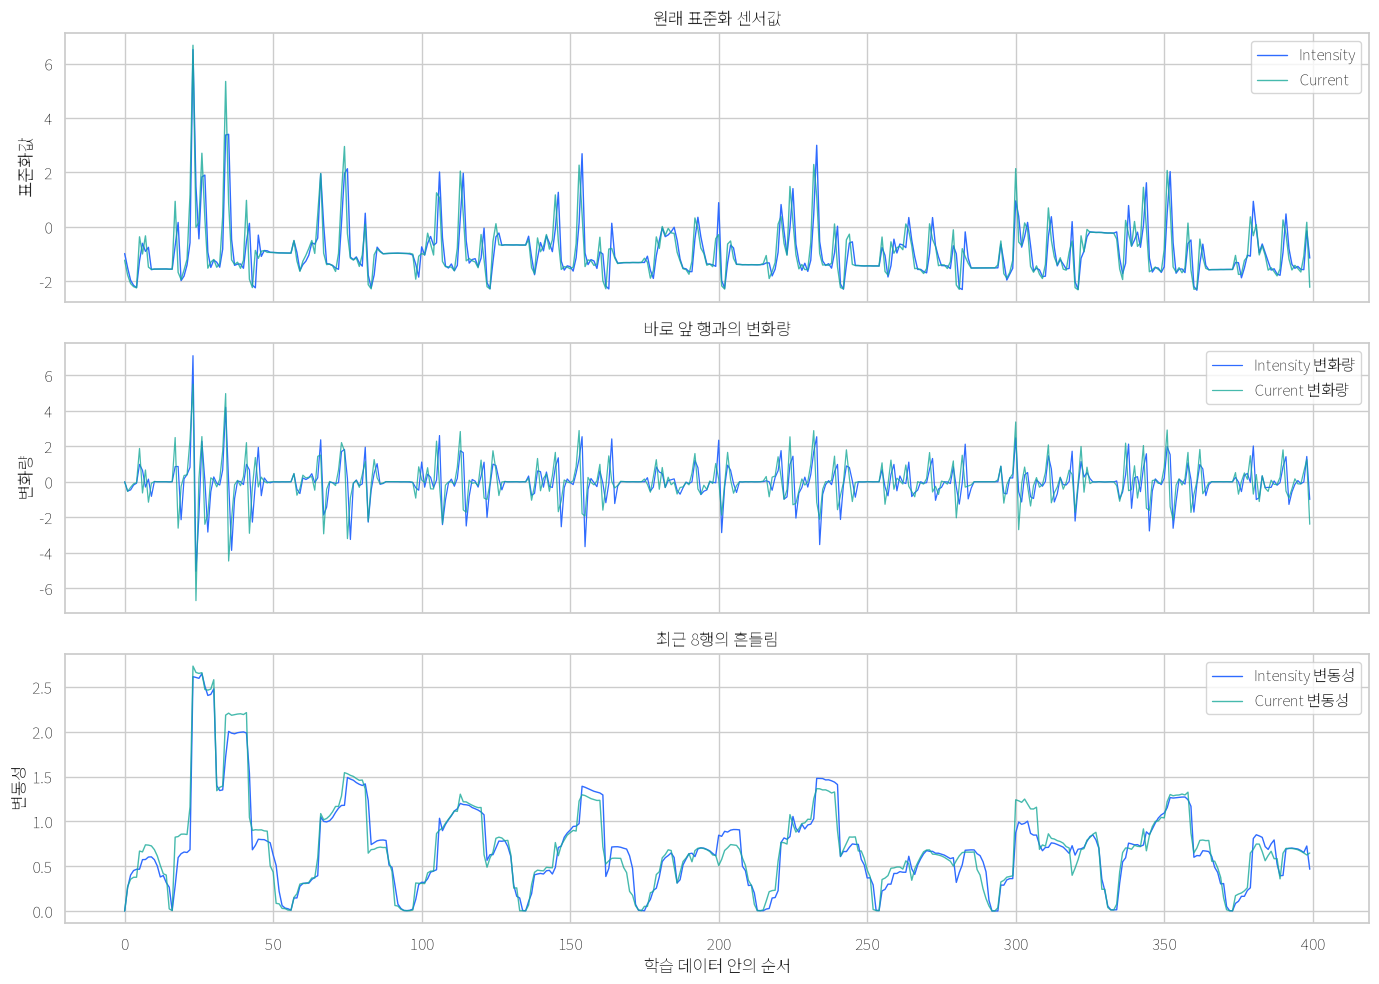

In [50]:
derived_plot_rows = 400
derived_plot_data = train_feature_data.iloc[:derived_plot_rows]

derived_feature_figure, derived_feature_axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

derived_feature_axes[0].plot(
    np.arange(derived_plot_rows),
    derived_plot_data["Intensity 표준화값"],
    label="Intensity",
    color=condition_colors["정상"],
    linewidth=1.0,
)
derived_feature_axes[0].plot(
    np.arange(derived_plot_rows),
    derived_plot_data["Current 표준화값"],
    label="Current",
    color="#18A999",
    linewidth=1.0,
    alpha=0.8,
)
derived_feature_axes[0].set_title("원래 표준화 센서값")
derived_feature_axes[0].set_ylabel("표준화값")

derived_feature_axes[1].plot(
    np.arange(derived_plot_rows),
    derived_plot_data["Intensity 1행 변화량"],
    label="Intensity 변화량",
    color=condition_colors["정상"],
    linewidth=0.9,
)
derived_feature_axes[1].plot(
    np.arange(derived_plot_rows),
    derived_plot_data["Current 1행 변화량"],
    label="Current 변화량",
    color="#18A999",
    linewidth=0.9,
    alpha=0.8,
)
derived_feature_axes[1].set_title("바로 앞 행과의 변화량")
derived_feature_axes[1].set_ylabel("변화량")

derived_feature_axes[2].plot(
    np.arange(derived_plot_rows),
    derived_plot_data["Intensity 최근 8행 변동성"],
    label="Intensity 변동성",
    color=condition_colors["정상"],
    linewidth=1.0,
)
derived_feature_axes[2].plot(
    np.arange(derived_plot_rows),
    derived_plot_data["Current 최근 8행 변동성"],
    label="Current 변동성",
    color="#18A999",
    linewidth=1.0,
    alpha=0.8,
)
derived_feature_axes[2].set_title("최근 8행의 흔들림")
derived_feature_axes[2].set_ylabel("변동성")
derived_feature_axes[2].set_xlabel("학습 데이터 안의 순서")

for axis in derived_feature_axes:
    axis.legend()

derived_feature_figure.tight_layout()
plt.show()

#### 3-3-5. 파생변수 계산 검증하기

행 수와 시간 순서가 그대로인지, 공백을 건너 변화량을 계산하지 않았는지, 모든 파생값이 유한한지, 두 센서 조합 공식이 정확한지 확인합니다.

In [51]:
first_rows_of_segments_are_zero = []
positive_within_segment_intervals = []
at_most_one_second_within_segments = []

for role_name, feature_data in derived_role_data.items():
    segment_first_rows = feature_data.groupby("구간 번호", sort=True).head(1)
    first_rows_of_segments_are_zero.append(
        np.allclose(
            segment_first_rows[
                [
                    "측정 간격(초)",
                    "Intensity 1행 변화량",
                    "Current 1행 변화량",
                    "Intensity 초당 변화량",
                    "Current 초당 변화량",
                    "Intensity 최근 8행 변동성",
                    "Current 최근 8행 변동성",
                ]
            ].to_numpy(),
            0,
        )
    )
    non_first_intervals = feature_data.loc[
        ~feature_data.index.isin(segment_first_rows.index),
        "측정 간격(초)",
    ]
    positive_within_segment_intervals.append((non_first_intervals > 0).all())
    at_most_one_second_within_segments.append((non_first_intervals <= 1.0).all())

all_derived_values_finite = all(
    np.isfinite(feature_data[derived_feature_columns].to_numpy()).all()
    for feature_data in derived_role_data.values()
)

derived_validation_checks = [
    ("네 데이터 역할 모두 파생변수 생성 전후 행 수가 같음", all(len(standard_scaled_role_data[role_name]) == len(derived_role_data[role_name]) for role_name in standard_scaled_role_data)),
    ("파생변수 생성 전후 시간과 구간 번호가 그대로임", all(standard_scaled_role_data[role_name][["Time", "구간 번호"]].reset_index(drop=True).equals(derived_role_data[role_name][["Time", "구간 번호"]].reset_index(drop=True)) for role_name in standard_scaled_role_data)),
    ("모든 구간 첫 행의 시간 파생값이 0임", all(first_rows_of_segments_are_zero)),
    ("모든 구간 내부 측정 간격이 0보다 큼", all(positive_within_segment_intervals)),
    ("모든 구간 내부 측정 간격이 1초 이하임", all(at_most_one_second_within_segments)),
    ("모든 파생변수 값이 유한함", all_derived_values_finite),
    ("두 센서 공통 수준 공식이 정확함", np.allclose(train_feature_data["두 센서 공통 수준"], (train_feature_data["Intensity 표준화값"] + train_feature_data["Current 표준화값"]) / 2)),
    ("두 센서 표준화 차이 공식이 정확함", np.allclose(train_feature_data["두 센서 표준화 차이"], train_feature_data["Intensity 표준화값"] - train_feature_data["Current 표준화값"])),
    ("학습 후보 상관행렬의 대각선이 모두 1임", np.allclose(np.diag(train_feature_correlation), 1)),
    ("파생변수 그래프가 3개 축으로 구성됨", len(derived_feature_axes) == 3),
]

derived_validation_result = pd.DataFrame(
    derived_validation_checks,
    columns=["검증 항목", "통과 여부"],
)
display(derived_validation_result)

if derived_validation_result["통과 여부"].all():
    print("파생변수 검증 결과: 모든 항목을 통과했습니다.")
else:
    print("파생변수 검증 결과: False인 항목을 추가로 확인해야 합니다.")

,검증 항목,통과 여부
0,네 데이터 역할 모두 파생변수 생성 전후 행 수가 같음,True
1,파생변수 생성 전후 시간과 구간 번호가 그대로임,True
2,모든 구간 첫 행의 시간 파생값이 0임,True
3,모든 구간 내부 측정 간격이 0보다 큼,True
4,모든 구간 내부 측정 간격이 1초 이하임,True
5,모든 파생변수 값이 유한함,True
6,두 센서 공통 수준 공식이 정확함,True
7,두 센서 표준화 차이 공식이 정확함,True
8,학습 후보 상관행렬의 대각선이 모두 1임,True
9,파생변수 그래프가 3개 축으로 구성됨,True


파생변수 검증 결과: 모든 항목을 통과했습니다.


### 파생변수 단계의 결론

- 공백을 건너지 않고 변화량과 최근 변동성을 계산했습니다.
- 첫 기준 모델은 `Intensity·Current 표준화값` 두 개만 사용합니다.
- 비교 모델은 두 센서의 `1행 변화량`과 `최근 8행 변동성`을 추가합니다.
- 초당 변화량과 두 센서 조합값은 중복 정보를 확인하고 결과를 설명하는 진단용 후보로 보존합니다.
- 파생변수를 많이 넣었다는 이유만으로 좋은 모델이라고 판단하지 않습니다. 같은 검증 데이터에서 기본 모델보다 실제 성능이 좋아질 때만 채택합니다.

다음 단계에서는 연속 구간을 건너지 않도록 모든 입력을 정확히 40행 윈도우로 만들고, 각 구간 마지막 행까지 포함하는 보완 윈도우를 추가합니다.

## 4. 모델링을 위한 윈도우 생성

지금까지는 한 행씩 센서값을 살펴봤습니다. 모델은 시간 흐름을 함께 볼 수 있도록 연속된 여러 행을 한 묶음으로 받습니다. 이 묶음을 **윈도우**라고 합니다.

이 데이터에는 개별 가공의 시작과 종료를 알려 주는 식별 열이 없습니다. 따라서 분석 단위는 임의의 생산 묶음이 아니라 **1초 초과 공백으로 나눈 연속 측정 구간**입니다. 윈도우는 한 연속 구간 안에서만 만들며, 공백을 가로질러 서로 끊긴 신호를 이어 붙이지 않습니다.

### 4-1. 이상 데이터도 개발용과 최종 확인용으로 분리

이상 데이터에는 연속 구간이 2개 있습니다. 첫 번째 구간은 모델 개발에 사용하고, 두 번째 구간은 마지막 홀드아웃 확인에 사용합니다. 첫 번째 구간 안에서는 앞 70%를 분류기 학습, 뒤 30%를 검증에 사용합니다. 한 개의 이상 구간을 둘로 나누는 한계가 있으므로 최종 보고서에 이를 명시합니다.

In [52]:
RANDOM_STATE = 42

anomaly_segment_ids = sorted(anomaly_test_data["구간 번호"].unique())
assert len(anomaly_segment_ids) == 2

anomaly_development_segment = (
    anomaly_test_data.loc[anomaly_test_data["구간 번호"] == anomaly_segment_ids[0]]
    .sort_values("Time")
    .copy()
)
anomaly_holdout_data = (
    anomaly_test_data.loc[anomaly_test_data["구간 번호"] == anomaly_segment_ids[1]]
    .sort_values("Time")
    .copy()
)

anomaly_development_cut = int(len(anomaly_development_segment) * 0.70)
anomaly_train_raw = anomaly_development_segment.iloc[:anomaly_development_cut].copy()
anomaly_validation_raw = anomaly_development_segment.iloc[anomaly_development_cut:].copy()

# 앞·뒤 부분이 하나의 구간 번호를 공유하면 윈도우 함수가 잘못 합칠 수 있으므로
# 분석용 구간 번호를 서로 다르게 부여합니다.
anomaly_train_raw["구간 번호"] = 1000
anomaly_validation_raw["구간 번호"] = 1001
anomaly_holdout_data["구간 번호"] = 1002

anomaly_partition_summary = pd.DataFrame(
    {
        "용도": ["분류기 학습", "검증", "최종 홀드아웃"],
        "행 수": [len(anomaly_train_raw), len(anomaly_validation_raw), len(anomaly_holdout_data)],
        "시작 시각": [anomaly_train_raw["Time"].min(), anomaly_validation_raw["Time"].min(), anomaly_holdout_data["Time"].min()],
        "종료 시각": [anomaly_train_raw["Time"].max(), anomaly_validation_raw["Time"].max(), anomaly_holdout_data["Time"].max()],
    }
)
display(anomaly_partition_summary)

,용도,행 수,시작 시각,종료 시각
0,분류기 학습,4404,2022-02-04 10:57:33.695,2022-02-04 11:06:24.675
1,검증,1888,2022-02-04 11:06:24.796,2022-02-04 11:10:12.333
2,최종 홀드아웃,5508,2022-02-04 11:10:25.573,2022-02-04 11:21:29.573


### 4-2. 이상 데이터에 학습용 표준화와 파생변수 적용

정상 학습 데이터에서 구한 평균과 표준편차를 그대로 사용합니다. 이상 데이터에서 평균을 새로 계산하면 평가 정보가 전처리에 섞이기 때문입니다.

In [53]:
def prepare_anomaly_partition(raw_data):
    scaled_data = apply_scaler(raw_data, standard_scaler, "표준화값")
    return add_time_derived_features(scaled_data)


anomaly_train_feature_data = prepare_anomaly_partition(anomaly_train_raw)
anomaly_validation_feature_data = prepare_anomaly_partition(anomaly_validation_raw)
anomaly_holdout_feature_data = prepare_anomaly_partition(anomaly_holdout_data)

model_role_data = {
    "정상 학습": train_feature_data,
    "정상 검증": validation_feature_data,
    "정상 홀드아웃": normal_test_feature_data,
    "이상 학습": anomaly_train_feature_data,
    "이상 검증": anomaly_validation_feature_data,
    "이상 홀드아웃": anomaly_holdout_feature_data,
}

display(pd.DataFrame({"데이터": model_role_data.keys(), "행 수": [len(data) for data in model_role_data.values()]}))

,데이터,행 수
0,정상 학습,63715
1,정상 검증,14745
2,정상 홀드아웃,13820
3,이상 학습,4404
4,이상 검증,1888
5,이상 홀드아웃,5508


### 4-3. 윈도우 크기와 남는 행 처리 방법

- **엄격한 비중첩**: 1–10행, 11–20행처럼 겹치지 않게 묶습니다. 끝에 10행보다 적게 남으면 모델 입력에서는 제외합니다.
- **마지막 보완 포함**: 끝에 남는 행이 있으면 마지막 10행을 한 번 더 잡아 끝부분을 포함합니다. 대신 일부 행이 한 번 더 사용됩니다.

두 방법을 모두 비교하여 중복을 늘린 것이 실제 검증 성능을 높였는지 확인합니다.

In [54]:
def make_windows(dataframe, feature_columns, window_size, strategy="strict"):
    windows = []
    metadata_rows = []
    for segment_id, segment_data in dataframe.groupby("구간 번호", sort=True):
        segment_data = segment_data.sort_values("Time").reset_index(drop=True)
        row_count = len(segment_data)
        if row_count < window_size:
            continue

        starts = list(range(0, row_count - window_size + 1, window_size))
        if strategy == "coverage":
            last_start = row_count - window_size
            if last_start not in starts:
                starts.append(last_start)
        elif strategy != "strict":
            raise ValueError("strategy는 strict 또는 coverage여야 합니다.")

        for start in starts:
            end = start + window_size
            windows.append(segment_data.loc[start:end - 1, feature_columns].to_numpy(dtype="float32"))
            metadata_rows.append(
                {
                    "구간 번호": segment_id,
                    "시작 행": start,
                    "종료 행": end - 1,
                    "시작 시각": segment_data.loc[start, "Time"],
                    "종료 시각": segment_data.loc[end - 1, "Time"],
                }
            )

    if not windows:
        return np.empty((0, window_size, len(feature_columns)), dtype="float32"), pd.DataFrame(metadata_rows)
    return np.stack(windows), pd.DataFrame(metadata_rows)


window_size_candidates = [10, 20, 40, 80]
window_strategy_candidates = ["strict", "coverage"]
feature_set_lookup = {
    "기본 2개": baseline_sequence_feature_columns,
    "파생변수 포함 6개": enhanced_sequence_feature_columns,
}

window_count_rows = []
for window_size in window_size_candidates:
    for strategy in window_strategy_candidates:
        windows, metadata = make_windows(train_feature_data, baseline_sequence_feature_columns, window_size, strategy)
        repeated_rows = max(0, len(windows) * window_size - len(train_feature_data))
        omitted_rows = max(0, len(train_feature_data) - len(windows) * window_size)
        window_count_rows.append(
            {
                "윈도우 크기": window_size,
                "처리 방법": strategy,
                "학습 윈도우 수": len(windows),
                "빠진 행의 상한": omitted_rows,
                "반복 사용 행의 상한": repeated_rows,
            }
        )

window_count_summary = pd.DataFrame(window_count_rows)
display(window_count_summary)

,윈도우 크기,처리 방법,학습 윈도우 수,빠진 행의 상한,반복 사용 행의 상한
0,10,strict,6366,55,0
1,10,coverage,6377,0,55
2,20,strict,3179,135,0
3,20,coverage,3192,0,125
4,40,strict,1588,195,0
5,40,coverage,1601,0,325
6,80,strict,791,435,0
7,80,coverage,804,0,605


## 5. 윈도우·변수 조합의 검증 성능 비교

윈도우 크기 4개, 남는 행 처리 2개, 변수 구성 2개를 조합하여 총 16가지를 비교합니다. 분류기는 로지스틱 회귀를 기준 모델로 사용하고, 검출기는 정상 학습 윈도우의 PCA 복원오차를 사용합니다. 모든 선택은 홀드아웃이 아니라 검증 자료의 F1을 기준으로 합니다.

In [55]:
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
)


def best_f1_threshold(y_true, scores):
    precision, recall, thresholds = precision_recall_curve(y_true, scores)
    if len(thresholds) == 0:
        return 0.5, 0.0
    f1_values = 2 * precision[:-1] * recall[:-1] / np.maximum(precision[:-1] + recall[:-1], 1e-12)
    best_index = int(np.nanargmax(f1_values))
    return float(thresholds[best_index]), float(f1_values[best_index])


def metric_row(y_true, scores, threshold):
    prediction = (np.asarray(scores) >= threshold).astype(int)
    return {
        "정확도": accuracy_score(y_true, prediction),
        "정밀도": precision_score(y_true, prediction, zero_division=0),
        "재현율": recall_score(y_true, prediction, zero_division=0),
        "F1": f1_score(y_true, prediction, zero_division=0),
        "ROC-AUC": roc_auc_score(y_true, scores),
        "PR-AUC": average_precision_score(y_true, scores),
    }


def combine_labeled(normal_windows, anomaly_windows):
    features = np.concatenate([normal_windows, anomaly_windows], axis=0)
    labels = np.concatenate([
        np.zeros(len(normal_windows), dtype=int),
        np.ones(len(anomaly_windows), dtype=int),
    ])
    return features, labels


window_configuration_rows = []
window_cache = {}

for window_size in window_size_candidates:
    for strategy in window_strategy_candidates:
        for feature_set_name, feature_columns in feature_set_lookup.items():
            cache_key = (window_size, strategy, feature_set_name)
            role_windows = {
                role_name: make_windows(role_data, feature_columns, window_size, strategy)[0]
                for role_name, role_data in model_role_data.items()
            }
            window_cache[cache_key] = role_windows

            classifier_train_x, classifier_train_y = combine_labeled(role_windows["정상 학습"], role_windows["이상 학습"])
            classifier_validation_x, classifier_validation_y = combine_labeled(role_windows["정상 검증"], role_windows["이상 검증"])
            flat_train_x = classifier_train_x.reshape(len(classifier_train_x), -1)
            flat_validation_x = classifier_validation_x.reshape(len(classifier_validation_x), -1)

            baseline_classifier = LogisticRegression(
                C=1.0,
                class_weight="balanced",
                max_iter=2000,
                random_state=RANDOM_STATE,
            )
            baseline_classifier.fit(flat_train_x, classifier_train_y)
            classifier_scores = baseline_classifier.predict_proba(flat_validation_x)[:, 1]
            classifier_threshold, classifier_f1 = best_f1_threshold(classifier_validation_y, classifier_scores)

            detector_train_x = role_windows["정상 학습"].reshape(len(role_windows["정상 학습"]), -1)
            detector_validation_x, detector_validation_y = combine_labeled(role_windows["정상 검증"], role_windows["이상 검증"])
            detector_validation_x = detector_validation_x.reshape(len(detector_validation_x), -1)
            baseline_detector = PCA(n_components=0.95, svd_solver="full")
            baseline_detector.fit(detector_train_x)
            reconstructed = baseline_detector.inverse_transform(baseline_detector.transform(detector_validation_x))
            detector_scores = np.mean((detector_validation_x - reconstructed) ** 2, axis=1)
            detector_threshold, detector_f1 = best_f1_threshold(detector_validation_y, detector_scores)

            window_configuration_rows.append(
                {
                    "윈도우 크기": window_size,
                    "남는 행 처리": strategy,
                    "변수 구성": feature_set_name,
                    "분류기 검증 F1": classifier_f1,
                    "분류기 기준값": classifier_threshold,
                    "검출기 검증 F1": detector_f1,
                    "검출기 기준값": detector_threshold,
                }
            )

window_configuration_results = pd.DataFrame(window_configuration_rows)
display(window_configuration_results.sort_values("분류기 검증 F1", ascending=False).reset_index(drop=True))

,윈도우 크기,남는 행 처리,변수 구성,분류기 검증 F1,분류기 기준값,검출기 검증 F1,검출기 기준값
0,10,coverage,파생변수 포함 6개,0.896359,0.556596,0.204545,0.057435
1,10,strict,파생변수 포함 6개,0.894587,0.573175,0.204082,0.057159
2,10,coverage,기본 2개,0.864266,0.624627,0.250871,0.119205
3,20,coverage,기본 2개,0.863636,0.635902,0.340136,0.123171
4,10,strict,기본 2개,0.863510,0.624732,0.250896,0.123386
5,20,strict,기본 2개,0.862069,0.637348,0.342466,0.123929
6,20,coverage,파생변수 포함 6개,0.855491,0.582847,0.347826,0.088935
7,20,strict,파생변수 포함 6개,0.848837,0.576881,0.350877,0.069686
8,40,coverage,기본 2개,0.813187,0.527076,0.444444,0.092330
9,40,strict,기본 2개,0.800000,0.499604,0.449438,0.091590


,용도,윈도우 크기,남는 행 처리,변수 구성,검증 F1
0,분류기,10,coverage,파생변수 포함 6개,0.896359
1,검출기,80,coverage,기본 2개,0.565217


findfont: Failed to find font weight normal for Noto Sans KR, now using 100.


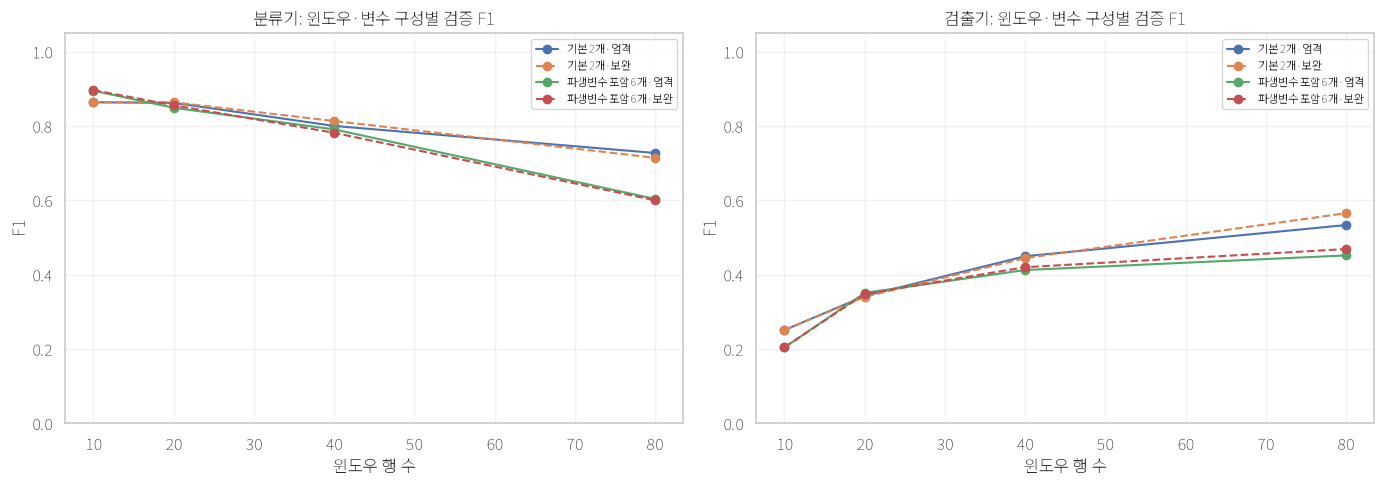

In [56]:
best_classifier_config = (
    window_configuration_results.sort_values(
        ["분류기 검증 F1", "윈도우 크기"],
        ascending=[False, True],
    ).iloc[0]
)
best_detector_config = (
    window_configuration_results.sort_values(
        ["검출기 검증 F1", "윈도우 크기"],
        ascending=[False, False],
    ).iloc[0]
)

selected_configuration_summary = pd.DataFrame(
    [
        {
            "용도": "분류기",
            "윈도우 크기": int(best_classifier_config["윈도우 크기"]),
            "남는 행 처리": best_classifier_config["남는 행 처리"],
            "변수 구성": best_classifier_config["변수 구성"],
            "검증 F1": best_classifier_config["분류기 검증 F1"],
        },
        {
            "용도": "검출기",
            "윈도우 크기": int(best_detector_config["윈도우 크기"]),
            "남는 행 처리": best_detector_config["남는 행 처리"],
            "변수 구성": best_detector_config["변수 구성"],
            "검증 F1": best_detector_config["검출기 검증 F1"],
        },
    ]
)
display(selected_configuration_summary)

figure, axes = plt.subplots(1, 2, figsize=(14, 5))
for feature_name, group in window_configuration_results.groupby("변수 구성"):
    strict_group = group.loc[group["남는 행 처리"] == "strict"].sort_values("윈도우 크기")
    coverage_group = group.loc[group["남는 행 처리"] == "coverage"].sort_values("윈도우 크기")
    axes[0].plot(strict_group["윈도우 크기"], strict_group["분류기 검증 F1"], marker="o", label=f"{feature_name}·엄격")
    axes[0].plot(coverage_group["윈도우 크기"], coverage_group["분류기 검증 F1"], marker="o", linestyle="--", label=f"{feature_name}·보완")
    axes[1].plot(strict_group["윈도우 크기"], strict_group["검출기 검증 F1"], marker="o", label=f"{feature_name}·엄격")
    axes[1].plot(coverage_group["윈도우 크기"], coverage_group["검출기 검증 F1"], marker="o", linestyle="--", label=f"{feature_name}·보완")
axes[0].set_title("분류기: 윈도우·변수 구성별 검증 F1")
axes[1].set_title("검출기: 윈도우·변수 구성별 검증 F1")
for axis in axes:
    axis.set_xlabel("윈도우 행 수")
    axis.set_ylabel("F1")
    axis.set_ylim(0, 1.05)
    axis.grid(alpha=0.25)
    axis.legend(fontsize=8)
plt.tight_layout()
plt.show()

**이 표는 1차 선택입니다.** 여기의 검출기 80행은 PCA를 기준으로 고른 값입니다. 아래 7-1절에서 최종 검출기인 One Class SVM으로 40·80·120·160행을 다시 비교합니다.


## 6. 분류기 성능 개선

선택된 윈도우와 변수 구성으로 로지스틱 회귀, 랜덤 포레스트, 히스토그램 그래디언트 부스팅, LSTM을 비교합니다. 같은 검증 자료에서 판정 기준값을 정하고, 홀드아웃은 최종 확인에만 사용합니다.

In [57]:
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.utils.class_weight import compute_sample_weight


classifier_key = (
    int(best_classifier_config["윈도우 크기"]),
    best_classifier_config["남는 행 처리"],
    best_classifier_config["변수 구성"],
)
classifier_feature_columns = feature_set_lookup[classifier_key[2]]
classifier_role_windows = window_cache[classifier_key]

classifier_train_x, classifier_train_y = combine_labeled(classifier_role_windows["정상 학습"], classifier_role_windows["이상 학습"])
classifier_validation_x, classifier_validation_y = combine_labeled(classifier_role_windows["정상 검증"], classifier_role_windows["이상 검증"])
classifier_holdout_x, classifier_holdout_y = combine_labeled(classifier_role_windows["정상 홀드아웃"], classifier_role_windows["이상 홀드아웃"])

classifier_train_flat = classifier_train_x.reshape(len(classifier_train_x), -1)
classifier_validation_flat = classifier_validation_x.reshape(len(classifier_validation_x), -1)
classifier_holdout_flat = classifier_holdout_x.reshape(len(classifier_holdout_x), -1)
classifier_sample_weight = compute_sample_weight(class_weight="balanced", y=classifier_train_y)

classifier_tuning_rows = []
trained_classifier_models = {}

for c_value in [0.01, 0.1, 1.0, 10.0]:
    model_name = f"Logistic C={c_value}"
    model = LogisticRegression(C=c_value, class_weight="balanced", max_iter=2500, random_state=RANDOM_STATE)
    model.fit(classifier_train_flat, classifier_train_y)
    scores = model.predict_proba(classifier_validation_flat)[:, 1]
    threshold, validation_f1 = best_f1_threshold(classifier_validation_y, scores)
    classifier_tuning_rows.append({"모델": model_name, "모델 계열": "로지스틱 회귀", "기준값": threshold, **metric_row(classifier_validation_y, scores, threshold)})
    trained_classifier_models[model_name] = ("sklearn", model)

for max_depth in [8, None]:
    for min_leaf in [1, 5]:
        model_name = f"RandomForest depth={max_depth}, leaf={min_leaf}"
        model = RandomForestClassifier(
            n_estimators=250,
            max_depth=max_depth,
            min_samples_leaf=min_leaf,
            class_weight="balanced_subsample",
            n_jobs=-1,
            random_state=RANDOM_STATE,
        )
        model.fit(classifier_train_flat, classifier_train_y)
        scores = model.predict_proba(classifier_validation_flat)[:, 1]
        threshold, validation_f1 = best_f1_threshold(classifier_validation_y, scores)
        classifier_tuning_rows.append({"모델": model_name, "모델 계열": "랜덤 포레스트", "기준값": threshold, **metric_row(classifier_validation_y, scores, threshold)})
        trained_classifier_models[model_name] = ("sklearn", model)

for max_depth in [4, 8, None]:
    for learning_rate in [0.05, 0.1]:
        for l2_value in [0.0, 1.0]:
            model_name = f"HistGB depth={max_depth}, lr={learning_rate}, l2={l2_value}"
            model = HistGradientBoostingClassifier(
                max_depth=max_depth,
                learning_rate=learning_rate,
                l2_regularization=l2_value,
                max_iter=250,
                random_state=RANDOM_STATE,
            )
            model.fit(classifier_train_flat, classifier_train_y, sample_weight=classifier_sample_weight)
            scores = model.predict_proba(classifier_validation_flat)[:, 1]
            threshold, validation_f1 = best_f1_threshold(classifier_validation_y, scores)
            classifier_tuning_rows.append({"모델": model_name, "모델 계열": "히스토그램 그래디언트 부스팅", "기준값": threshold, **metric_row(classifier_validation_y, scores, threshold)})
            trained_classifier_models[model_name] = ("sklearn", model)

print("전통적 분류기 후보 학습 완료:", len(classifier_tuning_rows), "개")

전통적 분류기 후보 학습 완료: 20 개


### 6-1. LSTM 비교

LSTM은 행의 순서를 직접 받아 시간 흐름을 학습하는 딥러닝 모델입니다. 같은 윈도우를 사용해 전통적 분류기와 검증 F1을 비교합니다.

In [58]:
import tensorflow as tf

tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(RANDOM_STATE)

lstm_model = tf.keras.Sequential(
    [
        tf.keras.layers.Input(shape=classifier_train_x.shape[1:]),
        tf.keras.layers.LSTM(32),
        tf.keras.layers.Dropout(0.20),
        tf.keras.layers.Dense(16, activation="relu"),
        tf.keras.layers.Dense(1, activation="sigmoid"),
    ]
)
lstm_model.compile(optimizer="adam", loss="binary_crossentropy")

class_counts = np.bincount(classifier_train_y)
class_weight = {
    0: len(classifier_train_y) / (2 * class_counts[0]),
    1: len(classifier_train_y) / (2 * class_counts[1]),
}

lstm_history = lstm_model.fit(
    classifier_train_x,
    classifier_train_y,
    validation_data=(classifier_validation_x, classifier_validation_y),
    epochs=8,
    batch_size=128,
    class_weight=class_weight,
    verbose=0,
)
lstm_scores = lstm_model.predict(classifier_validation_x, verbose=0).ravel()
lstm_threshold, lstm_validation_f1 = best_f1_threshold(classifier_validation_y, lstm_scores)
classifier_tuning_rows.append(
    {"모델": "LSTM 32-unit", "모델 계열": "LSTM", "기준값": lstm_threshold, **metric_row(classifier_validation_y, lstm_scores, lstm_threshold)}
)
trained_classifier_models["LSTM 32-unit"] = ("lstm", lstm_model)

classifier_tuning_results = pd.DataFrame(classifier_tuning_rows).sort_values("F1", ascending=False).reset_index(drop=True)
display(classifier_tuning_results.head(15))

,모델,모델 계열,기준값,정확도,정밀도,재현율,F1,ROC-AUC,PR-AUC
0,"HistGB depth=None, lr=0.1, l2=1.0",히스토그램 그래디언트 부스팅,0.076151,0.989183,0.962162,0.941799,0.951872,0.996718,0.982717
1,"HistGB depth=None, lr=0.1, l2=0.0",히스토그램 그래디언트 부스팅,0.006709,0.988582,0.942708,0.957672,0.950131,0.998260,0.987809
2,"HistGB depth=8, lr=0.1, l2=0.0",히스토그램 그래디언트 부스팅,0.010172,0.987981,0.924623,0.973545,0.948454,0.998475,0.989261
3,"HistGB depth=None, lr=0.05, l2=1.0",히스토그램 그래디언트 부스팅,0.158092,0.987981,0.966851,0.925926,0.945946,0.996251,0.979676
4,"HistGB depth=None, lr=0.05, l2=0.0",히스토그램 그래디언트 부스팅,0.089907,0.987380,0.946809,0.941799,0.944297,0.996764,0.982987
5,"HistGB depth=8, lr=0.1, l2=1.0",히스토그램 그래디언트 부스팅,0.077647,0.987380,0.951613,0.936508,0.944000,0.997152,0.985207
6,"HistGB depth=8, lr=0.05, l2=1.0",히스토그램 그래디언트 부스팅,0.110174,0.986779,0.932642,0.952381,0.942408,0.996416,0.980191
7,"RandomForest depth=None, leaf=1",랜덤 포레스트,0.140000,0.985577,0.923077,0.952381,0.937500,0.997114,0.981450
8,"HistGB depth=8, lr=0.05, l2=0.0",히스토그램 그래디언트 부스팅,0.096243,0.984976,0.922680,0.947090,0.934726,0.997410,0.983382
9,Logistic C=0.01,로지스틱 회귀,0.581437,0.984976,0.993976,0.873016,0.929577,0.988102,0.963734


## 7. 정상 중심 검출기 성능 개선

검출기는 정상 학습 윈도우만 보고 정상 영역을 배웁니다. PCA 복원오차, Isolation Forest, One Class SVM을 비교합니다. 이상 정답은 모델 학습이 아니라 검증 기준값 선택에만 사용합니다.

In [59]:
from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM


detector_key = (
    int(best_detector_config["윈도우 크기"]),
    best_detector_config["남는 행 처리"],
    best_detector_config["변수 구성"],
)
detector_feature_columns = feature_set_lookup[detector_key[2]]
detector_role_windows = window_cache[detector_key]

detector_train_x = detector_role_windows["정상 학습"]
detector_validation_x, detector_validation_y = combine_labeled(detector_role_windows["정상 검증"], detector_role_windows["이상 검증"])
detector_holdout_x, detector_holdout_y = combine_labeled(detector_role_windows["정상 홀드아웃"], detector_role_windows["이상 홀드아웃"])

detector_train_flat = detector_train_x.reshape(len(detector_train_x), -1)
detector_validation_flat = detector_validation_x.reshape(len(detector_validation_x), -1)
detector_holdout_flat = detector_holdout_x.reshape(len(detector_holdout_x), -1)

detector_tuning_rows = []
trained_detector_models = {}

for explained_variance in [0.90, 0.95, 0.99]:
    model_name = f"PCA variance={explained_variance}"
    model = PCA(n_components=explained_variance, svd_solver="full")
    model.fit(detector_train_flat)
    validation_reconstructed = model.inverse_transform(model.transform(detector_validation_flat))
    scores = np.mean((detector_validation_flat - validation_reconstructed) ** 2, axis=1)
    threshold, validation_f1 = best_f1_threshold(detector_validation_y, scores)
    detector_tuning_rows.append({"모델": model_name, "검출기 계열": "PCA 복원오차", "기준값": threshold, **metric_row(detector_validation_y, scores, threshold)})
    trained_detector_models[model_name] = ("pca", model)

for contamination in [0.01, 0.03, 0.05, 0.10]:
    model_name = f"IsolationForest contamination={contamination}"
    model = IsolationForest(n_estimators=300, contamination=contamination, random_state=RANDOM_STATE, n_jobs=-1)
    model.fit(detector_train_flat)
    scores = -model.decision_function(detector_validation_flat)
    threshold, validation_f1 = best_f1_threshold(detector_validation_y, scores)
    detector_tuning_rows.append({"모델": model_name, "검출기 계열": "Isolation Forest", "기준값": threshold, **metric_row(detector_validation_y, scores, threshold)})
    trained_detector_models[model_name] = ("score", model)

for nu_value in [0.01, 0.03, 0.05, 0.10]:
    for gamma_value in ["scale", 0.01, 0.1, 1.0]:
        model_name = f"OneClassSVM nu={nu_value}, gamma={gamma_value}"
        model = OneClassSVM(nu=nu_value, gamma=gamma_value)
        model.fit(detector_train_flat)
        scores = -model.decision_function(detector_validation_flat)
        threshold, validation_f1 = best_f1_threshold(detector_validation_y, scores)
        detector_tuning_rows.append({"모델": model_name, "검출기 계열": "One Class SVM", "기준값": threshold, **metric_row(detector_validation_y, scores, threshold)})
        trained_detector_models[model_name] = ("score", model)

detector_tuning_results = pd.DataFrame(detector_tuning_rows).sort_values("F1", ascending=False).reset_index(drop=True)
display(detector_tuning_results.head(15))

,모델,검출기 계열,기준값,정확도,정밀도,재현율,F1,ROC-AUC,PR-AUC
0,"OneClassSVM nu=0.1, gamma=0.1",One Class SVM,0.101860,0.919048,0.612903,0.791667,0.690909,0.941308,0.688890
1,"OneClassSVM nu=0.03, gamma=0.1",One Class SVM,0.030555,0.919048,0.612903,0.791667,0.690909,0.941308,0.688890
2,"OneClassSVM nu=0.01, gamma=0.1",One Class SVM,0.010184,0.919048,0.612903,0.791667,0.690909,0.941308,0.688890
3,"OneClassSVM nu=0.05, gamma=0.1",One Class SVM,0.050929,0.919048,0.612903,0.791667,0.690909,0.941308,0.688890
4,IsolationForest contamination=0.05,Isolation Forest,-0.030728,0.914286,0.636364,0.583333,0.608696,0.888441,0.581006
5,IsolationForest contamination=0.03,Isolation Forest,-0.039795,0.914286,0.636364,0.583333,0.608696,0.888441,0.581006
6,IsolationForest contamination=0.01,Isolation Forest,-0.058985,0.914286,0.636364,0.583333,0.608696,0.888441,0.581006
7,IsolationForest contamination=0.1,Isolation Forest,-0.017568,0.914286,0.636364,0.583333,0.608696,0.888441,0.581006
8,PCA variance=0.95,PCA 복원오차,0.121187,0.904762,0.590909,0.541667,0.565217,0.832661,0.563035
9,PCA variance=0.9,PCA 복원오차,0.219941,0.890476,0.518519,0.583333,0.549020,0.855735,0.568663


### 7-1. 40·80·120·160행을 같은 검출기로 직접 비교

앞에서는 PCA로 윈도우 크기를 고른 다음 One Class SVM을 튜닝했습니다. 그 결과만으로 80행이 120행이나 160행보다 좋다고 말할 수 없습니다. 여기서는 **변수 2개, 마지막 행 포함 방식, One Class SVM**을 똑같이 고정하고 윈도우 크기만 40·80·120·160행으로 바꿉니다. 각 크기에서 `nu`와 `gamma`를 같은 후보 목록으로 튜닝하고 검증 F1을 비교합니다.

큰 윈도우일수록 모델의 판단 횟수와 검증 이상 윈도우 수가 줄어듭니다. 따라서 F1과 함께 윈도우 개수도 확인합니다.

In [60]:
extended_detector_rows = []
extended_detector_models = {}
detector_window_sizes_extended = [40, 80, 120, 160]
detector_nu_candidates = [0.01, 0.03, 0.05, 0.10]
detector_gamma_candidates = ["scale", 0.01, 0.1, 1.0]

for candidate_size in detector_window_sizes_extended:
    normal_train_windows, _ = make_windows(
        train_feature_data, baseline_sequence_feature_columns, candidate_size, "coverage"
    )
    normal_validation_windows, _ = make_windows(
        validation_feature_data, baseline_sequence_feature_columns, candidate_size, "coverage"
    )
    anomaly_validation_windows, _ = make_windows(
        anomaly_validation_feature_data, baseline_sequence_feature_columns, candidate_size, "coverage"
    )
    validation_windows, validation_labels = combine_labeled(
        normal_validation_windows, anomaly_validation_windows
    )
    train_flat = normal_train_windows.reshape(len(normal_train_windows), -1)
    validation_flat = validation_windows.reshape(len(validation_windows), -1)

    for candidate_nu in detector_nu_candidates:
        for candidate_gamma in detector_gamma_candidates:
            name = (
                f"OneClassSVM window={candidate_size}, "
                f"nu={candidate_nu}, gamma={candidate_gamma}"
            )
            model = OneClassSVM(nu=candidate_nu, gamma=candidate_gamma)
            model.fit(train_flat)
            scores = -model.decision_function(validation_flat)
            threshold, _ = best_f1_threshold(validation_labels, scores)
            extended_detector_rows.append(
                {
                    "모델": name,
                    "검출기 계열": "One Class SVM",
                    "윈도우 크기": candidate_size,
                    "정상 학습 윈도우": len(normal_train_windows),
                    "정상 검증 윈도우": len(normal_validation_windows),
                    "이상 검증 윈도우": len(anomaly_validation_windows),
                    "기준값": threshold,
                    **metric_row(validation_labels, scores, threshold),
                }
            )
            extended_detector_models[name] = ("score", model)

extended_detector_results = pd.DataFrame(extended_detector_rows)
best_by_window = (
    extended_detector_results.sort_values(
        ["윈도우 크기", "F1", "모델"], ascending=[True, False, True]
    )
    .groupby("윈도우 크기", as_index=False)
    .head(1)
    .sort_values("윈도우 크기")
    .reset_index(drop=True)
)
display(
    best_by_window[
        ["윈도우 크기", "정상 학습 윈도우", "정상 검증 윈도우", "이상 검증 윈도우", "모델", "정밀도", "재현율", "F1", "PR-AUC"]
    ]
)

,윈도우 크기,정상 학습 윈도우,정상 검증 윈도우,이상 검증 윈도우,모델,정밀도,재현율,F1,PR-AUC
0,40,1601,369,48,"OneClassSVM window=40, nu=0.01, gamma=1.0",0.557143,0.812500,0.661017,0.641361
1,80,804,186,24,"OneClassSVM window=80, nu=0.01, gamma=0.1",0.612903,0.791667,0.690909,0.688890
2,120,539,123,16,"OneClassSVM window=120, nu=0.01, gamma=0.1",0.687500,0.687500,0.687500,0.703327
3,160,403,93,12,"OneClassSVM window=160, nu=0.01, gamma=0.1",0.800000,0.666667,0.727273,0.721851


In [61]:
# 80행에서만 시험한 PCA·Isolation Forest 결과도 후보 목록에 유지합니다.
original_other_detectors = detector_tuning_results.loc[
    detector_tuning_results["검출기 계열"] != "One Class SVM"
].copy()
original_other_detectors["윈도우 크기"] = 80
detector_tuning_results = pd.concat(
    [original_other_detectors, extended_detector_results], ignore_index=True
).sort_values(["F1", "윈도우 크기", "모델"], ascending=[False, True, True]).reset_index(drop=True)
trained_detector_models.update(extended_detector_models)

selected_window_size_for_detector = int(detector_tuning_results.iloc[0]["윈도우 크기"])
detector_role_windows = {
    role_name: make_windows(
        role_data,
        baseline_sequence_feature_columns,
        selected_window_size_for_detector,
        "coverage",
    )[0]
    for role_name, role_data in model_role_data.items()
}
detector_train_x = detector_role_windows["정상 학습"]
detector_validation_x, detector_validation_y = combine_labeled(
    detector_role_windows["정상 검증"], detector_role_windows["이상 검증"]
)
detector_holdout_x, detector_holdout_y = combine_labeled(
    detector_role_windows["정상 홀드아웃"], detector_role_windows["이상 홀드아웃"]
)
detector_train_flat = detector_train_x.reshape(len(detector_train_x), -1)
detector_validation_flat = detector_validation_x.reshape(len(detector_validation_x), -1)
detector_holdout_flat = detector_holdout_x.reshape(len(detector_holdout_x), -1)

print("최종 검출기용 윈도우 크기:", selected_window_size_for_detector, "행")
print("검증 F1 기준 최고 검출기:", detector_tuning_results.iloc[0]["모델"])
print("검증 F1:", round(float(detector_tuning_results.iloc[0]["F1"]), 4))
assert len(best_by_window) == 4
assert selected_window_size_for_detector in detector_window_sizes_extended

최종 검출기용 윈도우 크기: 160 행
검증 F1 기준 최고 검출기: OneClassSVM window=160, nu=0.01, gamma=0.1
검증 F1: 0.7273


**추가 비교 결론:** 같은 센서 변수 2개와 마지막 행 포함 방식을 사용한 One Class SVM에서 검증 F1은 40행 0.6610, 80행 0.6909, 120행 0.6875, 160행 0.7273입니다. 따라서 이번 후보 중 검출기는 160행을 선택합니다. 다만 160행의 검증 이상 윈도우는 12개뿐이며, 홀드아웃 F1은 0.8485로 80행의 약 0.8438과 차이가 작습니다. 160행을 보편적인 최적값으로 단정하지 않고 새 데이터에서 다시 확인해야 합니다.


## 8. 최종 홀드아웃 평가

검증 F1이 가장 높은 분류기와 검출기를 각각 선택합니다. 선택이 끝난 뒤에만 홀드아웃 성능을 계산합니다.

In [62]:
best_classifier_row = classifier_tuning_results.iloc[0]
selected_classifier_name = best_classifier_row["모델"]
selected_classifier_kind, selected_classifier_model = trained_classifier_models[selected_classifier_name]

def classifier_scores(model_kind, model, window_values):
    if model_kind == "lstm":
        return model.predict(window_values, verbose=0).ravel()
    return model.predict_proba(window_values.reshape(len(window_values), -1))[:, 1]


best_classifier_holdout_scores = classifier_scores(selected_classifier_kind, selected_classifier_model, classifier_holdout_x)
best_classifier_holdout_metrics = metric_row(
    classifier_holdout_y,
    best_classifier_holdout_scores,
    float(best_classifier_row["기준값"]),
)
best_classifier_holdout_prediction = (best_classifier_holdout_scores >= float(best_classifier_row["기준값"])).astype(int)

best_detector_row = detector_tuning_results.iloc[0]
selected_detector_name = best_detector_row["모델"]
selected_detector_kind, selected_detector_model = trained_detector_models[selected_detector_name]

def detector_scores(model_kind, model, flat_values):
    if model_kind == "pca":
        reconstructed = model.inverse_transform(model.transform(flat_values))
        return np.mean((flat_values - reconstructed) ** 2, axis=1)
    return -model.decision_function(flat_values)


best_detector_holdout_scores = detector_scores(selected_detector_kind, selected_detector_model, detector_holdout_flat)
best_detector_holdout_metrics = metric_row(
    detector_holdout_y,
    best_detector_holdout_scores,
    float(best_detector_row["기준값"]),
)
best_detector_holdout_prediction = (best_detector_holdout_scores >= float(best_detector_row["기준값"])).astype(int)

detector_classifier_comparison = pd.DataFrame(
    [
        {
            "구분": "분류기",
            "선택 모델": selected_classifier_name,
            "검증 F1": best_classifier_row["F1"],
            "검증 PR-AUC": best_classifier_row["PR-AUC"],
            **{f"홀드아웃 {key}": value for key, value in best_classifier_holdout_metrics.items()},
        },
        {
            "구분": "검출기",
            "선택 모델": selected_detector_name,
            "검증 F1": best_detector_row["F1"],
            "검증 PR-AUC": best_detector_row["PR-AUC"],
            **{f"홀드아웃 {key}": value for key, value in best_detector_holdout_metrics.items()},
        },
    ]
)
display(detector_classifier_comparison)

,구분,선택 모델,검증 F1,검증 PR-AUC,홀드아웃 정확도,홀드아웃 정밀도,홀드아웃 재현율,홀드아웃 F1,홀드아웃 ROC-AUC,홀드아웃 PR-AUC
0,분류기,"HistGB depth=None, lr=0.1, l2=1.0",0.951872,0.982717,0.980362,0.965517,0.965517,0.965517,0.997411,0.994262
1,검출기,"OneClassSVM window=160, nu=0.01, gamma=0.1",0.727273,0.721851,0.918699,0.903226,0.800000,0.848485,0.958442,0.856389


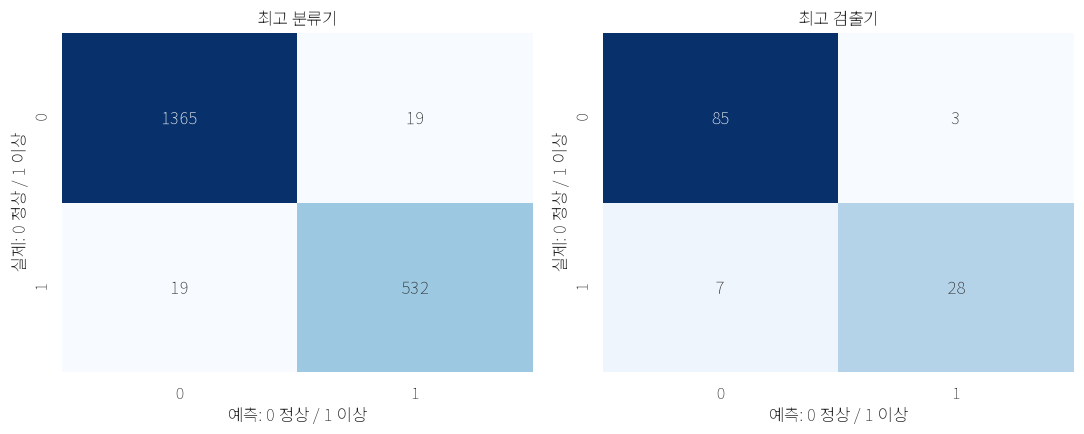

In [63]:
classifier_confusion = confusion_matrix(classifier_holdout_y, best_classifier_holdout_prediction)
detector_confusion = confusion_matrix(detector_holdout_y, best_detector_holdout_prediction)

figure, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for axis, matrix, title in [
    (axes[0], classifier_confusion, "최고 분류기"),
    (axes[1], detector_confusion, "최고 검출기"),
]:
    sns.heatmap(matrix, annot=True, fmt="d", cmap="Blues", cbar=False, ax=axis)
    axis.set_title(title)
    axis.set_xlabel("예측: 0 정상 / 1 이상")
    axis.set_ylabel("실제: 0 정상 / 1 이상")
plt.tight_layout()
plt.show()

## 9. 어떤 변수가 이상 판단에 영향을 주었는가

선택된 분류기에서 변수 하나의 전체 시간 흐름을 다른 윈도우와 무작위로 바꿔 끼웁니다. 그때 검증 F1이 많이 떨어지면 모델이 그 변수를 많이 사용했다는 뜻입니다. 이 방법을 변수마다 20회 반복합니다.

In [64]:
baseline_classifier_validation_scores = classifier_scores(
    selected_classifier_kind,
    selected_classifier_model,
    classifier_validation_x,
)
baseline_classifier_validation_f1 = f1_score(
    classifier_validation_y,
    baseline_classifier_validation_scores >= float(best_classifier_row["기준값"]),
)

rng = np.random.default_rng(RANDOM_STATE)
importance_rows = []
for feature_index, feature_name in enumerate(classifier_feature_columns):
    drops = []
    for repeat in range(20):
        permuted = classifier_validation_x.copy()
        order = rng.permutation(len(permuted))
        permuted[:, :, feature_index] = permuted[order, :, feature_index]
        permuted_scores = classifier_scores(selected_classifier_kind, selected_classifier_model, permuted)
        permuted_f1 = f1_score(
            classifier_validation_y,
            permuted_scores >= float(best_classifier_row["기준값"]),
        )
        drops.append(baseline_classifier_validation_f1 - permuted_f1)
    importance_rows.append(
        {
            "변수": feature_name,
            "평균 F1 하락": float(np.mean(drops)),
            "표준편차": float(np.std(drops)),
            "반복 횟수": 20,
        }
    )

group_permutation_importance = pd.DataFrame(importance_rows).sort_values("평균 F1 하락", ascending=False).reset_index(drop=True)
display(group_permutation_importance)

normal_validation_windows = classifier_role_windows["정상 검증"]
anomaly_validation_windows = classifier_role_windows["이상 검증"]
state_rows = []
for feature_index, feature_name in enumerate(classifier_feature_columns):
    normal_median = float(np.median(normal_validation_windows[:, :, feature_index]))
    anomaly_median = float(np.median(anomaly_validation_windows[:, :, feature_index]))
    state_rows.append(
        {
            "변수": feature_name,
            "정상 중앙값": normal_median,
            "이상 중앙값": anomaly_median,
            "이상-정상 차이": anomaly_median - normal_median,
            "관찰 방향": "이상에서 높음" if anomaly_median > normal_median else "이상에서 낮음",
        }
    )
feature_state_profile = pd.DataFrame(state_rows).merge(
    group_permutation_importance[["변수", "평균 F1 하락"]],
    on="변수",
).sort_values("평균 F1 하락", ascending=False).reset_index(drop=True)
display(feature_state_profile)

,변수,평균 F1 하락,표준편차,반복 횟수
0,Current 최근 8행 변동성,0.141218,0.010047,20
1,Current 표준화값,0.131304,0.014394,20
2,Intensity 표준화값,0.104656,0.012355,20
3,Intensity 최근 8행 변동성,0.091528,0.010509,20
4,Current 1행 변화량,0.058106,0.009938,20
5,Intensity 1행 변화량,0.054780,0.010919,20


,변수,정상 중앙값,이상 중앙값,이상-정상 차이,관찰 방향,평균 F1 하락
0,Current 최근 8행 변동성,0.683079,0.476701,-0.206379,이상에서 낮음,0.141218
1,Current 표준화값,-0.163560,-1.078848,-0.915288,이상에서 낮음,0.131304
2,Intensity 표준화값,-0.164590,-1.067412,-0.902823,이상에서 낮음,0.104656
3,Intensity 최근 8행 변동성,0.689051,0.479636,-0.209415,이상에서 낮음,0.091528
4,Current 1행 변화량,-0.001758,-0.003015,-0.001257,이상에서 낮음,0.058106
5,Intensity 1행 변화량,-0.001830,-0.004675,-0.002844,이상에서 낮음,0.054780


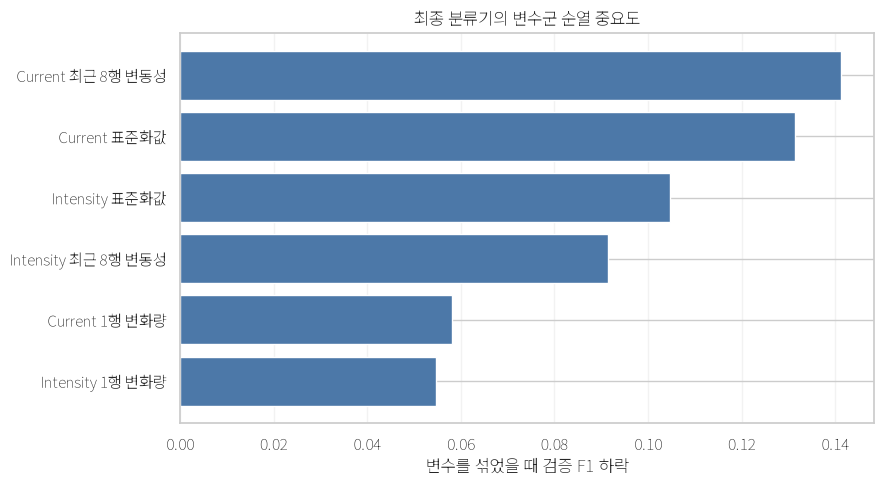

In [65]:
figure, axis = plt.subplots(figsize=(9, 5))
plot_data = group_permutation_importance.sort_values("평균 F1 하락")
axis.barh(plot_data["변수"], plot_data["평균 F1 하락"], color="#4C78A8")
axis.set_xlabel("변수를 섞었을 때 검증 F1 하락")
axis.set_title("최종 분류기의 변수군 순열 중요도")
axis.grid(axis="x", alpha=0.25)
plt.tight_layout()
plt.show()

## 10. 공정 최적화 관점의 해석

현재 데이터로 직접 말할 수 있는 것은 **어떤 센서 상태를 우선 감시해야 하는가**입니다. `Intensity`와 `Current`는 레이저 반사광을 측정한 결과 신호이며, 장비에 입력한 power나 focus 값이 아닙니다.

- 중요도가 높은 센서 수준·변화량·최근 변동성을 우선 감시합니다.
- 정상 검증 범위에서 멀어지는 패턴이 이어지면 추가 품질 검사나 일시 정지를 검토합니다.
- 변수 중요도는 예측에 사용된 정도이며 원인 증명은 아닙니다.
- 구체적인 최적 power와 focus를 찾으려면 각 윈도우에 대응하는 power, focus, 펄스 조건, 가공 위치, 실제 홀 치수·형상 검사값, 가공 시작·종료와 홀 식별자를 함께 수집해야 합니다.

In [66]:
final_validation_checks = [
    ("분석 단위가 시간 공백으로 나눈 연속 구간임", set(normal_dataset.columns) == {"Time", "Intensity", "Current"}),
    ("윈도우 조합 16개를 모두 비교함", len(window_configuration_results) == 16),
    ("분류기 후보 네 계열을 비교함", set(classifier_tuning_results["모델 계열"]) == {"로지스틱 회귀", "랜덤 포레스트", "히스토그램 그래디언트 부스팅", "LSTM"}),
    ("검출기 후보 세 계열을 비교함", set(detector_tuning_results["검출기 계열"]) == {"PCA 복원오차", "Isolation Forest", "One Class SVM"}),
    ("최고 분류기와 최고 검출기를 각각 홀드아웃 평가함", len(detector_classifier_comparison) == 2),
    ("선택 변수 전체의 순열 중요도를 20회씩 계산함", len(group_permutation_importance) == len(classifier_feature_columns) and (group_permutation_importance["반복 횟수"] == 20).all()),
    ("모든 최종 성능이 0과 1 사이임", detector_classifier_comparison.filter(regex="F1|정확도|정밀도|재현율|AUC").apply(lambda column: column.between(0, 1).all()).all()),
]
final_validation_result = pd.DataFrame(final_validation_checks, columns=["검증 항목", "통과 여부"])
display(final_validation_result)
assert final_validation_result["통과 여부"].all()

print("최고 분류기:", selected_classifier_name)
print("최고 분류기 검증 F1:", round(float(best_classifier_row["F1"]), 4))
print("최고 분류기 홀드아웃 F1:", round(float(best_classifier_holdout_metrics["F1"]), 4))
print("최고 검출기:", selected_detector_name)
print("최고 검출기 검증 F1:", round(float(best_detector_row["F1"]), 4))
print("최고 검출기 홀드아웃 F1:", round(float(best_detector_holdout_metrics["F1"]), 4))
print("검증 기준 최종 선택:", "분류기" if best_classifier_row["F1"] >= best_detector_row["F1"] else "검출기")

,검증 항목,통과 여부
0,분석 단위가 시간 공백으로 나눈 연속 구간임,True
1,윈도우 조합 16개를 모두 비교함,True
2,분류기 후보 네 계열을 비교함,True
3,검출기 후보 세 계열을 비교함,True
4,최고 분류기와 최고 검출기를 각각 홀드아웃 평가함,True
5,선택 변수 전체의 순열 중요도를 20회씩 계산함,True
6,모든 최종 성능이 0과 1 사이임,True


최고 분류기: HistGB depth=None, lr=0.1, l2=1.0
최고 분류기 검증 F1: 0.9519
최고 분류기 홀드아웃 F1: 0.9655
최고 검출기: OneClassSVM window=160, nu=0.01, gamma=0.1
최고 검출기 검증 F1: 0.7273
최고 검출기 홀드아웃 F1: 0.8485
검증 기준 최종 선택: 분류기


## 11. 최종 판단과 한계

최종 선택은 지도학습이나 비지도학습을 미리 선호해서 정하지 않고 **검증 F1과 홀드아웃 성능이 더 좋은 쪽**을 따릅니다.

다만 다음 한계는 반드시 함께 설명해야 합니다.

1. 정상과 이상이 서로 다른 날짜에 수집되어 날짜 효과와 상태 효과를 완전히 분리할 수 없습니다.
2. `normal.xlsx`와 `anomaly.xlsx`는 제공자가 붙인 가공 조건 라벨이며, 각 윈도우에 실제 홀 치수 검사 결과가 붙어 있지는 않습니다.
3. 개별 가공의 시작·종료 식별자가 없어 시간 공백으로 만든 연속 측정 구간을 데이터 분리 단위로 사용했습니다.
4. 이상 개발 구간이 하나뿐이어서 그 안을 앞·뒤로 나눠 학습과 검증에 사용했습니다.
5. 여러 전처리와 모델 후보를 같은 검증 자료에서 비교했으므로 완전히 새로운 생산 데이터에서 다시 확인해야 합니다.
6. power·focus 설정값과 실제 품질 측정값이 없으므로 물리 단위의 최적 공정값을 제안할 수 없습니다.